# 1. Постановка задачи и подготовка вычислительной среды

На первом этапе формулируется исследовательская задача, задаются границы эксперимента и подготавливается вычислительная среда. В данной работе автоматическая подготовка краткого проектного документа игры рассматривается как воспроизводимая исследовательская задача, в которой качество результата должно оцениваться по сопоставимым признакам, таким как полнота, смысловая согласованность, жанровая точность и снижение шаблонности.

Научная новизна предлагаемого эксперимента состоит в том, что краткий проектный документ игры формируется не только по текстовому заданию, но и с опорой на найденные игровые аналоги из открытого корпуса реальных игр. В единой вычислительной схеме будут сопоставлены три способа получения результата: шаблонный способ без удаленной языковой модели, способ с удаленной языковой моделью без игровых аналогов и способ с удаленной языковой моделью, дополненной найденными аналогами. На данном этапе обеспечивается воспроизводимость вычислений, проверяется доступ к удаленной модели и фиксируются основные параметры дальнейшего исследования.

In [10]:
# Установка библиотек, которые потребуются в дальнейших этапах

import sys
import subprocess
import importlib.util

required_packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "openai",
    "requests",
    "psutil",
    "tqdm"
]

for package_name in required_packages:
    if importlib.util.find_spec(package_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

print("Подготовка библиотек завершена")

Подготовка библиотек завершена


In [11]:
# Подключение библиотек для таблиц, вычислений, рисунков и связи с удаленной моделью

import os
import random
import time
import platform
from pathlib import Path
from getpass import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil
from openai import OpenAI

# Настройка отображения таблиц и рисунков
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Фиксация начального состояния генератора случайных чисел
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Основные параметры исследования
EXPERIMENT_CONFIG = {
    "seed": SEED,
    "base_url": "https://openai.api.proxyapi.ru/v1",
    "dataset_title": "PlayMyData",
    "dataset_record_url": "https://zenodo.org/records/10797761",
    "target_document_name": "Краткий проектный документ игры",
    "planned_modes": [
        "Шаблонный способ без удаленной языковой модели",
        "Удаленная языковая модель без игровых аналогов",
        "Удаленная языковая модель с игровыми аналогами"
    ]
}

# Исследовательские формулировки
RESEARCH_OBJECT = (
    "Процесс автоматизации подготовки краткого проектного документа игры "
    "на основе открытых данных о видеоиграх"
)

RESEARCH_SUBJECT = (
    "Способы повышения содержательности и согласованности краткого "
    "проектного документа игры за счет добавления игровых аналогов"
)

RESEARCH_HYPOTHESIS = (
    "Если дополнить задание для удаленной языковой модели найденными "
    "игровыми аналогами из корпуса реальных игр, то итоговый краткий "
    "проектный документ будет более полным, более жанрово согласованным "
    "и менее шаблонным"
)

SCIENTIFIC_NOVELTY = (
    "Новизна работы состоит в сравнении трех способов подготовки краткого "
    "проектного документа игры в единой вычислительной схеме и в использовании "
    "открытого корпуса реальных игр как источника содержательных аналогов "
    "для управляемого порождения текста"
)

DOCUMENT_STRUCTURE = [
    "Название проекта",
    "Краткая концепция",
    "Жанр и целевая аудитория",
    "Основной игровой цикл",
    "Ключевые механики",
    "Платформа",
    "Художественный ориентир",
    "Ограничение по масштабу",
    "Игровые аналоги",
    "Основные риски",
    "Первый план работ"
]

# Подготовка папок для итоговых материалов
Path("results").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

def print_runtime_info():
    """
    Вывод сведений о вычислительной среде
    """
    total_memory_gb = psutil.virtual_memory().total / (1024 ** 3)

    print("Сведения о вычислительной среде")
    print("-" * 60)
    print(f"Версия Python: {platform.python_version()}")
    print(f"Операционная система: {platform.system()} {platform.release()}")
    print(f"Общий объем оперативной памяти, гигабайт: {total_memory_gb:.2f}")
    print(f"Начальное состояние генератора случайных чисел: {SEED}")
    print("-" * 60)

def print_research_passport():
    """
    Вывод основных характеристик исследования
    """
    print("Паспорт исследования")
    print("-" * 60)
    print("Объект исследования:")
    print(RESEARCH_OBJECT)
    print()
    print("Предмет исследования:")
    print(RESEARCH_SUBJECT)
    print()
    print("Гипотеза:")
    print(RESEARCH_HYPOTHESIS)
    print()
    print("Научная новизна:")
    print(SCIENTIFIC_NOVELTY)
    print()
    print("Структура краткого проектного документа игры:")
    for idx, item in enumerate(DOCUMENT_STRUCTURE, start=1):
        print(f"{idx}. {item}")
    print("-" * 60)

print_runtime_info()
print()
print_research_passport()

Сведения о вычислительной среде
------------------------------------------------------------
Версия Python: 3.12.13
Операционная система: Linux 6.6.113+
Общий объем оперативной памяти, гигабайт: 12.67
Начальное состояние генератора случайных чисел: 42
------------------------------------------------------------

Паспорт исследования
------------------------------------------------------------
Объект исследования:
Процесс автоматизации подготовки краткого проектного документа игры на основе открытых данных о видеоиграх

Предмет исследования:
Способы повышения содержательности и согласованности краткого проектного документа игры за счет добавления игровых аналогов

Гипотеза:
Если дополнить задание для удаленной языковой модели найденными игровыми аналогами из корпуса реальных игр, то итоговый краткий проектный документ будет более полным, более жанрово согласованным и менее шаблонным

Научная новизна:
Новизна работы состоит в сравнении трех способов подготовки краткого проектного докумен

In [12]:
# Получение секретного ключа с несколькими безопасными вариантами

def get_api_key():
    """
    Порядок поиска секретного ключа:
    1. Защищенное хранилище Google Colab
    2. Переменные окружения
    3. Ручной скрытый ввод
    """
    # Попытка получить ключ из защищенного хранилища Google Colab
    try:
        from google.colab import userdata
        api_key = userdata.get("PROXYAPI_API_KEY")
        if api_key is not None and str(api_key).strip() != "":
            print("Секретный ключ получен из защищенного хранилища Google Colab")
            return str(api_key).strip()
    except Exception:
        pass

    # Попытка получить ключ из переменных окружения
    api_key = os.environ.get("PROXYAPI_API_KEY")
    if api_key is not None and str(api_key).strip() != "":
        print("Секретный ключ получен из переменных окружения")
        return str(api_key).strip()

    # Безопасный ручной ввод
    print("Секретный ключ заранее не найден")
    print("Необходимо выполнить скрытый ручной ввод")
    manual_key = getpass("Введите секретный ключ ProxyAPI: ").strip()

    if manual_key == "":
        raise ValueError(
            "Секретный ключ не введен. Выполнение этапа невозможно продолжить."
        )

    print("Секретный ключ успешно получен вручную")
    return manual_key

api_key = get_api_key()

client = OpenAI(
    api_key=api_key,
    base_url=EXPERIMENT_CONFIG["base_url"]
)

print("Подключение к удаленной модели подготовлено")
print(f"Базовый адрес сервиса: {EXPERIMENT_CONFIG['base_url']}")

Секретный ключ заранее не найден
Необходимо выполнить скрытый ручной ввод
Введите секретный ключ ProxyAPI: ··········
Секретный ключ успешно получен вручную
Подключение к удаленной модели подготовлено
Базовый адрес сервиса: https://openai.api.proxyapi.ru/v1


In [13]:
# Попытка получить список доступных моделей
# Если это не удается, используется заранее заданный безопасный вариант

MODEL_NAME = None
model_ids = []

try:
    models_response = client.models.list()
    model_ids = sorted([item.id for item in models_response.data])

    print(f"Найдено моделей: {len(model_ids)}")
    print("-" * 60)

    for model_name in model_ids[:30]:
        print(model_name)

    preferred_models = [
        "openai/gpt-4o-mini",
        "openai/gpt-4o",
        "gemini/gemini-2.0-flash",
        "gemini/gemini-1.5-flash"
    ]

    for candidate in preferred_models:
        if candidate in model_ids:
            MODEL_NAME = candidate
            break

    if MODEL_NAME is None and len(model_ids) > 0:
        MODEL_NAME = model_ids[0]

except Exception as error:
    print("Получить список моделей автоматически не удалось")
    print("Текст ошибки:")
    print(error)

# Если список моделей не был получен, задаем модель вручную
if MODEL_NAME is None:
    MODEL_NAME = os.environ.get("PROXYAPI_MODEL_NAME", "").strip()

if MODEL_NAME == "":
    MODEL_NAME = "openai/gpt-4o-mini"

print("-" * 60)
print(f"Выбранная модель для пробной проверки: {MODEL_NAME}")

Найдено моделей: 381
------------------------------------------------------------
anthropic/*
anthropic/claude-3-7-sonnet-20250219
anthropic/claude-3-haiku-20240307
anthropic/claude-3-opus-20240229
anthropic/claude-4-opus-20250514
anthropic/claude-4-sonnet-20250514
anthropic/claude-haiku-4-5
anthropic/claude-haiku-4-5-20251001
anthropic/claude-opus-4-1
anthropic/claude-opus-4-1-20250805
anthropic/claude-opus-4-20250514
anthropic/claude-opus-4-5
anthropic/claude-opus-4-5-20251101
anthropic/claude-opus-4-6
anthropic/claude-opus-4-6-20260205
anthropic/claude-sonnet-4-20250514
anthropic/claude-sonnet-4-5
anthropic/claude-sonnet-4-5-20250929
anthropic/claude-sonnet-4-6
deepseek-chat
deepseek-reasoner
deepseek/*
deepseek/deepseek-chat
deepseek/deepseek-coder
deepseek/deepseek-r1
deepseek/deepseek-reasoner
deepseek/deepseek-v3
deepseek/deepseek-v3.2
gemini-2.0-flash-exp-image-generation
gemini-2.5-flash-native-audio-latest
------------------------------------------------------------
Выбранная

In [14]:
# Короткая пробная проверка связи с удаленной моделью
# Используется очень небольшой запрос, чтобы не расходовать лишние средства

messages = [
    {
        "role": "system",
        "content": (
            "Необходимо отвечать кратко, по-русски, в научном стиле. "
            "Ответ должен состоять из двух предложений."
        )
    },
    {
        "role": "user",
        "content": (
            "Кратко объясните, почему поиск игровых аналогов полезен "
            "при подготовке краткого проектного документа игры."
        )
    }
]

start_time = time.time()

response = client.chat.completions.create(
    model=MODEL_NAME,
    messages=messages,
    temperature=0.2,
    max_tokens=120
)

elapsed_time = time.time() - start_time
answer_text = response.choices[0].message.content

print("Пробный ответ удаленной модели")
print("-" * 60)
print(answer_text)
print("-" * 60)
print(f"Время отклика, секунд: {elapsed_time:.2f}")

Пробный ответ удаленной модели
------------------------------------------------------------
Поиск игровых аналогов позволяет выявить успешные механики и концепции, что способствует более точному определению целевой аудитории и конкурентных преимуществ проекта. Кроме того, это помогает избежать ошибок, допущенных в аналогичных играх, и улучшить качество конечного продукта.
------------------------------------------------------------
Время отклика, секунд: 2.54


In [15]:
# Сохранение кратких сведений о первом этапе в один компактный файл

stage_1_summary = {
    "dataset_title": EXPERIMENT_CONFIG["dataset_title"],
    "dataset_record_url": EXPERIMENT_CONFIG["dataset_record_url"],
    "base_url": EXPERIMENT_CONFIG["base_url"],
    "model_name": MODEL_NAME,
    "seed": EXPERIMENT_CONFIG["seed"],
    "research_object": RESEARCH_OBJECT,
    "research_subject": RESEARCH_SUBJECT,
    "research_hypothesis": RESEARCH_HYPOTHESIS,
    "scientific_novelty": SCIENTIFIC_NOVELTY,
    "document_structure": DOCUMENT_STRUCTURE
}

pd.Series(stage_1_summary, dtype="object").to_json(
    "results/stage_1_summary.json",
    force_ascii=False,
    indent=2
)

print("Краткие сведения первого этапа сохранены в файл results/stage_1_summary.json")

Краткие сведения первого этапа сохранены в файл results/stage_1_summary.json


Здесь важно, что подключение прошло успешно при умеренном времени отклика. Дальнейший эксперимент можно строить как воспроизводимую вычислительную схему. Следующий этап посвящается онлайн-загрузке корпуса игр и первичной проверке его пригодности для дальнейшего анализа.

# 2. Онлайн-загрузка и первичная подготовка корпуса игр

На данном этапе формируется единый исследовательский корпус игр на основе открытого межплатформенного набора данных. Для дальнейшего эксперимента требуется привести загруженные таблицы к единому виду, чтобы каждая запись содержала сопоставимые сведения о названии игры, кратком описании, жанрах, платформах, дате выхода и дополнительных числовых признаках. Научная значимость данного этапа состоит в том, что качество дальнейшего эксперимента напрямую зависит от корректности исходного корпуса. Поэтому особое внимание уделяется обработке отсутствующих значений, удалению повторов и построению первых сводных характеристик набора данных, что позволяет заранее выявить перекосы корпуса и исключить искажения, которые могли бы повлиять на сравнение исследуемых способов подготовки краткого проектного документа игры.

Открытый набор PlayMyData опубликован отдельными таблицами для PC, PlayStation, Xbox и Nintendo, а также дополнен малыми служебными таблицами жанров и платформ; в [описании набора](https://zenodo.org/records/10797761) указано, что он охватывает 99 864 игры и содержит метаданные, сведения о платформах, описания и даты релиза.

In [21]:
# Задаем сетевые адреса основных таблиц набора данных и таблицы жанров

DATA_SOURCES = {
    "PC": "https://zenodo.org/records/10797761/files/all_games_PC.csv?download=1",
    "PlayStation": "https://zenodo.org/records/10797761/files/all_games_PlayStation.csv?download=1",
    "Xbox": "https://zenodo.org/records/10797761/files/all_games_Xbox.csv?download=1",
    "Nintendo": "https://zenodo.org/records/10797761/files/all_games_Nintendo.csv?download=1"
}

GENRES_SOURCE = "https://zenodo.org/records/10797761/files/genres.csv?download=1"

# Функция чтения нескольких первых строк
# Это позволяет увидеть состав полей без полной загрузки всей таблицы
def read_preview_table(source_url, rows_count=5):
    preview_table = pd.read_csv(
        source_url,
        nrows=rows_count
    )
    return preview_table

preview_tables = {}
column_map = {}

for platform_name, source_url in DATA_SOURCES.items():
    preview_table = read_preview_table(source_url, rows_count=5)
    preview_tables[platform_name] = preview_table
    column_map[platform_name] = list(preview_table.columns)

    print(f"\nСемейство платформ: {platform_name}")
    print(f"Количество полей: {len(preview_table.columns)}")
    print("Названия полей:")
    print(preview_table.columns.tolist())

# Находим поля, общие для всех основных таблиц
common_columns = set(column_map[list(column_map.keys())[0]])
for platform_name in column_map:
    common_columns = common_columns.intersection(set(column_map[platform_name]))

common_columns = sorted(common_columns)

print("\n" + "=" * 70)
print(f"Количество общих полей: {len(common_columns)}")
print("Общие поля:")
print(common_columns)


Семейство платформ: PC
Количество полей: 14
Названия полей:
['first_release_date', 'genres', 'id', 'name', 'platforms', 'summary', 'storyline', 'rating', 'main', 'extra', 'completionist', 'review_score', 'review_count', 'people_polled']

Семейство платформ: PlayStation
Количество полей: 14
Названия полей:
['first_release_date', 'genres', 'id', 'name', 'platforms', 'summary', 'storyline', 'rating', 'main', 'extra', 'completionist', 'review_score', 'review_count', 'people_polled']

Семейство платформ: Xbox
Количество полей: 14
Названия полей:
['first_release_date', 'genres', 'id', 'name', 'platforms', 'summary', 'storyline', 'rating', 'main', 'extra', 'completionist', 'review_score', 'review_count', 'people_polled']

Семейство платформ: Nintendo
Количество полей: 14
Названия полей:
['first_release_date', 'genres', 'id', 'name', 'platforms', 'summary', 'rating', 'storyline', 'main', 'extra', 'completionist', 'review_score', 'review_count', 'people_polled']

Количество общих полей: 14
Общ

In [22]:
# Загружаем все общие поля, так как их немного и они пригодятся в следующих этапах
# При чтении сразу переводим служебные значения отсутствия данных в пустые значения

selected_columns = common_columns.copy()

NA_MARKERS = ["Missing", "missing", "MISSING", "None", "none", "NULL", "null", "NaN", "nan", ""]

def load_main_table(platform_name, source_url, use_columns):
    table = pd.read_csv(
        source_url,
        usecols=use_columns,
        low_memory=False,
        na_values=NA_MARKERS,
        keep_default_na=True
    )
    table["platform_family"] = platform_name
    return table

main_tables = []

for platform_name, source_url in DATA_SOURCES.items():
    current_table = load_main_table(platform_name, source_url, selected_columns)
    main_tables.append(current_table)

games_raw = pd.concat(main_tables, ignore_index=True)

genres_table = pd.read_csv(GENRES_SOURCE)
genres_table = genres_table.rename(columns={"genre_id": "genre_id", "genre": "genre_name"})

print("Размер объединенной таблицы данных:")
print(games_raw.shape)

print("\nПервые строки объединенной таблицы данных:")
display(games_raw.head(5))

print("\nТаблица жанров:")
display(genres_table.head())

Размер объединенной таблицы данных:
(129380, 15)

Первые строки объединенной таблицы данных:


,first_release_date,genres,id,name,platforms,summary,storyline,rating,main,extra,completionist,review_score,review_count,people_polled,platform_family
0,1018396800,[5],274203,Short 'n Quick,[6],this is a techstyled map taking place in a warehouse,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PC
1,1019606400,[5],256819,Caverns of Darkness,[6],The final rift was closed and the Hell War was over at last The citizens of the Earth celebrated for the first time in almost six years The forces of Hell had been beaten Humanity had won Now bega...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PC
2,1017964800,"[26, 31]",232860,"Nu, pogodi! Vypusk 1: Pogonya",[6],The wolf decides to take revenge on the Hare for all past grievances However the task is difficult the unlucky predator will have to overcome a lot of obstacles and compete in strength and dexteri...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PC
3,1019779200,"[12, 15, 16]",228979,Power Dolls 5,[6],The fifth entry in Kogado Studios allfemale mech tactical RPG series Power Dolls,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PC
4,1020124800,[2],225648,Kapsyljakt med Anki & Pytte,[6],A pointandclick game based on the Swedish childrens program Anki Pytte As the title of the game suggests the game is about collecting bottlecaps by playing different minigames with kapsyljakt mea...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PC



Таблица жанров:


,genre_id,genre_name
0,4,Fighting
1,5,Shooter
2,7,Music
3,8,Platform
4,9,Puzzle


In [23]:
# Проводим первичную очистку и создаем производные поля

import ast

games = games_raw.copy()

rows_before = len(games)

# Удаляем полностью совпадающие строки
games = games.drop_duplicates().copy()
rows_after_full_duplicates = len(games)

# Приводим текстовые поля к единому виду
text_columns = [
    column_name for column_name in [
        "name", "summary", "storyline"
    ]
    if column_name in games.columns
]

for column_name in text_columns:
    games[column_name] = (
        games[column_name]
        .fillna("")
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

# Пустые строки снова считаем отсутствием данных
for column_name in text_columns:
    games.loc[games[column_name] == "", column_name] = np.nan

# Формируем единое текстовое описание игры
games["summary_clean"] = games["summary"].fillna("")
games["storyline_clean"] = games["storyline"].fillna("")

games["text_description"] = (
    games["summary_clean"] + " " + games["storyline_clean"]
).str.replace(r"\s+", " ", regex=True).str.strip()

games.loc[games["text_description"] == "", "text_description"] = np.nan

# Рассчитываем длину описания и наличие описания
games["description_length"] = games["text_description"].fillna("").str.len()
games["has_description"] = games["text_description"].notna()

# Преобразуем дату выхода в календарный вид
games["release_date"] = pd.to_datetime(
    games["first_release_date"],
    unit="s",
    errors="coerce"
)
games["release_year"] = games["release_date"].dt.year

# Удаляем записи без названия
rows_before_name_filter = len(games)
games = games[games["name"].notna()].copy()
rows_after_name_filter = len(games)

# Удаляем повторы по сочетанию семейства платформ и названия
rows_before_entity_deduplication = len(games)
games = games.drop_duplicates(subset=["platform_family", "name"]).copy()
rows_after_entity_deduplication = len(games)

# Преобразуем строковое представление списка жанров в настоящий список чисел
def parse_id_list(value):
    if pd.isna(value):
        return []
    text_value = str(value).strip()
    if text_value == "":
        return []
    try:
        parsed_value = ast.literal_eval(text_value)
        if isinstance(parsed_value, list):
            return [int(item) for item in parsed_value if str(item).strip() != ""]
        return []
    except Exception:
        return []

games["genre_id_list"] = games["genres"].apply(parse_id_list)
games["genre_count"] = games["genre_id_list"].apply(len)

# Создаем словарь жанров и текстовое поле с названиями жанров
genre_lookup = dict(zip(genres_table["genre_id"], genres_table["genre_name"]))

def map_genre_names(id_list):
    names = [genre_lookup.get(genre_id) for genre_id in id_list]
    names = [name for name in names if name is not None]
    return names

games["genre_name_list"] = games["genre_id_list"].apply(map_genre_names)
games["genre_names_text"] = games["genre_name_list"].apply(
    lambda names: ", ".join(names) if len(names) > 0 else np.nan
)

# Удаляем вспомогательные временные поля
games = games.drop(columns=["summary_clean", "storyline_clean"])

print("Сведения об очистке данных")
print("-" * 70)
print(f"Количество строк до очистки: {rows_before}")
print(f"Количество строк после удаления полных повторов: {rows_after_full_duplicates}")
print(f"Количество строк до удаления записей без названия: {rows_before_name_filter}")
print(f"Количество строк после удаления записей без названия: {rows_after_name_filter}")
print(f"Количество строк до удаления повторов по семейству платформ и названию: {rows_before_entity_deduplication}")
print(f"Количество строк после удаления повторов по семейству платформ и названию: {rows_after_entity_deduplication}")

print("\nДоля записей с непустым текстовым описанием, процентов:")
print(round(games["has_description"].mean() * 100, 2))

print("\nПервые строки очищенной таблицы данных:")
display(
    games[
        [
            "name",
            "platform_family",
            "summary",
            "storyline",
            "text_description",
            "description_length",
            "genre_names_text",
            "release_year",
            "rating",
            "review_score",
            "review_count",
            "main",
            "extra",
            "completionist"
        ]
    ].head(5)
)

Сведения об очистке данных
----------------------------------------------------------------------
Количество строк до очистки: 129380
Количество строк после удаления полных повторов: 129380
Количество строк до удаления записей без названия: 129380
Количество строк после удаления записей без названия: 129377
Количество строк до удаления повторов по семейству платформ и названию: 129377
Количество строк после удаления повторов по семейству платформ и названию: 127712

Доля записей с непустым текстовым описанием, процентов:
96.12

Первые строки очищенной таблицы данных:


,name,platform_family,summary,storyline,text_description,description_length,genre_names_text,release_year,rating,review_score,review_count,main,extra,completionist
0,Short 'n Quick,PC,this is a techstyled map taking place in a warehouse,NaN,this is a techstyled map taking place in a warehouse,52,Shooter,2002,NaN,NaN,NaN,NaN,NaN,NaN
1,Caverns of Darkness,PC,The final rift was closed and the Hell War was over at last The citizens of the Earth celebrated for the first time in almost six years The forces of Hell had been beaten Humanity had won Now bega...,NaN,The final rift was closed and the Hell War was over at last The citizens of the Earth celebrated for the first time in almost six years The forces of Hell had been beaten Humanity had won Now bega...,2150,Shooter,2002,NaN,NaN,NaN,NaN,NaN,NaN
2,"Nu, pogodi! Vypusk 1: Pogonya",PC,The wolf decides to take revenge on the Hare for all past grievances However the task is difficult the unlucky predator will have to overcome a lot of obstacles and compete in strength and dexteri...,NaN,The wolf decides to take revenge on the Hare for all past grievances However the task is difficult the unlucky predator will have to overcome a lot of obstacles and compete in strength and dexteri...,762,"Quiz, Adventure",2002,NaN,NaN,NaN,NaN,NaN,NaN
3,Power Dolls 5,PC,The fifth entry in Kogado Studios allfemale mech tactical RPG series Power Dolls,NaN,The fifth entry in Kogado Studios allfemale mech tactical RPG series Power Dolls,80,"Role-playing (RPG), Strategy, Turn-based strategy (TBS)",2002,NaN,NaN,NaN,NaN,NaN,NaN
4,Kapsyljakt med Anki & Pytte,PC,A pointandclick game based on the Swedish childrens program Anki Pytte As the title of the game suggests the game is about collecting bottlecaps by playing different minigames with kapsyljakt mean...,NaN,A pointandclick game based on the Swedish childrens program Anki Pytte As the title of the game suggests the game is about collecting bottlecaps by playing different minigames with kapsyljakt mean...,211,Point-and-click,2002,NaN,NaN,NaN,NaN,NaN,NaN


Сводная таблица по семействам платформ


,platform_family,games_count,with_description_count,median_description_length,median_rating,median_review_score,description_share_percent
0,PC,67978,65929,227.0,70.000000,48.0,96.99
1,PlayStation,23608,22424,355.0,70.185542,65.0,94.98
2,Nintendo,21906,20510,261.0,70.000000,64.0,93.63
3,Xbox,14220,13898,340.0,70.276854,66.0,97.74


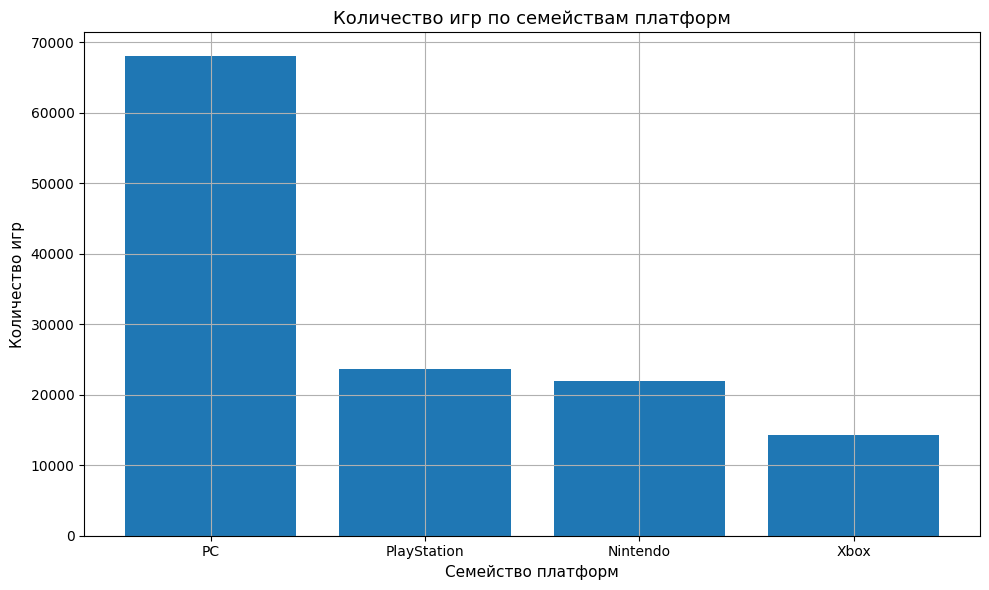

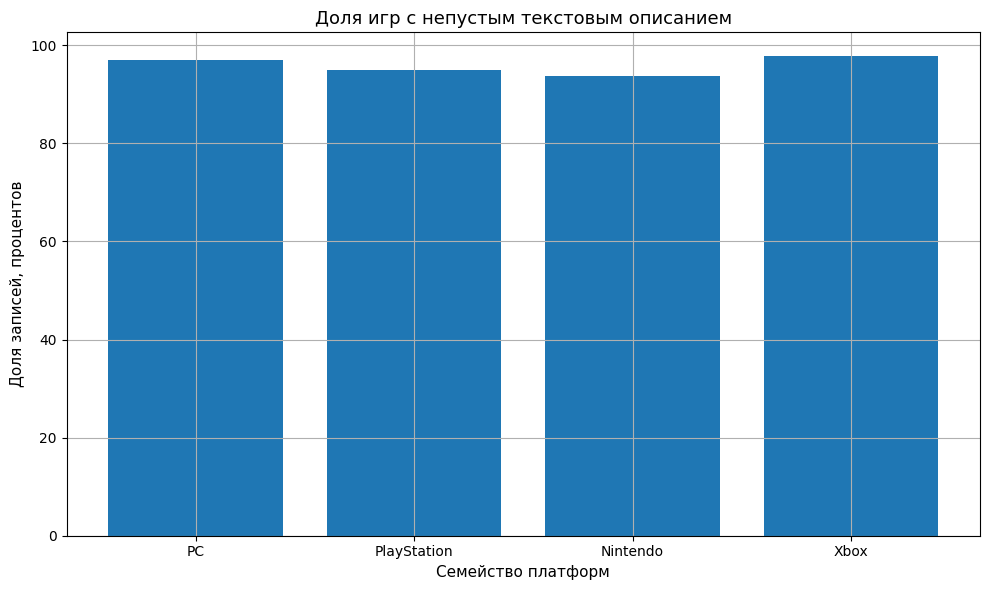

In [24]:
# Строим сводные характеристики по семействам платформ

platform_summary = (
    games.groupby("platform_family", as_index=False)
    .agg(
        games_count=("name", "count"),
        with_description_count=("has_description", "sum"),
        median_description_length=("description_length", "median"),
        median_rating=("rating", "median"),
        median_review_score=("review_score", "median")
    )
    .sort_values(by="games_count", ascending=False)
    .reset_index(drop=True)
)

platform_summary["description_share_percent"] = (
    platform_summary["with_description_count"] / platform_summary["games_count"] * 100
).round(2)

print("Сводная таблица по семействам платформ")
display(platform_summary)

# Первый рисунок
plt.figure(figsize=(10, 6))
plt.bar(platform_summary["platform_family"], platform_summary["games_count"])
plt.title("Количество игр по семействам платформ")
plt.xlabel("Семейство платформ")
plt.ylabel("Количество игр")
plt.tight_layout()
plt.show()

# Второй рисунок
plt.figure(figsize=(10, 6))
plt.bar(platform_summary["platform_family"], platform_summary["description_share_percent"])
plt.title("Доля игр с непустым текстовым описанием")
plt.xlabel("Семейство платформ")
plt.ylabel("Доля записей, процентов")
plt.tight_layout()
plt.show()

In [25]:
# Сохраняем подготовленную таблицу данных и сводную таблицу

storage_columns = [
    "id",
    "name",
    "platform_family",
    "platforms",
    "genres",
    "genre_id_list",
    "genre_name_list",
    "genre_names_text",
    "summary",
    "storyline",
    "text_description",
    "description_length",
    "has_description",
    "first_release_date",
    "release_date",
    "release_year",
    "rating",
    "review_score",
    "review_count",
    "people_polled",
    "main",
    "extra",
    "completionist"
]

storage_columns = [column_name for column_name in storage_columns if column_name in games.columns]

games_to_save = games[storage_columns].copy()

games_to_save.to_csv(
    "results/games_stage_2.csv.gz",
    index=False,
    compression="gzip"
)

platform_summary.to_csv(
    "results/platform_summary_stage_2.csv",
    index=False
)

print("Подготовленная таблица данных сохранена в файл results/games_stage_2.csv.gz")
print("Сводная таблица по семействам платформ сохранена в файл results/platform_summary_stage_2.csv")
print(f"Размер подготовленной таблицы данных: {games_to_save.shape}")

Подготовленная таблица данных сохранена в файл results/games_stage_2.csv.gz
Сводная таблица по семействам платформ сохранена в файл results/platform_summary_stage_2.csv
Размер подготовленной таблицы данных: (127712, 23)


Отметим выраженную неравномерность по семействам платформ. Корпус заметно смещен в сторону персональных компьютеров, тогда как по остальным семействам платформ объем данных меньше. Далее потребуется явно показать, как подобная неравномерность учитывается при построении экспериментальной выборки и интерпретации результатов. Следующий этап как раз посвящен содержательному портрету корпуса, чтобы выявить временную, жанровую и структурную неоднородность данных.

# 3. Исследование структуры корпуса и визуальный анализ

Цель этапа состоит в том, чтобы определить, насколько корпус сбалансирован по годам выхода, жанрам, длине текстовых описаний и степени заполненности ключевых полей. Нам потребуется обосновать следующие этапы эксперимента, где будут формироваться игровые аналоги и тестовые задания для автоматической подготовки краткого проектного документа игры. Научная значимость этапа состоит в том, что он позволяет перейти от простого хранения данных к их интерпретации как исследовательского материала. Если в корпусе обнаруживаются перекосы по времени, жанрам или семействам платформ, это должно быть явно зафиксировано до начала сравнительного эксперимента.

In [26]:
# Загружаем подготовленную таблицу данных, сохраненную на предыдущем этапе

games = pd.read_csv("results/games_stage_2.csv.gz", compression="gzip")

print("Размер загруженной таблицы данных:")
print(games.shape)

print("\nНазвания полей:")
print(games.columns.tolist())

print("\nТипы данных по полям:")
print(games.dtypes)

print("\nПервые строки таблицы данных:")
display(games.head(5))

Размер загруженной таблицы данных:
(127712, 23)

Названия полей:
['id', 'name', 'platform_family', 'platforms', 'genres', 'genre_id_list', 'genre_name_list', 'genre_names_text', 'summary', 'storyline', 'text_description', 'description_length', 'has_description', 'first_release_date', 'release_date', 'release_year', 'rating', 'review_score', 'review_count', 'people_polled', 'main', 'extra', 'completionist']

Типы данных по полям:
id                      int64
name                   object
platform_family        object
platforms              object
genres                 object
genre_id_list          object
genre_name_list        object
genre_names_text       object
summary                object
storyline              object
text_description       object
description_length      int64
has_description          bool
first_release_date      int64
release_date           object
release_year            int64
rating                float64
review_score          float64
review_count          float

,id,name,platform_family,platforms,genres,genre_id_list,genre_name_list,genre_names_text,summary,storyline,text_description,description_length,has_description,first_release_date,release_date,release_year,rating,review_score,review_count,people_polled,main,extra,completionist
0,274203,Short 'n Quick,PC,[6],[5],[5],['Shooter'],Shooter,this is a techstyled map taking place in a warehouse,NaN,this is a techstyled map taking place in a warehouse,52,True,1018396800,2002-04-10,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,256819,Caverns of Darkness,PC,[6],[5],[5],['Shooter'],Shooter,The final rift was closed and the Hell War was over at last The citizens of the Earth celebrated for the first time in almost six years The forces of Hell had been beaten Humanity had won Now bega...,NaN,The final rift was closed and the Hell War was over at last The citizens of the Earth celebrated for the first time in almost six years The forces of Hell had been beaten Humanity had won Now bega...,2150,True,1019606400,2002-04-24,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,232860,"Nu, pogodi! Vypusk 1: Pogonya",PC,[6],"[26, 31]","[26, 31]","['Quiz', 'Adventure']","Quiz, Adventure",The wolf decides to take revenge on the Hare for all past grievances However the task is difficult the unlucky predator will have to overcome a lot of obstacles and compete in strength and dexteri...,NaN,The wolf decides to take revenge on the Hare for all past grievances However the task is difficult the unlucky predator will have to overcome a lot of obstacles and compete in strength and dexteri...,762,True,1017964800,2002-04-05,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,228979,Power Dolls 5,PC,[6],"[12, 15, 16]","[12, 15, 16]","['Role-playing (RPG)', 'Strategy', 'Turn-based strategy (TBS)']","Role-playing (RPG), Strategy, Turn-based strategy (TBS)",The fifth entry in Kogado Studios allfemale mech tactical RPG series Power Dolls,NaN,The fifth entry in Kogado Studios allfemale mech tactical RPG series Power Dolls,80,True,1019779200,2002-04-26,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,225648,Kapsyljakt med Anki & Pytte,PC,[6],[2],[2],['Point-and-click'],Point-and-click,A pointandclick game based on the Swedish childrens program Anki Pytte As the title of the game suggests the game is about collecting bottlecaps by playing different minigames with kapsyljakt mean...,NaN,A pointandclick game based on the Swedish childrens program Anki Pytte As the title of the game suggests the game is about collecting bottlecaps by playing different minigames with kapsyljakt mean...,211,True,1020124800,2002-04-30,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
# Подготавливаем производные таблицы и признаки для дальнейшего визуального анализа

# Приводим числовые поля к корректному виду
numeric_columns = [
    "release_year",
    "description_length",
    "rating",
    "review_score",
    "review_count",
    "people_polled",
    "main",
    "extra",
    "completionist"
]

for column_name in numeric_columns:
    if column_name in games.columns:
        games[column_name] = pd.to_numeric(games[column_name], errors="coerce")

# Оставляем только разумный временной интервал,
# чтобы случайные некорректные годы не искажали рисунки
games["release_year_valid"] = games["release_year"].where(
    (games["release_year"] >= 1970) & (games["release_year"] <= 2030),
    np.nan
)

# Подготавливаем длину описания с верхней отсечкой,
# чтобы отдельные крайне длинные тексты не сжимали основную часть распределения
games["description_length_clipped"] = games["description_length"].clip(upper=4000)

# Признаки наличия ключевых сведений
games["has_rating"] = games["rating"].notna()
games["has_review_score"] = games["review_score"].notna()
games["has_duration_main"] = games["main"].notna()
games["has_genres_text"] = games["genre_names_text"].notna()

# Разворачиваем жанры в отдельные строки
genre_rows = []

for _, row in games[["name", "platform_family", "genre_names_text"]].iterrows():
    genre_text = row["genre_names_text"]

    if pd.isna(genre_text):
        continue

    genre_list = [item.strip() for item in str(genre_text).split(",") if item.strip() != ""]

    for genre_name in genre_list:
        genre_rows.append(
            {
                "name": row["name"],
                "platform_family": row["platform_family"],
                "genre_name": genre_name
            }
        )

genres_long = pd.DataFrame(genre_rows)

# Сводка по годам выхода
year_summary = (
    games.dropna(subset=["release_year_valid"])
    .groupby("release_year_valid", as_index=False)
    .agg(games_count=("name", "count"))
    .sort_values("release_year_valid")
)

# Сводка по жанрам
genre_summary = (
    genres_long.groupby("genre_name", as_index=False)
    .agg(games_count=("name", "count"))
    .sort_values("games_count", ascending=False)
    .reset_index(drop=True)
)

top_genres = genre_summary.head(15).copy()

# Сводка по ключевым полям
field_completeness = pd.DataFrame({
    "Поле": [
        "Название игры",
        "Текстовое описание",
        "Год выхода",
        "Жанры",
        "Оценка",
        "Пользовательская оценка",
        "Основное время прохождения"
    ],
    "Доля заполнения, процентов": [
        games["name"].notna().mean() * 100,
        games["has_description"].mean() * 100,
        games["release_year_valid"].notna().mean() * 100,
        games["has_genres_text"].mean() * 100,
        games["has_rating"].mean() * 100,
        games["has_review_score"].mean() * 100,
        games["has_duration_main"].mean() * 100
    ]
})

field_completeness["Доля заполнения, процентов"] = field_completeness["Доля заполнения, процентов"].round(2)

print("Сводка по годам выхода")
display(year_summary.head(10))

print("\nСводка по жанрам")
display(top_genres)

print("\nЗаполненность ключевых полей")
display(field_completeness)

Сводка по годам выхода


,release_year_valid,games_count
0,1993,307
1,1994,417
2,1995,585
3,1996,788
4,1997,1020
5,1998,1194
6,1999,1290
7,2000,1230
8,2001,1318
9,2002,1626



Сводка по жанрам


,genre_name,games_count
0,Indie,47642
1,Adventure,46289
2,Simulator,21238
3,Role-playing (RPG),19205
4,Strategy,18925
5,Shooter,16932
6,Puzzle,15455
7,Arcade,13134
8,Platform,12194
9,Sport,8906



Заполненность ключевых полей


,Поле,"Доля заполнения, процентов"
0,Название игры,100.00
1,Текстовое описание,96.12
2,Год выхода,100.00
3,Жанры,92.09
4,Оценка,23.74
5,Пользовательская оценка,41.82
6,Основное время прохождения,41.82


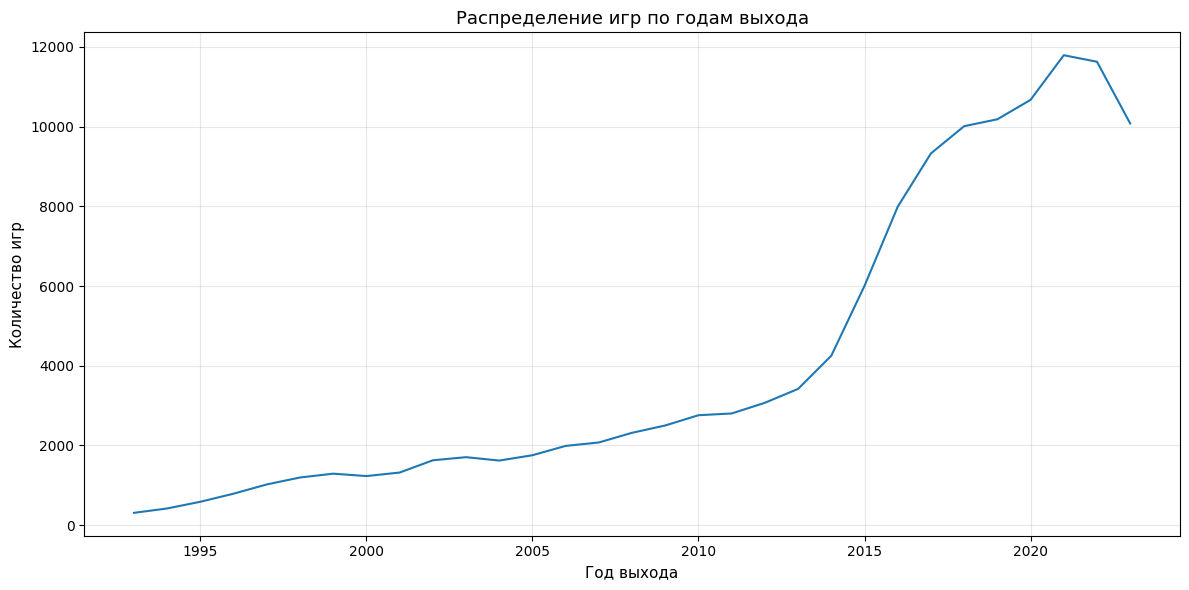

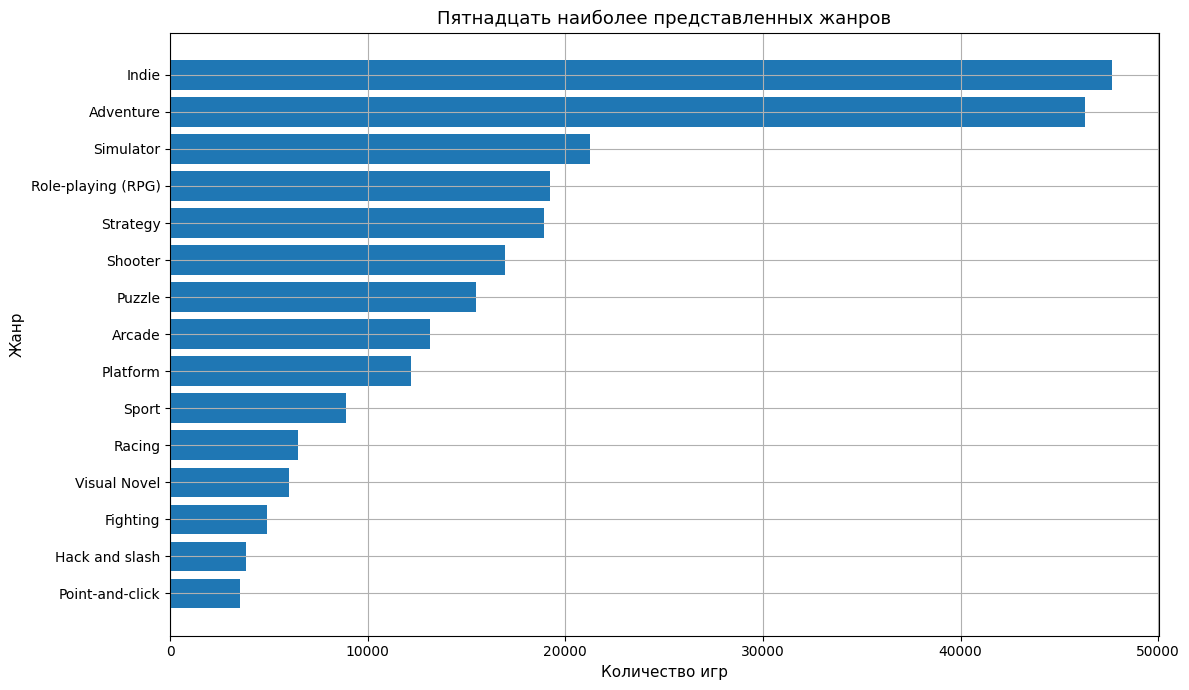

In [28]:
# Строим рисунки, отражающие временную и жанровую структуру корпуса

# Рисунок 1. Распределение игр по годам выхода
plt.figure(figsize=(12, 6))
plt.plot(year_summary["release_year_valid"], year_summary["games_count"])
plt.title("Распределение игр по годам выхода")
plt.xlabel("Год выхода")
plt.ylabel("Количество игр")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Рисунок 2. Пятнадцать наиболее представленных жанров
plt.figure(figsize=(12, 7))
plt.barh(top_genres["genre_name"][::-1], top_genres["games_count"][::-1])
plt.title("Пятнадцать наиболее представленных жанров")
plt.xlabel("Количество игр")
plt.ylabel("Жанр")
plt.tight_layout()
plt.show()

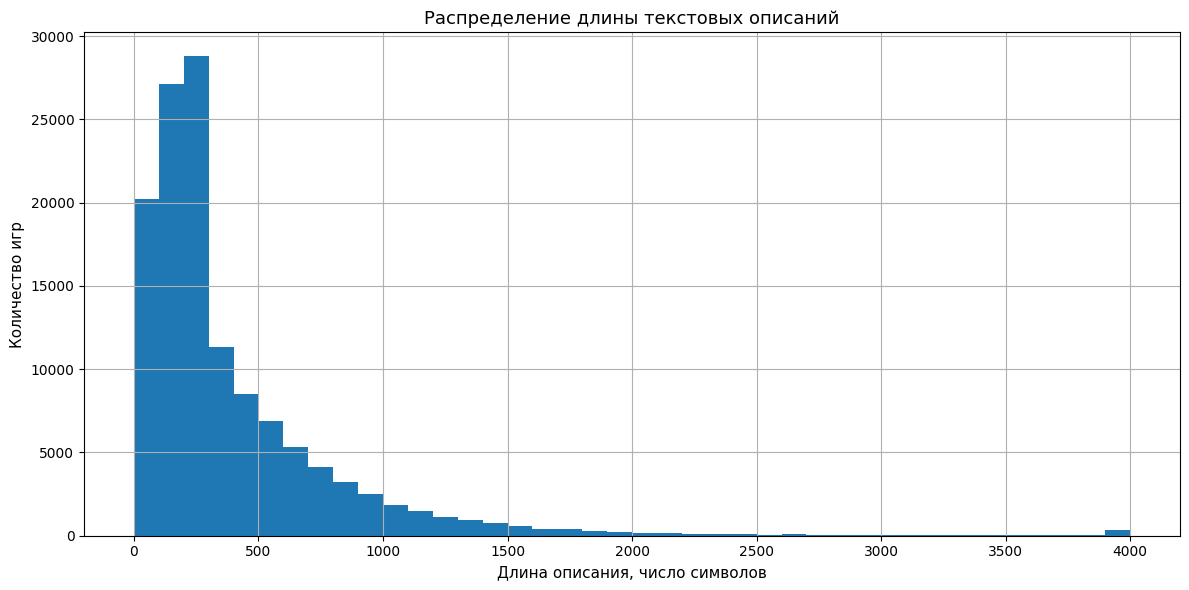

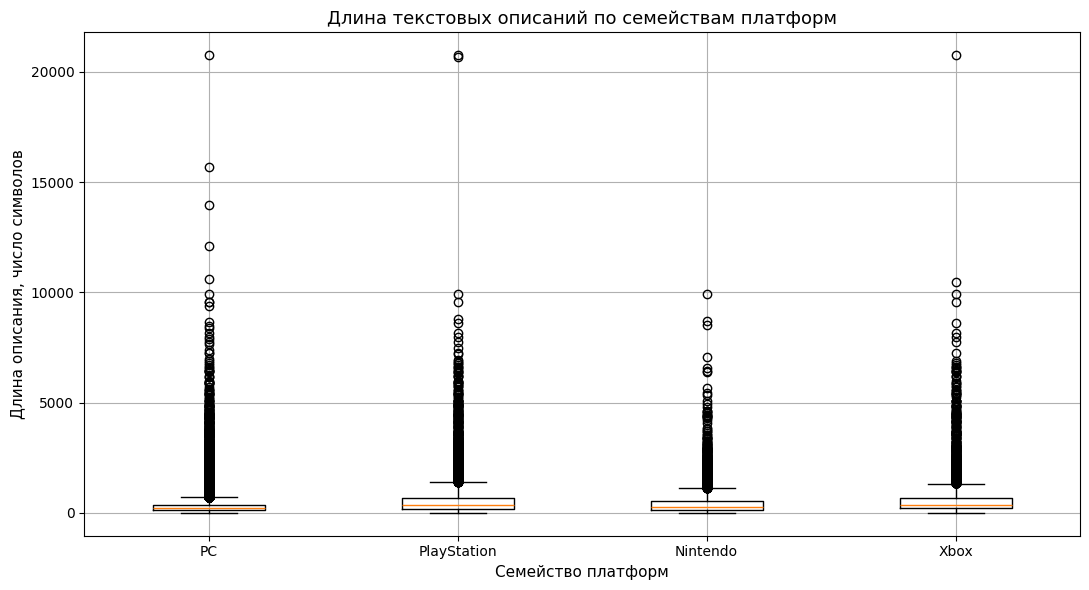

In [29]:
# Строим рисунки, отражающие объем и разброс текстовых описаний

# Рисунок 3. Распределение длины текстовых описаний
description_data = games["description_length_clipped"].dropna()

plt.figure(figsize=(12, 6))
plt.hist(description_data, bins=40)
plt.title("Распределение длины текстовых описаний")
plt.xlabel("Длина описания, число символов")
plt.ylabel("Количество игр")
plt.tight_layout()
plt.show()

# Рисунок 4. Длина текстовых описаний по семействам платформ
platform_order = (
    games.groupby("platform_family")["name"]
    .count()
    .sort_values(ascending=False)
    .index
    .tolist()
)

boxplot_data = [
    games.loc[games["platform_family"] == platform_name, "description_length"].dropna()
    for platform_name in platform_order
]

plt.figure(figsize=(11, 6))
plt.boxplot(boxplot_data, tick_labels=platform_order, vert=True)
plt.title("Длина текстовых описаний по семействам платформ")
plt.xlabel("Семейство платформ")
plt.ylabel("Длина описания, число символов")
plt.tight_layout()
plt.show()

In [30]:
# Формируем дополнительные сводные таблицы для интерпретации результатов

# Десятилетние интервалы для обзора временной структуры корпуса
games["decade"] = (games["release_year_valid"] // 10) * 10
decade_summary = (
    games.dropna(subset=["decade"])
    .groupby("decade", as_index=False)
    .agg(
        games_count=("name", "count"),
        median_description_length=("description_length", "median"),
        description_share=("has_description", "mean"),
        rating_share=("has_rating", "mean")
    )
    .sort_values("decade")
)

decade_summary["description_share"] = (decade_summary["description_share"] * 100).round(2)
decade_summary["rating_share"] = (decade_summary["rating_share"] * 100).round(2)

# Сводка по семействам платформ
platform_detail_summary = (
    games.groupby("platform_family", as_index=False)
    .agg(
        games_count=("name", "count"),
        median_description_length=("description_length", "median"),
        median_rating=("rating", "median"),
        median_review_score=("review_score", "median"),
        rating_share=("has_rating", "mean"),
        review_score_share=("has_review_score", "mean"),
        duration_share=("has_duration_main", "mean")
    )
    .sort_values("games_count", ascending=False)
)

platform_detail_summary["rating_share"] = (platform_detail_summary["rating_share"] * 100).round(2)
platform_detail_summary["review_score_share"] = (platform_detail_summary["review_score_share"] * 100).round(2)
platform_detail_summary["duration_share"] = (platform_detail_summary["duration_share"] * 100).round(2)

print("Сводка по десятилетним интервалам")
display(decade_summary)

print("\nПодробная сводка по семействам платформ")
display(platform_detail_summary)

# Сохраняем только малые итоговые таблицы
genre_summary.to_csv("results/genre_summary_stage_3.csv", index=False)
field_completeness.to_csv("results/field_completeness_stage_3.csv", index=False)
decade_summary.to_csv("results/decade_summary_stage_3.csv", index=False)
platform_detail_summary.to_csv("results/platform_detail_summary_stage_3.csv", index=False)

print("\nСводные таблицы этапа 3 сохранены")

Сводка по десятилетним интервалам


,decade,games_count,median_description_length,description_share,rating_share
0,1990,5601,361.0,91.16,24.23
1,2000,18126,377.0,91.45,33.26
2,2010,59814,261.0,97.41,34.60
3,2020,44171,228.0,96.93,5.06



Подробная сводка по семействам платформ


,platform_family,games_count,median_description_length,median_rating,median_review_score,rating_share,review_score_share,duration_share
1,PC,67978,227.0,70.000000,48.0,17.02,35.29,35.29
2,PlayStation,23608,355.0,70.185542,65.0,30.99,51.60,51.60
0,Nintendo,21906,261.0,70.000000,64.0,26.10,43.64,43.64
3,Xbox,14220,340.0,70.276854,66.0,40.18,54.04,54.04



Сводные таблицы этапа 3 сохранены


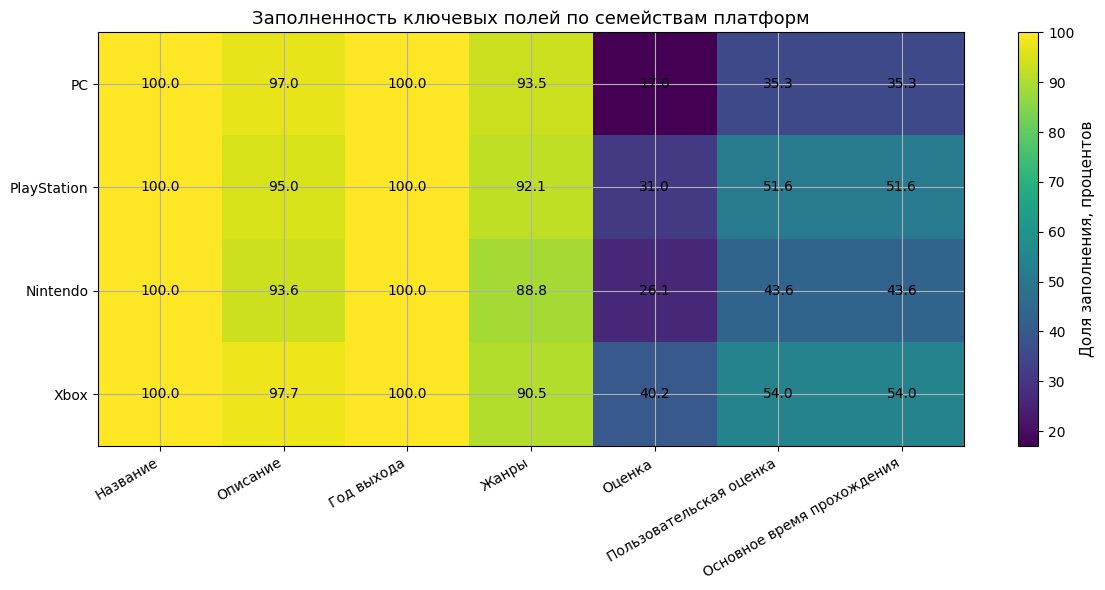

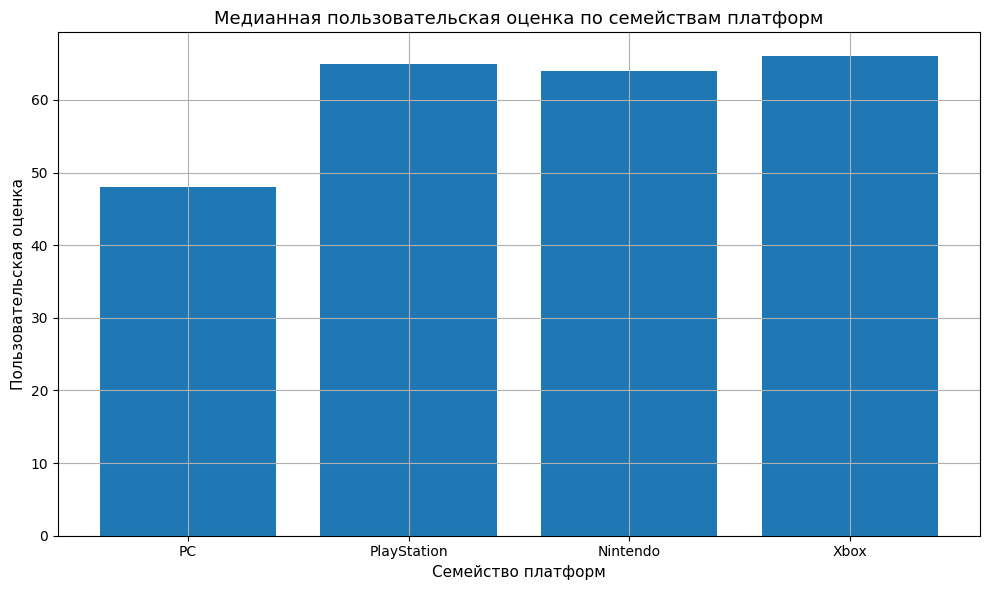

In [31]:
# Строим рисунки по заполненности и платформенным различиям

# Рисунок 5. Тепловая карта заполненности ключевых полей по семействам платформ
fields_for_heatmap = {
    "Название": games["name"].notna(),
    "Описание": games["has_description"],
    "Год выхода": games["release_year_valid"].notna(),
    "Жанры": games["has_genres_text"],
    "Оценка": games["has_rating"],
    "Пользовательская оценка": games["has_review_score"],
    "Основное время прохождения": games["has_duration_main"]
}

heatmap_rows = []
platform_labels = []

for platform_name in platform_order:
    platform_part = games[games["platform_family"] == platform_name]
    platform_labels.append(platform_name)

    row_values = []
    for field_name, field_mask in fields_for_heatmap.items():
        share_value = field_mask.loc[platform_part.index].mean() * 100
        row_values.append(share_value)

    heatmap_rows.append(row_values)

heatmap_matrix = np.array(heatmap_rows)
field_labels = list(fields_for_heatmap.keys())

plt.figure(figsize=(12, 6))
image = plt.imshow(heatmap_matrix, aspect="auto")
plt.colorbar(image, label="Доля заполнения, процентов")
plt.xticks(ticks=np.arange(len(field_labels)), labels=field_labels, rotation=30, ha="right")
plt.yticks(ticks=np.arange(len(platform_labels)), labels=platform_labels)
plt.title("Заполненность ключевых полей по семействам платформ")

# Подписываем числовые значения поверх цветовой матрицы
for i in range(heatmap_matrix.shape[0]):
    for j in range(heatmap_matrix.shape[1]):
        plt.text(j, i, f"{heatmap_matrix[i, j]:.1f}", ha="center", va="center")

plt.tight_layout()
plt.show()

# Рисунок 6. Медианная пользовательская оценка по семействам платформ
review_score_data = platform_detail_summary.dropna(subset=["median_review_score"]).copy()

plt.figure(figsize=(10, 6))
plt.bar(review_score_data["platform_family"], review_score_data["median_review_score"])
plt.title("Медианная пользовательская оценка по семействам платформ")
plt.xlabel("Семейство платформ")
plt.ylabel("Пользовательская оценка")
plt.tight_layout()
plt.show()

Корпус оказался неравномерным по времени и по жанрам: после 2014 года наблюдается резкий рост числа игр, а среди жанров особенно выделяются приключенческие, независимые, имитационные, ролевые и стратегические проекты. Без дополнительного выравнивания результаты будут слишком сильно определяться наиболее массовыми сегментами корпуса.

Текстовые описания присутствуют у подавляющего большинства игр, однако оценки, пользовательские оценки и сведения о продолжительности прохождения заполнены заметно хуже. Следовательно, в основе механизма поиска игровых аналогов разумно использовать именно текстовые описания, жанры, семейства платформ и год выхода, а числовые признаки рассматривать как дополнительные. На следующем этапе формируется экспериментальная выборка и создаются тестовые задания для сравнительного исследования.

# 4. Формирование экспериментальной выборки и тестовых заданий

На данном этапе из общего корпуса выделяется исследовательская подвыборка, пригодная для дальнейшего сравнения трех способов подготовки краткого проектного документа игры. Основная задача состоит в том, чтобы уменьшить влияние перекосов корпуса по жанрам и семействам платформ, сохранив при этом достаточный объем данных для содержательного поиска игровых аналогов.

Научная значимость данного этапа связана с тем, что сильный сравнительный эксперимент невозможен без контролируемой выборки. Поэтому из корпуса отбираются игры с непустым текстовым описанием, разумной длиной текста и устойчивым жанровым представлением. Далее на основе реальных игр формируются тестовые задания без указания названия исходной игры. Это позволяет воспроизводимо сравнивать шаблонный способ, удаленную языковую модель без игровых аналогов и удаленную языковую модель с найденными аналогами.

In [32]:
# Загружаем подготовленную таблицу данных и выполняем начальную настройку признаков

import re
import ast

games = pd.read_csv("results/games_stage_2.csv.gz", compression="gzip")

# Приводим числовые поля к числовому виду
numeric_columns = [
    "release_year",
    "description_length",
    "rating",
    "review_score",
    "review_count",
    "people_polled",
    "main",
    "extra",
    "completionist"
]

for column_name in numeric_columns:
    if column_name in games.columns:
        games[column_name] = pd.to_numeric(games[column_name], errors="coerce")

# Восстанавливаем логический признак наличия описания,
# так как после сохранения и повторной загрузки он может быть прочитан как обычный текст
if "has_description" in games.columns:
    games["has_description"] = games["has_description"].astype(str).str.lower().map(
        {"true": True, "false": False}
    )
else:
    games["has_description"] = games["text_description"].notna()

# Подготавливаем допустимый временной интервал
games["release_year_valid"] = games["release_year"].where(
    (games["release_year"] >= 1995) & (games["release_year"] <= 2023),
    np.nan
)

# Функция преобразования текстового поля жанров в список жанров
def split_genres(genre_text):
    if pd.isna(genre_text):
        return []
    return [item.strip() for item in str(genre_text).split(",") if item.strip() != ""]

games["genre_list"] = games["genre_names_text"].apply(split_genres)

# Базовый отбор записей для дальнейшего исследования
games_filtered = games[
    (games["has_description"] == True) &
    (games["genre_names_text"].notna()) &
    (games["release_year_valid"].notna()) &
    (games["description_length"] >= 80) &
    (games["description_length"] <= 2500)
].copy()

print("Размер исходной таблицы данных:")
print(games.shape)

print("\nРазмер таблицы после базового отбора:")
print(games_filtered.shape)

print("\nДоля записей, сохраненных после базового отбора, процентов:")
print(round(len(games_filtered) / len(games) * 100, 2))

print("\nПервые строки таблицы после базового отбора:")
display(
    games_filtered[
        [
            "id",
            "name",
            "platform_family",
            "genre_names_text",
            "description_length",
            "release_year_valid",
            "text_description"
        ]
    ].head(5)
)

Размер исходной таблицы данных:
(127712, 25)

Размер таблицы после базового отбора:
(103863, 25)

Доля записей, сохраненных после базового отбора, процентов:
81.33

Первые строки таблицы после базового отбора:


,id,name,platform_family,genre_names_text,description_length,release_year_valid,text_description
1,256819,Caverns of Darkness,PC,Shooter,2150,2002.0,The final rift was closed and the Hell War was over at last The citizens of the Earth celebrated for the first time in almost six years The forces of Hell had been beaten Humanity had won Now bega...
2,232860,"Nu, pogodi! Vypusk 1: Pogonya",PC,"Quiz, Adventure",762,2002.0,The wolf decides to take revenge on the Hare for all past grievances However the task is difficult the unlucky predator will have to overcome a lot of obstacles and compete in strength and dexteri...
3,228979,Power Dolls 5,PC,"Role-playing (RPG), Strategy, Turn-based strategy (TBS)",80,2002.0,The fifth entry in Kogado Studios allfemale mech tactical RPG series Power Dolls
4,225648,Kapsyljakt med Anki & Pytte,PC,Point-and-click,211,2002.0,A pointandclick game based on the Swedish childrens program Anki Pytte As the title of the game suggests the game is about collecting bottlecaps by playing different minigames with kapsyljakt mean...
6,194713,Ripple: Blue Seal he Youkoso,PC,Visual Novel,196,2002.0,Main character loses a job and applies for an internet ad vacancy to work at a huge leisure park Blue Seal with multiple facilities including restaurant There are many curious girls working around


In [33]:
# Исследуем жанровую устойчивость и выбираем жанры для контролируемого эксперимента

# Разворачиваем жанры в длинную таблицу
genre_rows = []

for _, row in games_filtered[["id", "name", "platform_family", "genre_list", "description_length", "release_year_valid"]].iterrows():
    for genre_name in row["genre_list"]:
        genre_rows.append(
            {
                "id": row["id"],
                "name": row["name"],
                "platform_family": row["platform_family"],
                "genre_name": genre_name,
                "description_length": row["description_length"],
                "release_year_valid": row["release_year_valid"]
            }
        )

genres_long = pd.DataFrame(genre_rows)

# Подсчитываем число игр по жанрам и число семейств платформ, где жанр представлен
genre_stats = (
    genres_long.groupby("genre_name", as_index=False)
    .agg(
        games_count=("id", "nunique"),
        platform_family_count=("platform_family", "nunique"),
        median_description_length=("description_length", "median"),
        median_release_year=("release_year_valid", "median")
    )
    .sort_values("games_count", ascending=False)
    .reset_index(drop=True)
)

# Выделяем жанры, которые представлены во всех четырех семействах платформ
eligible_genres = genre_stats[
    (genre_stats["platform_family_count"] == 4) &
    (genre_stats["games_count"] >= 5000)
].copy()

# Независимые игры слишком широки по смыслу, поэтому этот жанровый признак
# не используем в качестве главной опоры для сравнения
excluded_genres = {"Indie"}

# Задаем предпочтительный исследовательский порядок жанров
preferred_genres = [
    "Adventure",
    "Simulator",
    "Role-playing (RPG)",
    "Strategy",
    "Shooter",
    "Puzzle",
    "Arcade",
    "Platform"
]

selected_genres = [
    genre_name for genre_name in preferred_genres
    if genre_name in eligible_genres["genre_name"].tolist() and genre_name not in excluded_genres
]

# Ограничиваем число исследуемых жанров для экономии памяти и времени вычислений
selected_genres = selected_genres[:6]

print("Жанры, пригодные для контролируемого эксперимента:")
display(eligible_genres)

print("\nЖанры, выбранные для дальнейшего исследования:")
print(selected_genres)

# Функция выбора главного жанра для каждой игры
def choose_anchor_genre(genre_list, selected_genres_order):
    for genre_name in selected_genres_order:
        if genre_name in genre_list:
            return genre_name
    return np.nan

games_filtered["anchor_genre"] = games_filtered["genre_list"].apply(
    lambda genre_list: choose_anchor_genre(genre_list, selected_genres)
)

# Оставляем только игры, попавшие в выбранные жанры
games_selected = games_filtered[games_filtered["anchor_genre"].notna()].copy()

print("\nРазмер таблицы после отбора по исследуемым жанрам:")
print(games_selected.shape)

genre_platform_table = (
    games_selected.groupby(["anchor_genre", "platform_family"], as_index=False)
    .agg(games_count=("id", "nunique"))
)

print("\nРаспределение игр по жанрам и семействам платформ:")
display(genre_platform_table)

Жанры, пригодные для контролируемого эксперимента:


,genre_name,games_count,platform_family_count,median_description_length,median_release_year
0,Indie,33588,4,249.0,2019.0
1,Adventure,29081,4,296.0,2018.0
2,Simulator,14264,4,274.0,2018.0
3,Strategy,12931,4,280.0,2018.0
4,Role-playing (RPG),12070,4,361.0,2018.0
5,Shooter,9710,4,354.0,2017.0
6,Puzzle,9046,4,309.0,2018.0
7,Arcade,6877,4,291.0,2019.0
8,Platform,6673,4,342.0,2018.0
9,Sport,5121,4,293.0,2016.0



Жанры, выбранные для дальнейшего исследования:
['Adventure', 'Simulator', 'Role-playing (RPG)', 'Strategy', 'Shooter', 'Puzzle']

Размер таблицы после отбора по исследуемым жанрам:
(80252, 26)

Распределение игр по жанрам и семействам платформ:


,anchor_genre,platform_family,games_count
0,Adventure,Nintendo,7468
1,Adventure,PC,21106
2,Adventure,PlayStation,7948
3,Adventure,Xbox,5631
4,Puzzle,Nintendo,1113
5,Puzzle,PC,1807
6,Puzzle,PlayStation,673
7,Puzzle,Xbox,287
8,Role-playing (RPG),Nintendo,756
9,Role-playing (RPG),PC,3189


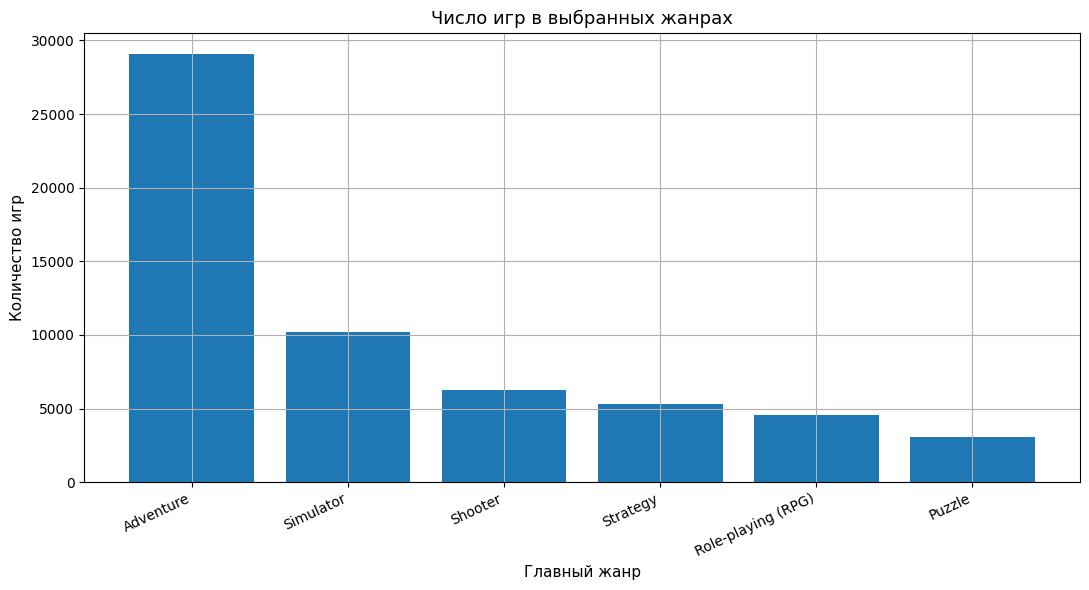

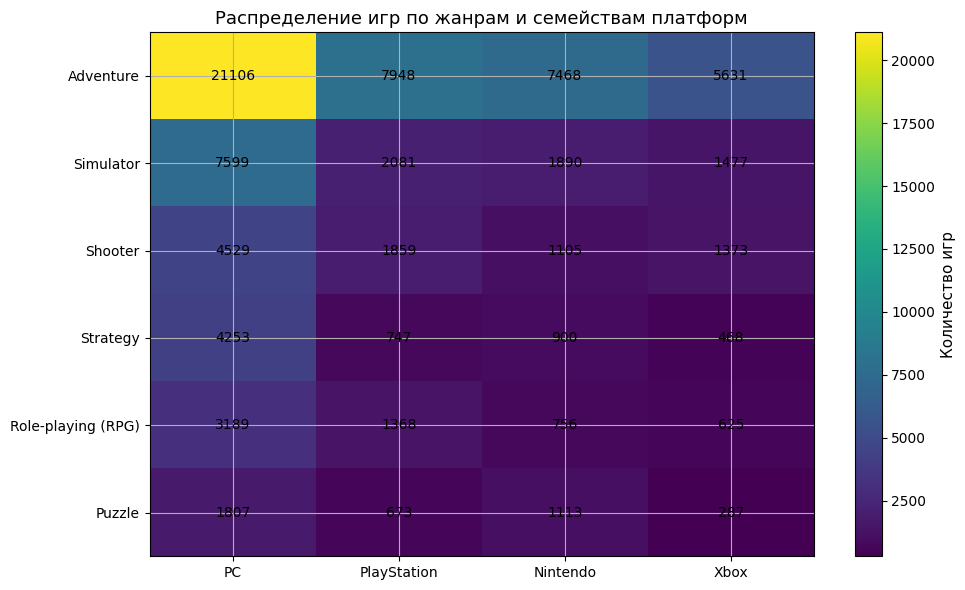

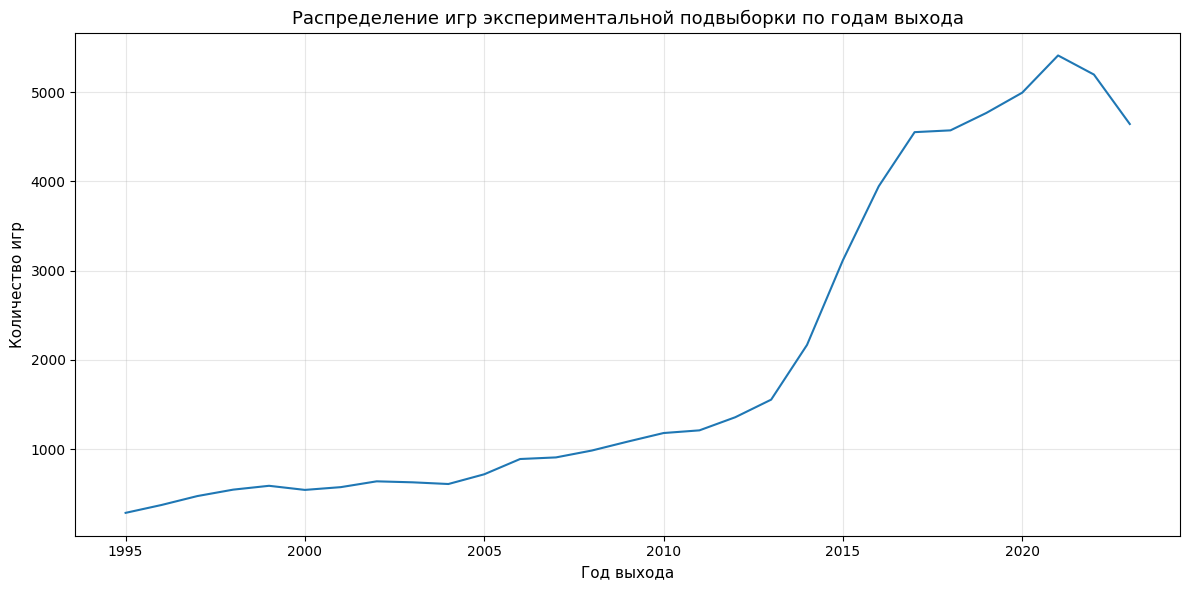

In [34]:
# Строим рисунки, показывающие состав экспериментальной подвыборки

# Рисунок 1. Число игр в выбранных жанрах
selected_genre_summary = (
    games_selected.groupby("anchor_genre", as_index=False)
    .agg(games_count=("id", "nunique"))
    .sort_values("games_count", ascending=False)
)

plt.figure(figsize=(11, 6))
plt.bar(selected_genre_summary["anchor_genre"], selected_genre_summary["games_count"])
plt.title("Число игр в выбранных жанрах")
plt.xlabel("Главный жанр")
plt.ylabel("Количество игр")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# Рисунок 2. Цветовая схема распределения игр по жанрам и семействам платформ
genre_order = selected_genre_summary["anchor_genre"].tolist()
platform_order = ["PC", "PlayStation", "Nintendo", "Xbox"]

heatmap_data = (
    genre_platform_table.pivot(index="anchor_genre", columns="platform_family", values="games_count")
    .reindex(index=genre_order, columns=platform_order)
    .fillna(0)
)

plt.figure(figsize=(10, 6))
image = plt.imshow(heatmap_data.values, aspect="auto")
plt.colorbar(image, label="Количество игр")
plt.xticks(ticks=np.arange(len(platform_order)), labels=platform_order)
plt.yticks(ticks=np.arange(len(genre_order)), labels=genre_order)
plt.title("Распределение игр по жанрам и семействам платформ")

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        plt.text(j, i, f"{int(heatmap_data.iloc[i, j])}", ha="center", va="center")

plt.tight_layout()
plt.show()

# Рисунок 3. Распределение игр экспериментальной подвыборки по годам выхода
year_selected_summary = (
    games_selected.groupby("release_year_valid", as_index=False)
    .agg(games_count=("id", "nunique"))
    .sort_values("release_year_valid")
)

plt.figure(figsize=(12, 6))
plt.plot(year_selected_summary["release_year_valid"], year_selected_summary["games_count"])
plt.title("Распределение игр экспериментальной подвыборки по годам выхода")
plt.xlabel("Год выхода")
plt.ylabel("Количество игр")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# Формируем ограниченный исследовательский корпус и тестовые задания

# Для экономии времени дальнейших вычислений ограничиваем число игр в каждом жанре
# При этом стараемся сохранить жанровое разнообразие
MAX_GAMES_PER_GENRE = 4000

study_corpus_parts = []

for genre_name, part in games_selected.groupby("anchor_genre"):
    part_sampled = part.sample(
        n=min(len(part), MAX_GAMES_PER_GENRE),
        random_state=SEED
    ).copy()
    study_corpus_parts.append(part_sampled)

study_corpus = pd.concat(study_corpus_parts, ignore_index=True)

print("Размер исследовательского корпуса после ограничения по жанрам:")
print(study_corpus.shape)

# Для тестовых заданий выбираем реальные игры,
# но без использования их названий в итоговом тексте задания
TEST_TASKS_PER_GENRE = 8

def pick_balanced_test_games(part, tasks_per_genre, random_state):
    """
    Сначала берем по несколько игр из каждого семейства платформ,
    затем при необходимости добираем оставшиеся игры случайным образом
    """
    rng = np.random.default_rng(random_state)
    chosen_parts = []

    base_quota = max(1, tasks_per_genre // 4)

    for platform_name, platform_part in part.groupby("platform_family"):
        take_n = min(len(platform_part), base_quota)
        if take_n > 0:
            chosen_parts.append(platform_part.sample(n=take_n, random_state=random_state))

    if len(chosen_parts) > 0:
        chosen = pd.concat(chosen_parts, ignore_index=False).drop_duplicates(subset=["id"]).copy()
    else:
        chosen = part.head(0).copy()

    remaining_n = tasks_per_genre - len(chosen)

    if remaining_n > 0:
        rest = part.loc[~part.index.isin(chosen.index)].copy()
        if len(rest) > 0:
            extra = rest.sample(n=min(len(rest), remaining_n), random_state=random_state)
            chosen = pd.concat([chosen, extra], ignore_index=False).drop_duplicates(subset=["id"]).copy()

    return chosen.head(tasks_per_genre).copy()

# Для тестовых заданий задаем более строгий отбор, чтобы задания были достаточно информативными
test_candidates = study_corpus[
    (study_corpus["description_length"] >= 120) &
    (study_corpus["description_length"] <= 1500)
].copy()

test_parts = []

for genre_name, part in test_candidates.groupby("anchor_genre"):
    chosen = pick_balanced_test_games(
        part=part,
        tasks_per_genre=TEST_TASKS_PER_GENRE,
        random_state=SEED
    )
    test_parts.append(chosen)

test_games = pd.concat(test_parts, ignore_index=True).copy()

print("\nРазмер набора тестовых игр:")
print(test_games.shape)

# Удаляем тестовые игры из основного исследовательского корпуса,
# чтобы далее поиск игровых аналогов не опирался на саму целевую игру
study_corpus_final = study_corpus.loc[~study_corpus["id"].isin(test_games["id"])].copy()

print("\nРазмер итогового исследовательского корпуса без тестовых игр:")
print(study_corpus_final.shape)

Размер исследовательского корпуса после ограничения по жанрам:
(23880, 26)

Размер набора тестовых игр:
(48, 26)

Размер итогового исследовательского корпуса без тестовых игр:
(23806, 26)


In [36]:
# Формируем текстовые задания для дальнейшего сравнения трех способов подготовки документа

def shorten_text(text, max_length=220):
    """
    Берем начало описания и делаем его компактным,
    чтобы сохранить смысловое ядро без чрезмерной детализации
    """
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    if len(text) <= max_length:
        return text
    return text[:max_length].rsplit(" ", 1)[0].strip() + "..."

def remove_game_name(text, game_name):
    """
    Удаляем название игры из текстового фрагмента,
    чтобы задание не содержало прямой подсказки
    """
    if text is None:
        return ""
    clean_text = str(text)
    if pd.isna(game_name):
        return clean_text

    game_name_text = str(game_name).strip()
    if game_name_text == "":
        return clean_text

    pattern = re.compile(re.escape(game_name_text), flags=re.IGNORECASE)
    clean_text = pattern.sub("проект", clean_text)
    clean_text = re.sub(r"\s+", " ", clean_text).strip()

    return clean_text

def get_secondary_genres(genre_list, anchor_genre, max_count=2):
    secondary = [genre_name for genre_name in genre_list if genre_name != anchor_genre]
    return secondary[:max_count]

def infer_scope_label(main_value, description_length):
    """
    Определяем ориентировочный масштаб проекта:
    компактный, средний или крупный
    """
    if pd.notna(main_value):
        if main_value < 5:
            return "компактный"
        if main_value < 15:
            return "средний"
        return "крупный"

    if description_length < 250:
        return "компактный"
    if description_length < 700:
        return "средний"
    return "крупный"

brief_rows = []

for _, row in test_games.iterrows():
    anchor_genre = row["anchor_genre"]
    secondary_genres = get_secondary_genres(row["genre_list"], anchor_genre, max_count=2)

    idea_fragment = remove_game_name(
        shorten_text(row["text_description"], max_length=220),
        row["name"]
    )

    if len(secondary_genres) > 0:
        secondary_text = ", ".join(secondary_genres)
    else:
        secondary_text = "отсутствуют"

    scope_label = infer_scope_label(row["main"], row["description_length"])

    brief_text = (
        f"Необходимо подготовить замысел игры для семейства платформ {row['platform_family']}. "
        f"Основной жанровый ориентир проекта: {anchor_genre}. "
        f"Дополнительные жанровые признаки: {secondary_text}. "
        f"Предполагаемый масштаб проекта: {scope_label}. "
        f"Содержательное направление исходной идеи: {idea_fragment}"
    )

    brief_rows.append(
        {
            "task_id": f"TASK_{int(row['id'])}",
            "source_game_id": row["id"],
            "source_game_name": row["name"],
            "platform_family": row["platform_family"],
            "anchor_genre": anchor_genre,
            "secondary_genres_text": secondary_text,
            "release_year_valid": row["release_year_valid"],
            "description_length": row["description_length"],
            "brief_text": brief_text
        }
    )

test_briefs = pd.DataFrame(brief_rows)

print("Размер таблицы тестовых заданий:")
print(test_briefs.shape)

print("\nПервые тестовые задания:")
display(test_briefs.head(10))

Размер таблицы тестовых заданий:
(48, 9)

Первые тестовые задания:


,task_id,source_game_id,source_game_name,platform_family,anchor_genre,secondary_genres_text,release_year_valid,description_length,brief_text
0,TASK_122266,122266,"Dragon Quest 1, 2, 3 Collection",Nintendo,Adventure,Role-playing (RPG),2019.0,181,Необходимо подготовить замысел игры для семейства платформ Nintendo. Основной жанровый ориентир проекта: Adventure. Дополнительные жанровые признаки: Role-playing (RPG). Предполагаемый масштаб про...
1,TASK_102623,102623,Escape Game: Aloha,Nintendo,Adventure,Puzzle,2018.0,176,Необходимо подготовить замысел игры для семейства платформ Nintendo. Основной жанровый ориентир проекта: Adventure. Дополнительные жанровые признаки: Puzzle. Предполагаемый масштаб проекта: компак...
2,TASK_26820,26820,Blasphemous,PC,Adventure,"Platform, Role-playing (RPG)",2019.0,869,"Необходимо подготовить замысел игры для семейства платформ PC. Основной жанровый ориентир проекта: Adventure. Дополнительные жанровые признаки: Platform, Role-playing (RPG). Предполагаемый масштаб..."
3,TASK_248325,248325,Just Keep Running,PC,Adventure,"Platform, Puzzle",2023.0,660,"Необходимо подготовить замысел игры для семейства платформ PC. Основной жанровый ориентир проекта: Adventure. Дополнительные жанровые признаки: Platform, Puzzle. Предполагаемый масштаб проекта: ср..."
4,TASK_136195,136195,Kandagawa Jet Girls: Racing Hearts Edition,PlayStation,Adventure,Racing,2020.0,591,Необходимо подготовить замысел игры для семейства платформ PlayStation. Основной жанровый ориентир проекта: Adventure. Дополнительные жанровые признаки: Racing. Предполагаемый масштаб проекта: сре...
5,TASK_218222,218222,My Universe: My Baby Dragon,PlayStation,Adventure,"Simulator, Indie",2022.0,918,"Необходимо подготовить замысел игры для семейства платформ PlayStation. Основной жанровый ориентир проекта: Adventure. Дополнительные жанровые признаки: Simulator, Indie. Предполагаемый масштаб пр..."
6,TASK_172625,172625,LEGO Dimensions: Excalibur Batman Fun Pack,Xbox,Adventure,Puzzle,2017.0,515,Необходимо подготовить замысел игры для семейства платформ Xbox. Основной жанровый ориентир проекта: Adventure. Дополнительные жанровые признаки: Puzzle. Предполагаемый масштаб проекта: средний. С...
7,TASK_28692,28692,Mulaka,Xbox,Adventure,"Platform, Indie",2018.0,575,"Необходимо подготовить замысел игры для семейства платформ Xbox. Основной жанровый ориентир проекта: Adventure. Дополнительные жанровые признаки: Platform, Indie. Предполагаемый масштаб проекта: с..."
8,TASK_152428,152428,Sweet Sugar Candy,Nintendo,Puzzle,отсутствуют,2021.0,490,Необходимо подготовить замысел игры для семейства платформ Nintendo. Основной жанровый ориентир проекта: Puzzle. Дополнительные жанровые признаки: отсутствуют. Предполагаемый масштаб проекта: сред...
9,TASK_3667,3667,Shrek,Nintendo,Puzzle,Platform,2001.0,784,Необходимо подготовить замысел игры для семейства платформ Nintendo. Основной жанровый ориентир проекта: Puzzle. Дополнительные жанровые признаки: Platform. Предполагаемый масштаб проекта: компакт...


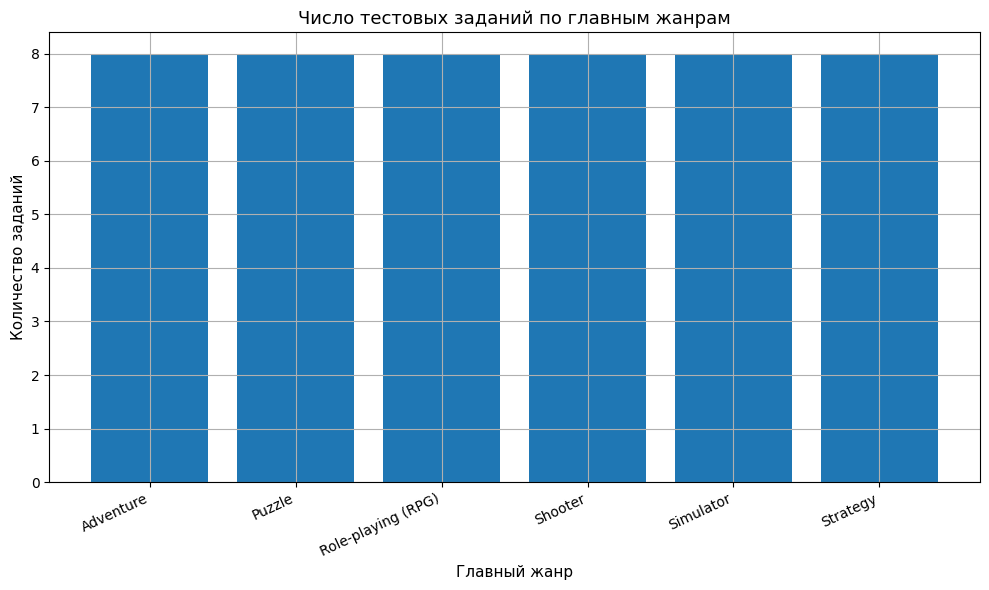

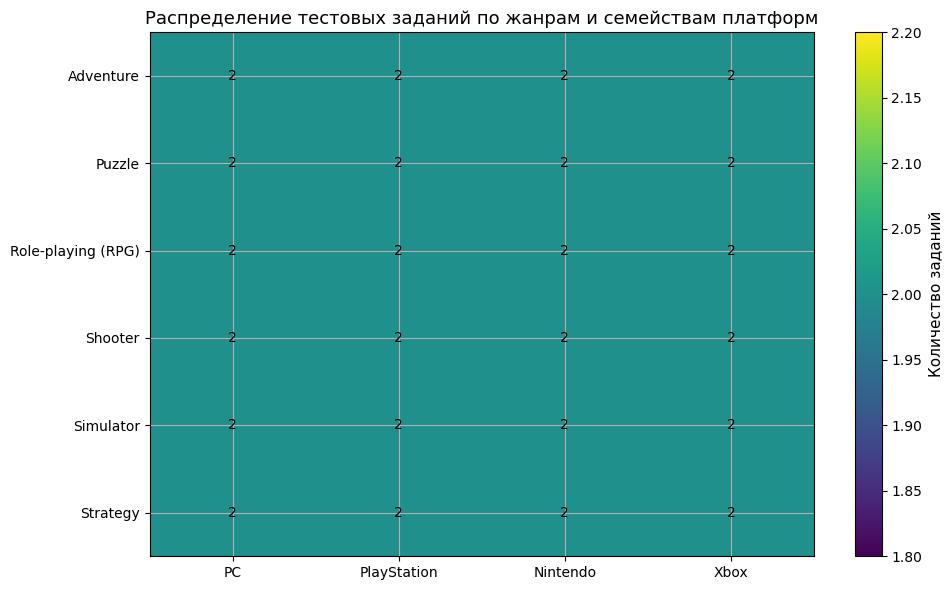

In [37]:
# Строим рисунки по составу тестовых заданий

# Рисунок 4. Число тестовых заданий по главным жанрам
brief_genre_summary = (
    test_briefs.groupby("anchor_genre", as_index=False)
    .agg(tasks_count=("task_id", "count"))
    .sort_values("tasks_count", ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(brief_genre_summary["anchor_genre"], brief_genre_summary["tasks_count"])
plt.title("Число тестовых заданий по главным жанрам")
plt.xlabel("Главный жанр")
plt.ylabel("Количество заданий")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# Рисунок 5. Распределение тестовых заданий по жанрам и семействам платформ
brief_platform_summary = (
    test_briefs.groupby(["anchor_genre", "platform_family"], as_index=False)
    .agg(tasks_count=("task_id", "count"))
)

brief_heatmap = (
    brief_platform_summary.pivot(index="anchor_genre", columns="platform_family", values="tasks_count")
    .reindex(index=brief_genre_summary["anchor_genre"].tolist(), columns=platform_order)
    .fillna(0)
)

plt.figure(figsize=(10, 6))
image = plt.imshow(brief_heatmap.values, aspect="auto")
plt.colorbar(image, label="Количество заданий")
plt.xticks(ticks=np.arange(len(platform_order)), labels=platform_order)
plt.yticks(ticks=np.arange(len(brief_heatmap.index)), labels=brief_heatmap.index.tolist())
plt.title("Распределение тестовых заданий по жанрам и семействам платформ")

for i in range(brief_heatmap.shape[0]):
    for j in range(brief_heatmap.shape[1]):
        plt.text(j, i, f"{int(brief_heatmap.iloc[i, j])}", ha="center", va="center")

plt.tight_layout()
plt.show()

In [38]:
# Сохраняем малые итоговые таблицы этапа

study_corpus_columns = [
    "id",
    "name",
    "platform_family",
    "anchor_genre",
    "genre_names_text",
    "text_description",
    "description_length",
    "release_year_valid",
    "rating",
    "review_score",
    "main",
    "extra",
    "completionist"
]

study_corpus_columns = [column_name for column_name in study_corpus_columns if column_name in study_corpus_final.columns]

study_corpus_final[study_corpus_columns].to_csv(
    "results/study_corpus_stage_4.csv.gz",
    index=False,
    compression="gzip"
)

test_briefs.to_csv(
    "results/test_briefs_stage_4.csv",
    index=False
)

selected_genre_summary.to_csv(
    "results/selected_genre_summary_stage_4.csv",
    index=False
)

print("Исследовательский корпус сохранен в файл results/study_corpus_stage_4.csv.gz")
print("Тестовые задания сохранены в файл results/test_briefs_stage_4.csv")
print("Сводка по выбранным жанрам сохранена в файл results/selected_genre_summary_stage_4.csv")
print(f"Размер итогового исследовательского корпуса: {study_corpus_final.shape}")
print(f"Размер итоговой таблицы тестовых заданий: {test_briefs.shape}")

Исследовательский корпус сохранен в файл results/study_corpus_stage_4.csv.gz
Тестовые задания сохранены в файл results/test_briefs_stage_4.csv
Сводка по выбранным жанрам сохранена в файл results/selected_genre_summary_stage_4.csv
Размер итогового исследовательского корпуса: (23806, 26)
Размер итоговой таблицы тестовых заданий: (48, 9)


Сформирована контролируемая исследовательская подвыборка, в которой сохранен достаточно большой корпус для поиска игровых аналогов и одновременно создан сбалансированный набор тестовых заданий. Важно, что каждое из шести жанровых направлений представлено одинаковым числом заданий, а по семействам платформ обеспечено равномерное покрытие. После исключения тестовых игр из исследовательского корпуса было удалено больше записей, чем число самих заданий. Эксперимент стал чище, поскольку механизм поиска аналогов не сможет опираться на прямые версии целевой игры. На следующем этапе строится воспроизводимый модуль поиска игровых аналогов на основе текстового сходства.

# 5. Построение модуля поиска игровых аналогов

На данном этапе создается воспроизводимый модуль поиска игровых аналогов для каждого тестового задания. Его задача состоит в том, чтобы по краткому описанию замысла игры находить в исследовательском корпусе наиболее близкие проекты. Именно эти найденные аналоги далее будут использоваться как содержательная опора при автоматической подготовке краткого проектного документа игры.

Научная значимость данного этапа состоит в том, что игровые аналоги подбираются не вручную, а по единой вычислительной схеме. Таким образом, можно будет сравнивать не отдельные удачные примеры, а устойчивую работу метода на всем наборе тестовых заданий. Для соблюдения ограничений вычислительной среды используется экономичный способ представления текста, при котором описание каждой игры преобразуется в набор взвешенных словесных признаков, а близость между заданиями и играми измеряется по направлению этих признаков.

In [39]:
# Загружаем исследовательский корпус и тестовые задания,
# подготовленные на предыдущем этапе

import re
import numpy as np
import pandas as pd

SEED = 42
TOP_K = 5

study_corpus = pd.read_csv("results/study_corpus_stage_4.csv.gz", compression="gzip")
test_briefs = pd.read_csv("results/test_briefs_stage_4.csv")

print("Размер исследовательского корпуса:")
print(study_corpus.shape)

print("\nРазмер таблицы тестовых заданий:")
print(test_briefs.shape)

print("\nНазвания полей исследовательского корпуса:")
print(study_corpus.columns.tolist())

print("\nНазвания полей таблицы тестовых заданий:")
print(test_briefs.columns.tolist())

print("\nПервые строки исследовательского корпуса:")
display(study_corpus.head(5))

print("\nПервые строки таблицы тестовых заданий:")
display(test_briefs.head(5))

Размер исследовательского корпуса:
(23806, 13)

Размер таблицы тестовых заданий:
(48, 9)

Названия полей исследовательского корпуса:
['id', 'name', 'platform_family', 'anchor_genre', 'genre_names_text', 'text_description', 'description_length', 'release_year_valid', 'rating', 'review_score', 'main', 'extra', 'completionist']

Названия полей таблицы тестовых заданий:
['task_id', 'source_game_id', 'source_game_name', 'platform_family', 'anchor_genre', 'secondary_genres_text', 'release_year_valid', 'description_length', 'brief_text']

Первые строки исследовательского корпуса:


,id,name,platform_family,anchor_genre,genre_names_text,text_description,description_length,release_year_valid,rating,review_score,main,extra,completionist
0,189076,Mondealy,PC,Adventure,"Role-playing (RPG), Adventure, Indie",Mondealy is about you building relationships and exploring the world An ordinary guy from an ordinary town on an ordinary day uncovers the secrets of an extraordinary underground kingdom located u...,231,2023.0,NaN,69.0,6.97,7.48,9.43
1,256032,Super Dinoblasters,Nintendo,Adventure,"Platform, Adventure, Arcade",B3RN1 Bernie is a patrol bot with the Intergalactic Federation tasked with keeping the galaxy safe from wouldbe villains After receiving a distress signal from Galactic Blast Ranger Pink B3RN1 cha...,238,2023.0,NaN,NaN,NaN,NaN,NaN
2,257192,Rekuiemu Nikki,PC,Adventure,Adventure,Find me otherwise you will lose yourself Rekuiemu Nikki is a Yume Nikki fangame about exploring mind of young Julie who locked herself at home due to adverse circumstances It took quite a long tim...,389,2023.0,NaN,NaN,NaN,NaN,NaN
3,235628,Nith Realms,PC,Adventure,"Adventure, Indie",A freeflow actionadventure game with varied realms to travel through The player will have to defeat powerful bosses and take on dangerous environments in order to obtain the allpowerful elements t...,216,2023.0,NaN,NaN,NaN,NaN,NaN
4,113886,Courage for a Kiss,PC,Adventure,"Simulator, Adventure, Indie",Can a group of high school students write and perform an original stage play and win the national contest Will they find love along the way Find out in this Visual Novel,169,2019.0,NaN,NaN,NaN,NaN,NaN



Первые строки таблицы тестовых заданий:


,task_id,source_game_id,source_game_name,platform_family,anchor_genre,secondary_genres_text,release_year_valid,description_length,brief_text
0,TASK_122266,122266,"Dragon Quest 1, 2, 3 Collection",Nintendo,Adventure,Role-playing (RPG),2019.0,181,Необходимо подготовить замысел игры для семейства платформ Nintendo. Основной жанровый ориентир проекта: Adventure. Дополнительные жанровые признаки: Role-playing (RPG). Предполагаемый масштаб про...
1,TASK_102623,102623,Escape Game: Aloha,Nintendo,Adventure,Puzzle,2018.0,176,Необходимо подготовить замысел игры для семейства платформ Nintendo. Основной жанровый ориентир проекта: Adventure. Дополнительные жанровые признаки: Puzzle. Предполагаемый масштаб проекта: компак...
2,TASK_26820,26820,Blasphemous,PC,Adventure,"Platform, Role-playing (RPG)",2019.0,869,"Необходимо подготовить замысел игры для семейства платформ PC. Основной жанровый ориентир проекта: Adventure. Дополнительные жанровые признаки: Platform, Role-playing (RPG). Предполагаемый масштаб..."
3,TASK_248325,248325,Just Keep Running,PC,Adventure,"Platform, Puzzle",2023.0,660,"Необходимо подготовить замысел игры для семейства платформ PC. Основной жанровый ориентир проекта: Adventure. Дополнительные жанровые признаки: Platform, Puzzle. Предполагаемый масштаб проекта: ср..."
4,TASK_136195,136195,Kandagawa Jet Girls: Racing Hearts Edition,PlayStation,Adventure,Racing,2020.0,591,Необходимо подготовить замысел игры для семейства платформ PlayStation. Основной жанровый ориентир проекта: Adventure. Дополнительные жанровые признаки: Racing. Предполагаемый масштаб проекта: сре...


In [40]:
# Подготавливаем текстовые представления игр и заданий для поиска аналогов

def normalize_text(text):
    """
    Приводим текст к более устойчивому виду:
    убираем лишние пробелы и заменяем пропуски пустой строкой
    """
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def extract_idea_fragment(brief_text):
    """
    Выделяем из текста задания его содержательное ядро,
    то есть краткое описание исходной идеи
    """
    if pd.isna(brief_text):
        return ""

    brief_text = normalize_text(brief_text)
    marker = "Содержательное направление исходной идеи:"

    if marker in brief_text:
        return brief_text.split(marker, 1)[1].strip()

    return brief_text

def build_corpus_text(row):
    """
    Формируем общий текст игры для поиска аналогов.
    В него включаются:
    семейство платформ,
    главный жанр,
    полный перечень жанров,
    текстовое описание игры
    """
    parts = [
        normalize_text(row.get("platform_family", "")),
        normalize_text(row.get("anchor_genre", "")),
        normalize_text(row.get("genre_names_text", "")),
        normalize_text(row.get("text_description", ""))
    ]

    full_text = " ".join([part for part in parts if part != ""])
    full_text = re.sub(r"\s+", " ", full_text).strip()

    return full_text

def build_query_text(row):
    """
    Формируем общий текст задания для поиска аналогов.
    Главный жанр повторяется дважды, чтобы усилить его вклад
    в итоговое сходство
    """
    idea_fragment = extract_idea_fragment(row.get("brief_text", ""))

    parts = [
        normalize_text(row.get("platform_family", "")),
        normalize_text(row.get("anchor_genre", "")),
        normalize_text(row.get("anchor_genre", "")),
        normalize_text(row.get("secondary_genres_text", "")),
        normalize_text(idea_fragment)
    ]

    full_text = " ".join([part for part in parts if part != ""])
    full_text = re.sub(r"\s+", " ", full_text).strip()

    return full_text

study_corpus = study_corpus.copy()
test_briefs = test_briefs.copy()

study_corpus["retrieval_text"] = study_corpus.apply(build_corpus_text, axis=1)
test_briefs["idea_fragment"] = test_briefs["brief_text"].apply(extract_idea_fragment)
test_briefs["query_text"] = test_briefs.apply(build_query_text, axis=1)

# Убираем редкие пустые строки, если они встретятся
study_corpus = study_corpus[study_corpus["retrieval_text"].str.strip() != ""].copy()
test_briefs = test_briefs[test_briefs["query_text"].str.strip() != ""].copy()

print("Размер исследовательского корпуса после подготовки текстов:")
print(study_corpus.shape)

print("\nРазмер таблицы тестовых заданий после подготовки текстов:")
print(test_briefs.shape)

print("\nПримеры текстов игр для поиска аналогов:")
display(
    study_corpus[
        ["name", "platform_family", "anchor_genre", "genre_names_text", "retrieval_text"]
    ].head(5)
)

print("\nПримеры текстов заданий для поиска аналогов:")
display(
    test_briefs[
        ["task_id", "platform_family", "anchor_genre", "secondary_genres_text", "idea_fragment", "query_text"]
    ].head(5)
)

Размер исследовательского корпуса после подготовки текстов:
(23806, 14)

Размер таблицы тестовых заданий после подготовки текстов:
(48, 11)

Примеры текстов игр для поиска аналогов:


,name,platform_family,anchor_genre,genre_names_text,retrieval_text
0,Mondealy,PC,Adventure,"Role-playing (RPG), Adventure, Indie","PC Adventure Role-playing (RPG), Adventure, Indie Mondealy is about you building relationships and exploring the world An ordinary guy from an ordinary town on an ordinary day uncovers the secrets..."
1,Super Dinoblasters,Nintendo,Adventure,"Platform, Adventure, Arcade","Nintendo Adventure Platform, Adventure, Arcade B3RN1 Bernie is a patrol bot with the Intergalactic Federation tasked with keeping the galaxy safe from wouldbe villains After receiving a distress s..."
2,Rekuiemu Nikki,PC,Adventure,Adventure,PC Adventure Adventure Find me otherwise you will lose yourself Rekuiemu Nikki is a Yume Nikki fangame about exploring mind of young Julie who locked herself at home due to adverse circumstances I...
3,Nith Realms,PC,Adventure,"Adventure, Indie","PC Adventure Adventure, Indie A freeflow actionadventure game with varied realms to travel through The player will have to defeat powerful bosses and take on dangerous environments in order to obt..."
4,Courage for a Kiss,PC,Adventure,"Simulator, Adventure, Indie","PC Adventure Simulator, Adventure, Indie Can a group of high school students write and perform an original stage play and win the national contest Will they find love along the way Find out in thi..."



Примеры текстов заданий для поиска аналогов:


,task_id,platform_family,anchor_genre,secondary_genres_text,idea_fragment,query_text
0,TASK_122266,Nintendo,Adventure,Role-playing (RPG),A collection of the first 3 dragon quest games planned for release on the Nintendo Switch No western release was announced but Square Enix Asia listed an English option for the game,Nintendo Adventure Adventure Role-playing (RPG) A collection of the first 3 dragon quest games planned for release on the Nintendo Switch No western release was announced but Square Enix Asia list...
1,TASK_102623,Nintendo,Adventure,Puzzle,You are in a beautiful villa overlooking the sea in Hawaii Find and combine items solve puzzles then escape After the ending play hideandseek with animals Can you find them all,Nintendo Adventure Adventure Puzzle You are in a beautiful villa overlooking the sea in Hawaii Find and combine items solve puzzles then escape After the ending play hideandseek with animals Can y...
2,TASK_26820,PC,Adventure,"Platform, Role-playing (RPG)",проект is a punishing actionplatformer that combines the fastpaced skilled combat of a hacknslash game with a deep and evocative narrative core Explore this nightmarish world of twisted religion a...,"PC Adventure Adventure Platform, Role-playing (RPG) проект is a punishing actionplatformer that combines the fastpaced skilled combat of a hacknslash game with a deep and evocative narrative core ..."
3,TASK_248325,PC,Adventure,"Platform, Puzzle",проект is a parkour puzzleplatformer that combines freerunning with quick puzzles and problemsolving Gameplay is said to be inspired by Mirrors Edge Portal and Ultrakill with voxel graphics inspir...,"PC Adventure Adventure Platform, Puzzle проект is a parkour puzzleplatformer that combines freerunning with quick puzzles and problemsolving Gameplay is said to be inspired by Mirrors Edge Portal ..."
4,TASK_136195,PlayStation,Adventure,Racing,From the creators of SENRAN KAGURA experience a new kind of racing game that blends tight cornering and aerial stunts with rapidfire shootouts all with a shimmering cheerful aesthetic Choose from ...,PlayStation Adventure Adventure Racing From the creators of SENRAN KAGURA experience a new kind of racing game that blends tight cornering and aerial stunts with rapidfire shootouts all with a shi...


In [41]:
# Преобразуем тексты в взвешенное словесное представление
# и получаем матрицы признаков для игр и заданий

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.85,
    max_features=30000
)

corpus_matrix = vectorizer.fit_transform(study_corpus["retrieval_text"])
query_matrix = vectorizer.transform(test_briefs["query_text"])

vocabulary_size = len(vectorizer.get_feature_names_out())
matrix_density = corpus_matrix.nnz / (corpus_matrix.shape[0] * corpus_matrix.shape[1])

print("Размер матрицы признаков для исследовательского корпуса:")
print(corpus_matrix.shape)

print("\nРазмер матрицы признаков для тестовых заданий:")
print(query_matrix.shape)

print(f"\nЧисло словесных признаков: {vocabulary_size}")
print(f"Доля ненулевых значений в матрице корпуса: {matrix_density:.6f}")

print("\nПервые двадцать словесных признаков:")
print(vectorizer.get_feature_names_out()[:20])

Размер матрицы признаков для исследовательского корпуса:
(23806, 30000)

Размер матрицы признаков для тестовых заданий:
(48, 30000)

Число словесных признаков: 30000
Доля ненулевых значений в матрице корпуса: 0.001541

Первые двадцать словесных признаков:
['00' '007' '01' '02' '06' '07' '09' '10' '10 different' '10 hours'
 '10 levels' '10 maps' '10 missions' '10 new' '10 players' '10 second'
 '10 unique' '10 year' '10 years' '100']


In [42]:
# Находим наиболее близкие игры для каждого тестового задания

from sklearn.metrics.pairwise import cosine_similarity

def get_top_indices(score_vector, top_k):
    """
    Возвращаем индексы лучших совпадений в порядке убывания сходства
    """
    top_k = min(top_k, len(score_vector))

    candidate_indices = np.argpartition(score_vector, -top_k)[-top_k:]
    sorted_indices = candidate_indices[np.argsort(score_vector[candidate_indices])[::-1]]

    return sorted_indices

retrieval_rows = []

batch_size = 12

for start_idx in range(0, query_matrix.shape[0], batch_size):
    end_idx = min(start_idx + batch_size, query_matrix.shape[0])

    current_query_matrix = query_matrix[start_idx:end_idx]
    similarity_matrix = cosine_similarity(current_query_matrix, corpus_matrix)

    for local_idx in range(similarity_matrix.shape[0]):
        global_idx = start_idx + local_idx
        current_scores = similarity_matrix[local_idx]

        top_indices = get_top_indices(current_scores, TOP_K)

        task_row = test_briefs.iloc[global_idx]

        for rank_position, corpus_idx in enumerate(top_indices, start=1):
            corpus_row = study_corpus.iloc[corpus_idx]

            retrieval_rows.append(
                {
                    "task_id": task_row["task_id"],
                    "source_game_id": task_row["source_game_id"],
                    "source_game_name": task_row["source_game_name"],
                    "task_platform_family": task_row["platform_family"],
                    "task_anchor_genre": task_row["anchor_genre"],
                    "reference_rank": rank_position,
                    "reference_game_id": corpus_row["id"],
                    "reference_game_name": corpus_row["name"],
                    "reference_platform_family": corpus_row["platform_family"],
                    "reference_anchor_genre": corpus_row["anchor_genre"],
                    "reference_genres_text": corpus_row["genre_names_text"],
                    "reference_release_year": corpus_row["release_year_valid"],
                    "reference_description_length": corpus_row["description_length"],
                    "similarity_score": float(current_scores[corpus_idx])
                }
            )

retrieved_references = pd.DataFrame(retrieval_rows)

print("Размер таблицы найденных игровых аналогов:")
print(retrieved_references.shape)

print("\nПервые найденные игровые аналоги:")
display(retrieved_references.head(15))

Размер таблицы найденных игровых аналогов:
(240, 14)

Первые найденные игровые аналоги:


,task_id,source_game_id,source_game_name,task_platform_family,task_anchor_genre,reference_rank,reference_game_id,reference_game_name,reference_platform_family,reference_anchor_genre,reference_genres_text,reference_release_year,reference_description_length,similarity_score
0,TASK_122266,122266,"Dragon Quest 1, 2, 3 Collection",Nintendo,Adventure,1,80596,Dragon Quest Monsters: Terry no Wonderland 3D,Nintendo,Adventure,"Role-playing (RPG), Adventure",2012.0,157,0.419602
1,TASK_122266,122266,"Dragon Quest 1, 2, 3 Collection",Nintendo,Adventure,2,1821,Dragon Quest X Online,Nintendo,Role-playing (RPG),"Role-playing (RPG), Turn-based strategy (TBS)",2012.0,111,0.359309
2,TASK_122266,122266,"Dragon Quest 1, 2, 3 Collection",Nintendo,Adventure,3,1817,Dragon Quest VI: Realms of Revelation,Nintendo,Role-playing (RPG),"Role-playing (RPG), Sport",2010.0,298,0.332898
3,TASK_122266,122266,"Dragon Quest 1, 2, 3 Collection",Nintendo,Adventure,4,149989,Dragon Quest X Offline,Nintendo,Role-playing (RPG),Role-playing (RPG),2022.0,129,0.321913
4,TASK_122266,122266,"Dragon Quest 1, 2, 3 Collection",Nintendo,Adventure,5,149989,Dragon Quest X Offline,PlayStation,Role-playing (RPG),Role-playing (RPG),2022.0,129,0.308271
5,TASK_102623,102623,Escape Game: Aloha,Nintendo,Adventure,1,110803,Rooms: The Adventure of Anne & George,Nintendo,Adventure,"Puzzle, Adventure",2018.0,160,0.305519
6,TASK_102623,102623,Escape Game: Aloha,Nintendo,Adventure,2,86466,Kate's Test,PC,Adventure,"Role-playing (RPG), Adventure",2018.0,120,0.257163
7,TASK_102623,102623,Escape Game: Aloha,Nintendo,Adventure,3,207703,Spiderbro,PC,Adventure,"Puzzle, Adventure, Indie",2022.0,202,0.253451
8,TASK_102623,102623,Escape Game: Aloha,Nintendo,Adventure,4,84519,Hideaways: Foggy Valley,Nintendo,Puzzle,Puzzle,2014.0,105,0.235103
9,TASK_102623,102623,Escape Game: Aloha,Nintendo,Adventure,5,154508,Call of the Sea: Deluxe Edition,PC,Adventure,"Puzzle, Adventure",2020.0,104,0.225020


In [43]:
# Рассчитываем показатели качества поиска аналогов

references_eval = retrieved_references.copy()

references_eval["genre_match"] = (
    references_eval["task_anchor_genre"] == references_eval["reference_anchor_genre"]
)

references_eval["platform_match"] = (
    references_eval["task_platform_family"] == references_eval["reference_platform_family"]
)

# Добавляем год исходной игры
source_year_lookup = test_briefs.set_index("task_id")["release_year_valid"].to_dict()
references_eval["source_release_year"] = references_eval["task_id"].map(source_year_lookup)

references_eval["year_gap_abs"] = (
    references_eval["source_release_year"] - references_eval["reference_release_year"]
).abs()

# Сводка по каждому заданию
task_retrieval_metrics = (
    references_eval.groupby("task_id", as_index=False)
    .agg(
        source_game_name=("source_game_name", "first"),
        task_platform_family=("task_platform_family", "first"),
        task_anchor_genre=("task_anchor_genre", "first"),
        top_1_similarity=("similarity_score", "max"),
        top_5_mean_similarity=("similarity_score", "mean"),
        top_5_genre_match_share=("genre_match", "mean"),
        top_5_platform_match_share=("platform_match", "mean"),
        top_5_median_year_gap=("year_gap_abs", "median")
    )
)

task_retrieval_metrics["top_5_genre_match_share"] = (
    task_retrieval_metrics["top_5_genre_match_share"] * 100
).round(2)

task_retrieval_metrics["top_5_platform_match_share"] = (
    task_retrieval_metrics["top_5_platform_match_share"] * 100
).round(2)

# Сводка по жанрам
genre_retrieval_metrics = (
    task_retrieval_metrics.groupby("task_anchor_genre", as_index=False)
    .agg(
        tasks_count=("task_id", "count"),
        mean_top_1_similarity=("top_1_similarity", "mean"),
        mean_top_5_similarity=("top_5_mean_similarity", "mean"),
        mean_top_5_genre_match_share=("top_5_genre_match_share", "mean"),
        mean_top_5_platform_match_share=("top_5_platform_match_share", "mean"),
        median_top_5_year_gap=("top_5_median_year_gap", "median")
    )
    .sort_values("tasks_count", ascending=False)
)

# Сводка по семействам платформ
platform_retrieval_metrics = (
    task_retrieval_metrics.groupby("task_platform_family", as_index=False)
    .agg(
        tasks_count=("task_id", "count"),
        mean_top_1_similarity=("top_1_similarity", "mean"),
        mean_top_5_similarity=("top_5_mean_similarity", "mean"),
        mean_top_5_genre_match_share=("top_5_genre_match_share", "mean"),
        mean_top_5_platform_match_share=("top_5_platform_match_share", "mean"),
        median_top_5_year_gap=("top_5_median_year_gap", "median")
    )
    .sort_values("tasks_count", ascending=False)
)

print("Показатели качества поиска по каждому заданию")
display(task_retrieval_metrics.head(10))

print("\nСводка по главным жанрам")
display(genre_retrieval_metrics)

print("\nСводка по семействам платформ")
display(platform_retrieval_metrics)

Показатели качества поиска по каждому заданию


,task_id,source_game_name,task_platform_family,task_anchor_genre,top_1_similarity,top_5_mean_similarity,top_5_genre_match_share,top_5_platform_match_share,top_5_median_year_gap
0,TASK_102623,Escape Game: Aloha,Nintendo,Adventure,0.305519,0.255251,80.0,40.0,2.0
1,TASK_107196,Gear.Club Unlimited 2,Nintendo,Simulator,0.307770,0.269500,100.0,60.0,3.0
2,TASK_10966,Fathom,Xbox,Strategy,0.269746,0.249469,80.0,0.0,10.0
3,TASK_112082,Destiny Connect: Tick-Tock Travelers,Nintendo,Role-playing (RPG),0.360090,0.360090,100.0,0.0,1.0
4,TASK_122266,"Dragon Quest 1, 2, 3 Collection",Nintendo,Adventure,0.419602,0.348399,20.0,80.0,7.0
5,TASK_136195,Kandagawa Jet Girls: Racing Hearts Edition,PlayStation,Adventure,0.292541,0.210367,60.0,60.0,4.0
6,TASK_138332,Moose Life,PlayStation,Shooter,0.251094,0.242492,100.0,40.0,2.0
7,TASK_144870,Puzzling Places,PlayStation,Puzzle,0.304667,0.294784,100.0,60.0,1.0
8,TASK_145741,Mastho is Together,Xbox,Puzzle,0.241386,0.208423,40.0,20.0,2.0
9,TASK_147738,Gryphon Knight Epic: Definitive Edition,PC,Shooter,0.961462,0.369024,100.0,20.0,5.0



Сводка по главным жанрам


,task_anchor_genre,tasks_count,mean_top_1_similarity,mean_top_5_similarity,mean_top_5_genre_match_share,mean_top_5_platform_match_share,median_top_5_year_gap
0,Adventure,8,0.300673,0.243063,67.5,42.5,3.5
1,Puzzle,8,0.265946,0.236898,75.0,45.0,3.5
2,Role-playing (RPG),8,0.363728,0.354537,97.5,27.5,2.0
3,Shooter,8,0.346353,0.245958,85.0,35.0,4.5
4,Simulator,8,0.416871,0.368889,82.5,45.0,4.5
5,Strategy,8,0.290455,0.247544,52.5,42.5,7.0



Сводка по семействам платформ


,task_platform_family,tasks_count,mean_top_1_similarity,mean_top_5_similarity,mean_top_5_genre_match_share,mean_top_5_platform_match_share,median_top_5_year_gap
0,Nintendo,12,0.278008,0.251325,71.666667,35.000000,2.5
1,PC,12,0.435410,0.355744,85.000000,78.333333,2.0
2,PlayStation,12,0.334977,0.281902,71.666667,30.000000,4.5
3,Xbox,12,0.274289,0.242288,78.333333,15.000000,4.5


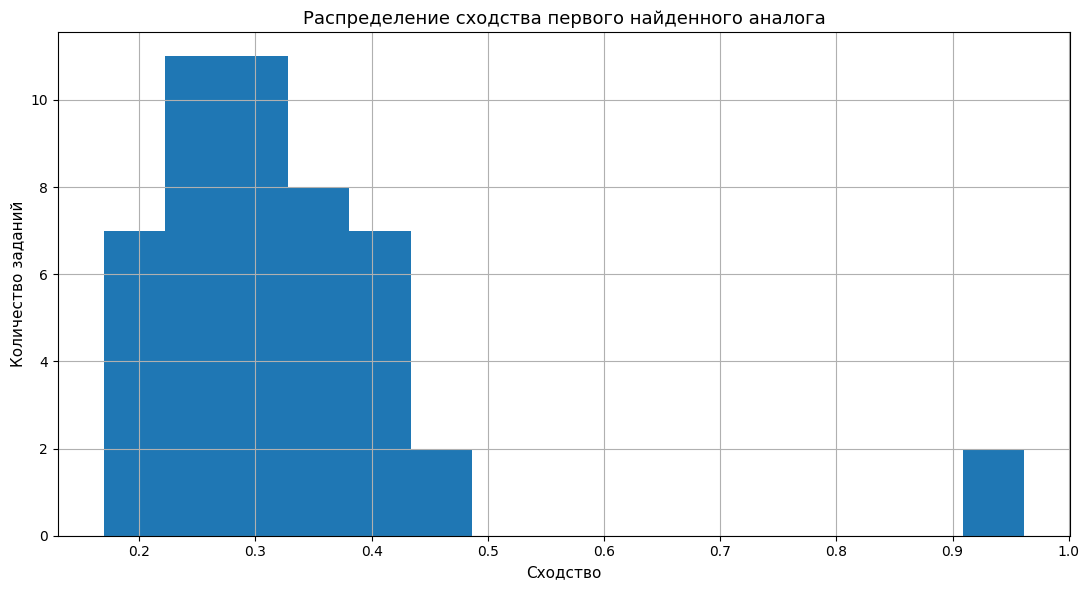

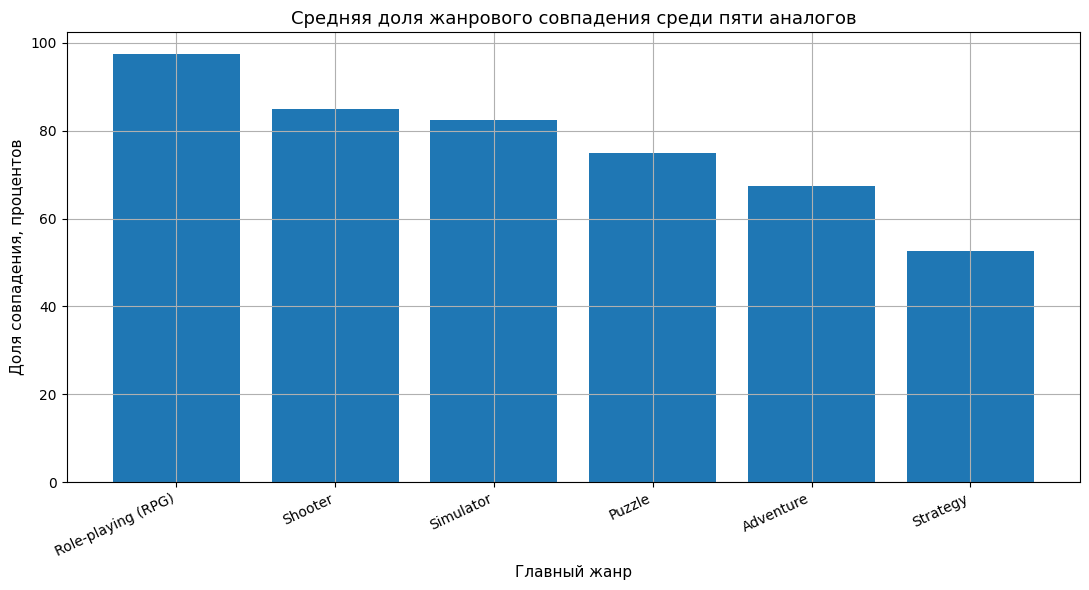

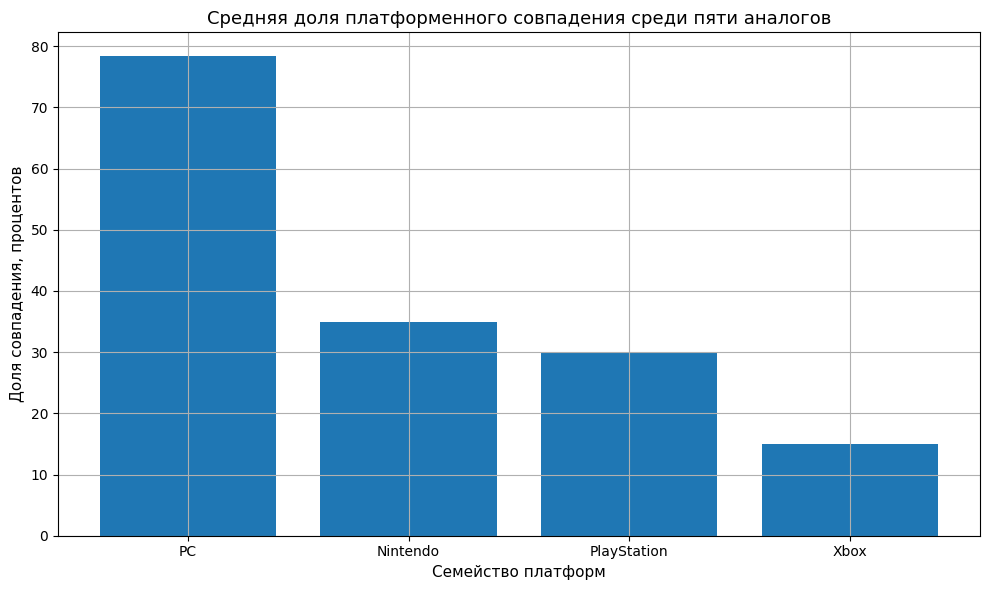

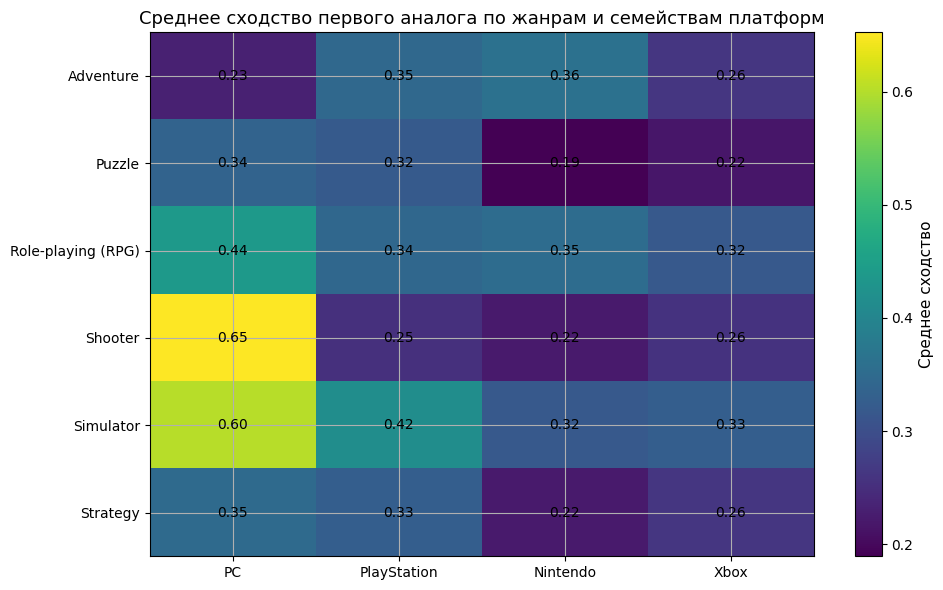

In [44]:
# Строим рисунки, характеризующие качество поиска игровых аналогов

# Рисунок 1. Распределение сходства первого найденного аналога
plt.figure(figsize=(11, 6))
plt.hist(task_retrieval_metrics["top_1_similarity"], bins=15)
plt.title("Распределение сходства первого найденного аналога")
plt.xlabel("Сходство")
plt.ylabel("Количество заданий")
plt.tight_layout()
plt.show()

# Рисунок 2. Средняя доля жанрового совпадения среди пяти аналогов
genre_plot = genre_retrieval_metrics.sort_values(
    "mean_top_5_genre_match_share",
    ascending=False
)

plt.figure(figsize=(11, 6))
plt.bar(genre_plot["task_anchor_genre"], genre_plot["mean_top_5_genre_match_share"])
plt.title("Средняя доля жанрового совпадения среди пяти аналогов")
plt.xlabel("Главный жанр")
plt.ylabel("Доля совпадения, процентов")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# Рисунок 3. Средняя доля платформенного совпадения среди пяти аналогов
platform_plot = platform_retrieval_metrics.sort_values(
    "mean_top_5_platform_match_share",
    ascending=False
)

plt.figure(figsize=(10, 6))
plt.bar(platform_plot["task_platform_family"], platform_plot["mean_top_5_platform_match_share"])
plt.title("Средняя доля платформенного совпадения среди пяти аналогов")
plt.xlabel("Семейство платформ")
plt.ylabel("Доля совпадения, процентов")
plt.tight_layout()
plt.show()

# Рисунок 4. Цветовая схема среднего сходства первого аналога
heatmap_table = (
    task_retrieval_metrics.groupby(["task_anchor_genre", "task_platform_family"], as_index=False)
    .agg(mean_top_1_similarity=("top_1_similarity", "mean"))
    .pivot(index="task_anchor_genre", columns="task_platform_family", values="mean_top_1_similarity")
    .reindex(
        index=sorted(task_retrieval_metrics["task_anchor_genre"].unique().tolist()),
        columns=["PC", "PlayStation", "Nintendo", "Xbox"]
    )
)

plt.figure(figsize=(10, 6))
image = plt.imshow(heatmap_table.values, aspect="auto")
plt.colorbar(image, label="Среднее сходство")
plt.xticks(ticks=np.arange(len(heatmap_table.columns)), labels=heatmap_table.columns.tolist())
plt.yticks(ticks=np.arange(len(heatmap_table.index)), labels=heatmap_table.index.tolist())
plt.title("Среднее сходство первого аналога по жанрам и семействам платформ")

for i in range(heatmap_table.shape[0]):
    for j in range(heatmap_table.shape[1]):
        value = heatmap_table.iloc[i, j]
        if pd.notna(value):
            plt.text(j, i, f"{value:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

In [45]:
# Показываем несколько примеров найденных аналогов для содержательной проверки

example_task_ids = test_briefs["task_id"].head(6).tolist()

example_references = retrieved_references[
    retrieved_references["task_id"].isin(example_task_ids)
].copy()

example_references = example_references.sort_values(
    ["task_id", "reference_rank"]
).reset_index(drop=True)

print("Примеры найденных игровых аналогов для первых заданий")
display(
    example_references[
        [
            "task_id",
            "source_game_name",
            "task_platform_family",
            "task_anchor_genre",
            "reference_rank",
            "reference_game_name",
            "reference_platform_family",
            "reference_anchor_genre",
            "similarity_score"
        ]
    ]
)

Примеры найденных игровых аналогов для первых заданий


,task_id,source_game_name,task_platform_family,task_anchor_genre,reference_rank,reference_game_name,reference_platform_family,reference_anchor_genre,similarity_score
0,TASK_102623,Escape Game: Aloha,Nintendo,Adventure,1,Rooms: The Adventure of Anne & George,Nintendo,Adventure,0.305519
1,TASK_102623,Escape Game: Aloha,Nintendo,Adventure,2,Kate's Test,PC,Adventure,0.257163
2,TASK_102623,Escape Game: Aloha,Nintendo,Adventure,3,Spiderbro,PC,Adventure,0.253451
3,TASK_102623,Escape Game: Aloha,Nintendo,Adventure,4,Hideaways: Foggy Valley,Nintendo,Puzzle,0.235103
4,TASK_102623,Escape Game: Aloha,Nintendo,Adventure,5,Call of the Sea: Deluxe Edition,PC,Adventure,0.225020
5,TASK_122266,"Dragon Quest 1, 2, 3 Collection",Nintendo,Adventure,1,Dragon Quest Monsters: Terry no Wonderland 3D,Nintendo,Adventure,0.419602
6,TASK_122266,"Dragon Quest 1, 2, 3 Collection",Nintendo,Adventure,2,Dragon Quest X Online,Nintendo,Role-playing (RPG),0.359309
7,TASK_122266,"Dragon Quest 1, 2, 3 Collection",Nintendo,Adventure,3,Dragon Quest VI: Realms of Revelation,Nintendo,Role-playing (RPG),0.332898
8,TASK_122266,"Dragon Quest 1, 2, 3 Collection",Nintendo,Adventure,4,Dragon Quest X Offline,Nintendo,Role-playing (RPG),0.321913
9,TASK_122266,"Dragon Quest 1, 2, 3 Collection",Nintendo,Adventure,5,Dragon Quest X Offline,PlayStation,Role-playing (RPG),0.308271


In [46]:
# Сохраняем результаты этапа

retrieved_references.to_csv(
    "results/retrieved_references_stage_5.csv",
    index=False
)

task_retrieval_metrics.to_csv(
    "results/task_retrieval_metrics_stage_5.csv",
    index=False
)

genre_retrieval_metrics.to_csv(
    "results/genre_retrieval_metrics_stage_5.csv",
    index=False
)

platform_retrieval_metrics.to_csv(
    "results/platform_retrieval_metrics_stage_5.csv",
    index=False
)

print("Таблица найденных игровых аналогов сохранена в файл results/retrieved_references_stage_5.csv")
print("Показатели по каждому заданию сохранены в файл results/task_retrieval_metrics_stage_5.csv")
print("Сводка по жанрам сохранена в файл results/genre_retrieval_metrics_stage_5.csv")
print("Сводка по семействам платформ сохранена в файл results/platform_retrieval_metrics_stage_5.csv")
print(f"Число строк в таблице найденных аналогов: {retrieved_references.shape[0]}")
print(f"Число строк в таблице показателей по заданиям: {task_retrieval_metrics.shape[0]}")

Таблица найденных игровых аналогов сохранена в файл results/retrieved_references_stage_5.csv
Показатели по каждому заданию сохранены в файл results/task_retrieval_metrics_stage_5.csv
Сводка по жанрам сохранена в файл results/genre_retrieval_metrics_stage_5.csv
Сводка по семействам платформ сохранена в файл results/platform_retrieval_metrics_stage_5.csv
Число строк в таблице найденных аналогов: 240
Число строк в таблице показателей по заданиям: 48


Поиск игровых аналогов уже сейчас показывает полезную содержательную устойчивость. Жанровое совпадение в среднем высокое, а особенно выражено оно для ролевых, стрелковых и имитационных проектов. Найденные аналоги действительно могут выступать опорным контекстом для последующей автоматической подготовки краткого проектного документа игры. Совпадение по семейству платформ заметно сильнее для персональных компьютеров и слабее для Xbox, а среди найденных аналогов иногда встречаются очень близкие версии одной и той же игровой серии. Поэтому на следующем этапе аналоги будут дополнительно очищаться – теперь исключаются прямые совпадения с исходным названием, а повторяющиеся названия среди аналогов будут сводиться к одному представителю.

# 6. Подготовка кратких проектных документов тремя способами

На данном этапе для каждого тестового задания формируются три варианта краткого проектного документа игры. Первый вариант строится по жесткому шаблону без удаленной языковой модели. Второй вариант подготавливается удаленной языковой моделью только на основе текста задания. Третий вариант подготавливается той же удаленной языковой моделью, но уже с опорой на найденные игровые аналоги из исследовательского корпуса.

Научная значимость данного этапа состоит в том, что сравниваются три четко различающихся способа подготовки документа, что позволяет проверить главную гипотезу исследования: улучшает ли добавление игровых аналогов содержательность, структурную полноту и смысловую согласованность проектного документа по сравнению с шаблонным способом и по сравнению с генерацией без аналогов.

In [47]:
# Загружаем результаты предыдущих этапов и подготавливаем очищенный набор игровых аналогов

import os
import re
import time
from pathlib import Path

import numpy as np
import pandas as pd

study_corpus = pd.read_csv("results/study_corpus_stage_4.csv.gz", compression="gzip")
test_briefs = pd.read_csv("results/test_briefs_stage_4.csv")
retrieved_references = pd.read_csv("results/retrieved_references_stage_5.csv")

print("Размер исследовательского корпуса:")
print(study_corpus.shape)

print("\nРазмер таблицы тестовых заданий:")
print(test_briefs.shape)

print("\nРазмер таблицы найденных игровых аналогов:")
print(retrieved_references.shape)

# Подготавливаем функции нормализации названий,
# чтобы убрать прямые повторения одной и той же игры
def normalize_name(text):
    if pd.isna(text):
        return ""
    text = str(text).lower().strip()
    text = re.sub(r"[^a-zA-Z0-9а-яА-ЯёЁ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Добавляем к таблице аналогов текстовое описание игры из исследовательского корпуса
reference_columns = [
    "id",
    "name",
    "text_description",
    "platform_family",
    "anchor_genre",
    "genre_names_text",
    "release_year_valid",
    "description_length"
]

reference_columns = [column_name for column_name in reference_columns if column_name in study_corpus.columns]

reference_lookup = study_corpus[reference_columns].copy()
reference_lookup = reference_lookup.rename(
    columns={
        "id": "reference_game_id",
        "name": "reference_game_name_from_corpus",
        "text_description": "reference_text_description"
    }
)

references_full = retrieved_references.merge(
    reference_lookup,
    on="reference_game_id",
    how="left"
)

# Удаляем прямые совпадения с исходным названием
references_full["source_name_norm"] = references_full["source_game_name"].apply(normalize_name)
references_full["reference_name_norm"] = references_full["reference_game_name"].apply(normalize_name)

references_full = references_full[
    references_full["source_name_norm"] != references_full["reference_name_norm"]
].copy()

# Для каждого задания оставляем только уникальные названия аналогов
references_full = references_full.sort_values(
    ["task_id", "similarity_score", "reference_rank"],
    ascending=[True, False, True]
).copy()

references_unique = references_full.drop_duplicates(
    subset=["task_id", "reference_name_norm"]
).copy()

# Ограничиваем число аналогов для включения в запрос
MAX_REFERENCES_PER_TASK = 4

references_unique = (
    references_unique.groupby("task_id", group_keys=False)
    .head(MAX_REFERENCES_PER_TASK)
    .reset_index(drop=True)
)

reference_count_summary = (
    references_unique.groupby("task_id", as_index=False)
    .agg(reference_count=("reference_game_id", "count"))
)

print("\nСведения об очищенном наборе аналогов")
print("-" * 70)
print(f"Число строк после удаления прямых совпадений и повторяющихся названий: {references_unique.shape[0]}")
print(f"Минимальное число аналогов на одно задание: {reference_count_summary['reference_count'].min()}")
print(f"Медианное число аналогов на одно задание: {reference_count_summary['reference_count'].median()}")
print(f"Максимальное число аналогов на одно задание: {reference_count_summary['reference_count'].max()}")

print("\nПервые строки очищенной таблицы аналогов:")
display(
    references_unique[
        [
            "task_id",
            "source_game_name",
            "task_platform_family",
            "task_anchor_genre",
            "reference_rank",
            "reference_game_name",
            "reference_platform_family",
            "reference_anchor_genre",
            "similarity_score"
        ]
    ].head(12)
)

Размер исследовательского корпуса:
(23806, 13)

Размер таблицы тестовых заданий:
(48, 9)

Размер таблицы найденных игровых аналогов:
(240, 14)

Сведения об очищенном наборе аналогов
----------------------------------------------------------------------
Число строк после удаления прямых совпадений и повторяющихся названий: 183
Минимальное число аналогов на одно задание: 2
Медианное число аналогов на одно задание: 4.0
Максимальное число аналогов на одно задание: 4

Первые строки очищенной таблицы аналогов:


,task_id,source_game_name,task_platform_family,task_anchor_genre,reference_rank,reference_game_name,reference_platform_family,reference_anchor_genre,similarity_score
0,TASK_102623,Escape Game: Aloha,Nintendo,Adventure,1,Rooms: The Adventure of Anne & George,Nintendo,Adventure,0.305519
1,TASK_102623,Escape Game: Aloha,Nintendo,Adventure,2,Kate's Test,PC,Adventure,0.257163
2,TASK_102623,Escape Game: Aloha,Nintendo,Adventure,3,Spiderbro,PC,Adventure,0.253451
3,TASK_102623,Escape Game: Aloha,Nintendo,Adventure,4,Hideaways: Foggy Valley,Nintendo,Puzzle,0.235103
4,TASK_107196,Gear.Club Unlimited 2,Nintendo,Simulator,1,Uphill Rush Water Park Racing,Nintendo,Simulator,0.307770
5,TASK_107196,Gear.Club Unlimited 2,Nintendo,Simulator,2,Drone Master Racing,Nintendo,Simulator,0.272213
6,TASK_107196,Gear.Club Unlimited 2,Nintendo,Simulator,3,Extreme Racing,PC,Simulator,0.259090
7,TASK_107196,Gear.Club Unlimited 2,Nintendo,Simulator,4,Motorsport Manager for Nintendo Switch,Nintendo,Simulator,0.255027
8,TASK_10966,Fathom,Xbox,Strategy,1,Phalanx of Resistance,PC,Strategy,0.269746
9,TASK_10966,Fathom,Xbox,Strategy,2,Officers,PC,Strategy,0.261888


In [48]:
# Подготавливаем единый шаблон документа и вспомогательные функции

DOCUMENT_SECTIONS = [
    "Название проекта",
    "Краткая концепция",
    "Жанр и целевая аудитория",
    "Основной игровой цикл",
    "Ключевые механики",
    "Платформа",
    "Художественный ориентир",
    "Ограничение по масштабу",
    "Игровые аналоги",
    "Основные риски",
    "Первый план работ"
]

def safe_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def shorten_text(text, max_length=180):
    text = safe_text(text)
    if len(text) <= max_length:
        return text
    return text[:max_length].rsplit(" ", 1)[0].strip() + "..."

def extract_scope_from_brief(brief_text):
    brief_text = safe_text(brief_text)
    match = re.search(r"Предполагаемый масштаб проекта:\s*([^\.]+)", brief_text)
    if match:
        return match.group(1).strip()
    return "средний"

def extract_idea_from_brief(brief_text):
    brief_text = safe_text(brief_text)
    marker = "Содержательное направление исходной идеи:"
    if marker in brief_text:
        return brief_text.split(marker, 1)[1].strip()
    return brief_text

def build_reference_packet(task_id):
    """
    Собираем компактное описание аналогов для включения в запрос
    """
    part = references_unique[references_unique["task_id"] == task_id].copy()

    if len(part) == 0:
        return "Подходящие игровые аналоги не найдены."

    lines = []

    for idx, (_, row) in enumerate(part.iterrows(), start=1):
        description_fragment = shorten_text(row.get("reference_text_description", ""), max_length=180)

        line = (
            f"Аналог {idx}. "
            f"Название: {safe_text(row.get('reference_game_name', ''))}. "
            f"Семейство платформ: {safe_text(row.get('reference_platform_family', ''))}. "
            f"Главный жанр: {safe_text(row.get('reference_anchor_genre', ''))}. "
            f"Полный перечень жанров: {safe_text(row.get('reference_genres_text', ''))}. "
            f"Год выхода: {safe_text(row.get('reference_release_year', ''))}. "
            f"Краткое описание: {description_fragment}"
        )

        lines.append(line)

    return "\n".join(lines)

def format_document(section_dict):
    """
    Приводим документ к единой структуре с одинаковыми заголовками разделов
    """
    parts = []

    for section_name in DOCUMENT_SECTIONS:
        section_text = safe_text(section_dict.get(section_name, ""))
        if section_text == "":
            section_text = "Раздел не заполнен."

        parts.append(f"### {section_name}\n{section_text}")

    return "\n\n".join(parts)

# Небольшие смысловые заготовки для шаблонного способа
genre_mechanics_map = {
    "Adventure": "исследование пространства, поиск маршрутов, взаимодействие с окружением и решение ситуационных задач",
    "Simulator": "последовательное выполнение действий, управление системами и накопление результатов",
    "Role-playing (RPG)": "развитие персонажа, выбор действий, получение ресурсов и постепенное раскрытие мира",
    "Strategy": "планирование, распределение ресурсов, выбор тактики и управление развитием ситуации",
    "Shooter": "перемещение, прицеливание, уклонение, использование оружия и контроль темпа столкновений",
    "Puzzle": "поиск закономерностей, сопоставление объектов, поэтапное решение задач и проверка гипотез"
}

genre_visual_map = {
    "Adventure": "целесообразно использовать выразительные локации, контрастные ориентиры и узнаваемые объекты окружения",
    "Simulator": "целесообразно использовать наглядные интерфейсные элементы, понятные состояния объектов и спокойную визуальную подачу",
    "Role-playing (RPG)": "целесообразно использовать цельный мир, заметные различия персонажей и выразительные сюжетные акценты",
    "Strategy": "целесообразно использовать читаемую карту, ясные обозначения состояний и строгую визуальную иерархию",
    "Shooter": "целесообразно использовать четкие силуэты противников, хорошо различимые зоны опасности и быстрые зрительные сигналы",
    "Puzzle": "целесообразно использовать чистую композицию сцены, контраст между активными и пассивными объектами и минимальный визуальный шум"
}

def build_template_document(row):
    """
    Формируем шаблонный документ без удаленной языковой модели
    """
    anchor_genre = safe_text(row.get("anchor_genre", ""))
    secondary_genres = safe_text(row.get("secondary_genres_text", ""))
    platform_family = safe_text(row.get("platform_family", ""))
    brief_text = safe_text(row.get("brief_text", ""))
    idea_text = extract_idea_from_brief(brief_text)
    scope_text = extract_scope_from_brief(brief_text)

    mechanics_text = genre_mechanics_map.get(
        anchor_genre,
        "исследование пространства, выполнение действий, получение результата и постепенное усложнение задач"
    )

    visual_text = genre_visual_map.get(
        anchor_genre,
        "целесообразно использовать выразительные ориентиры, читаемые объекты и визуально различимые состояния"
    )

    project_suffix = safe_text(row.get("task_id", ""))[-4:]

    if secondary_genres.lower() == "отсутствуют":
        genre_line = f"Основной жанр проекта: {anchor_genre}. Дополнительные жанровые признаки не выделяются."
    else:
        genre_line = f"Основной жанр проекта: {anchor_genre}. Дополнительные жанровые признаки: {secondary_genres}."

    section_dict = {
        "Название проекта": f"Проект {anchor_genre} {project_suffix}",
        "Краткая концепция": (
            f"Предлагается игра для семейства платформ {platform_family}, в которой центральный замысел "
            f"строится вокруг следующего направления: {idea_text}"
        ),
        "Жанр и целевая аудитория": (
            f"{genre_line} Основная аудитория включает пользователей, которым интересны "
            f"{anchor_genre.lower()}-проекты с умеренной сложностью освоения."
        ),
        "Основной игровой цикл": (
            "Игрок получает задачу, изучает игровую ситуацию, выполняет ключевое действие, "
            "получает результат и открывает следующий фрагмент прохождения."
        ),
        "Ключевые механики": (
            f"Базовый набор механик включает {mechanics_text}. "
            "Механики должны сочетаться с постепенным наращиванием сложности."
        ),
        "Платформа": (
            f"Основная целевая группа устройств относится к семейству платформ {platform_family}. "
            "Управление и темп взаимодействия следует подстраивать под особенности данной среды."
        ),
        "Художественный ориентир": visual_text,
        "Ограничение по масштабу": (
            f"Проект следует реализовывать как {scope_text} по масштабу продукт, "
            "в котором объем контента и число систем ограничиваются рамками учебной разработки."
        ),
        "Игровые аналоги": (
            "На данном способе подготовки документа игровые аналоги намеренно не используются, "
            "чтобы сохранить шаблонный базовый уровень для последующего сравнения."
        ),
        "Основные риски": (
            "Главные риски связаны с избыточным расширением замысла, размыванием центральной механики, "
            "а также несоответствием объема контента заявленному масштабу проекта."
        ),
        "Первый план работ": (
            "На первом шаге требуется уточнить ядро замысла, затем зафиксировать набор механик, "
            "после этого определить структуру прототипа и только затем переходить к наполнению контентом."
        )
    }

    return format_document(section_dict)

def count_document_sections(document_text):
    """
    Подсчитываем число разделов по ожидаемым заголовкам
    """
    count_value = 0

    for section_name in DOCUMENT_SECTIONS:
        if f"### {section_name}" in safe_text(document_text):
            count_value += 1

    return count_value

print("Число разделов в едином шаблоне документа:")
print(len(DOCUMENT_SECTIONS))

print("\nПример пакета игровых аналогов для первого задания:")
first_task_id = test_briefs.iloc[0]["task_id"]
print(build_reference_packet(first_task_id))

print("\nПример шаблонного документа для первого задания:")
print(shorten_text(build_template_document(test_briefs.iloc[0]), max_length=900))

Число разделов в едином шаблоне документа:
11

Пример пакета игровых аналогов для первого задания:
Аналог 1. Название: Dragon Quest Monsters: Terry no Wonderland 3D. Семейство платформ: Nintendo. Главный жанр: Adventure. Полный перечень жанров: Role-playing (RPG), Adventure. Год выхода: 2012.0. Краткое описание: Dragon Quest Monsters Terry no Wonderland 3D is the Nintendo 3DS 2012 remake of the 1999 Dragon Quest Monsters Published by Square Enix and developed by TOSE
Аналог 2. Название: Dragon Quest X Online. Семейство платформ: Nintendo. Главный жанр: Role-playing (RPG). Полный перечень жанров: Role-playing (RPG), Turn-based strategy (TBS). Год выхода: 2012.0. Краткое описание: Dragon Quest X is a subscriptionbased MMORPG in the Dragon Quest universe It has had 5 expansions since release
Аналог 3. Название: Dragon Quest VI: Realms of Revelation. Семейство платформ: Nintendo. Главный жанр: Role-playing (RPG). Полный перечень жанров: Role-playing (RPG), Sport. Год выхода: 2010.0. Кратко

In [49]:
# Подготавливаем подключение к удаленной языковой модели
# Если подключение уже было выполнено ранее, используем его повторно

from getpass import getpass
from openai import OpenAI

def get_proxyapi_key():
    """
    Получаем секретный ключ из ранее заданной переменной
    или запрашиваем его вручную
    """
    if "api_key" in globals():
        existing_key = globals().get("api_key")
        if existing_key is not None and str(existing_key).strip() != "":
            return str(existing_key).strip()

    env_key = os.environ.get("PROXYAPI_API_KEY")
    if env_key is not None and str(env_key).strip() != "":
        return str(env_key).strip()

    manual_key = getpass("Введите секретный ключ ProxyAPI: ").strip()
    if manual_key == "":
        raise ValueError("Секретный ключ не введен.")
    return manual_key

# Используем уже созданный объект, если он существует
if "client" not in globals() or client is None:
    api_key = get_proxyapi_key()
    client = OpenAI(
        api_key=api_key,
        base_url="https://openai.api.proxyapi.ru/v1"
    )

# Используем уже выбранную модель, если она существует
if "MODEL_NAME" not in globals() or str(MODEL_NAME).strip() == "":
    MODEL_NAME = "openai/gpt-4o-mini"

print("Подключение к удаленной модели готово")
print(f"Выбранная модель: {MODEL_NAME}")

Подключение к удаленной модели готово
Выбранная модель: openai/gpt-4o-mini


In [50]:
# Формируем документы тремя способами:
# шаблонный способ,
# удаленная языковая модель без аналогов,
# удаленная языковая модель с аналогами

from tqdm.auto import tqdm

OUTPUT_PATH = "results/generated_documents_stage_6.csv"

def build_system_instruction():
    section_list_text = "\n".join([f"- {section_name}" for section_name in DOCUMENT_SECTIONS])

    return (
        "Необходимо подготовить краткий проектный документ игры на русском языке. "
        "Документ должен быть конкретным, сдержанным и пригодным для учебной проектной работы высокого уровня. "
        "Запрещено ссылаться на то, что текст был создан моделью. "
        "Запрещено использовать таблицы. "
        "Необходимо строго соблюдать следующую структуру и порядок разделов:\n"
        f"{section_list_text}\n"
        "Каждый раздел должен начинаться с заголовка вида ### Название раздела. "
        "После каждого заголовка требуется 2 или 3 предложения содержательного текста. "
        "Нужно предложить новое рабочее название проекта, не повторяя название исходной игры и не копируя названия аналогов. "
        "Текст должен быть связным, предметным и не шаблонно-общим."
    )

def build_user_prompt_without_references(row):
    return (
        "Требуется подготовить краткий проектный документ игры только по тексту задания.\n\n"
        "Текст задания:\n"
        f"{safe_text(row['brief_text'])}\n\n"
        "Игровые аналоги использовать нельзя. "
        "Необходимо опираться только на сведения из задания."
    )

def build_user_prompt_with_references(row, reference_packet):
    return (
        "Требуется подготовить краткий проектный документ игры по тексту задания и найденным игровым аналогам.\n\n"
        "Текст задания:\n"
        f"{safe_text(row['brief_text'])}\n\n"
        "Найденные игровые аналоги:\n"
        f"{reference_packet}\n\n"
        "Необходимо использовать аналоги как ориентир, но не копировать их напрямую. "
        "Следует сохранить самостоятельность проектного замысла."
    )

def call_remote_model(prompt_text, model_name, temperature=0.35, max_tokens=950, retries=3):
    """
    Выполняем запрос к удаленной модели с несколькими попытками при временной ошибке
    """
    last_error = None

    for attempt in range(1, retries + 1):
        try:
            start_time = time.time()

            response = client.chat.completions.create(
                model=model_name,
                messages=[
                    {"role": "system", "content": build_system_instruction()},
                    {"role": "user", "content": prompt_text}
                ],
                temperature=temperature,
                max_tokens=max_tokens
            )

            elapsed_seconds = time.time() - start_time
            answer_text = response.choices[0].message.content

            return answer_text, elapsed_seconds, ""

        except Exception as error:
            last_error = str(error)
            time.sleep(1.5 * attempt)

    return "", np.nan, last_error

# Если файл уже существует, можно продолжить запуск без потери уже полученных результатов
if os.path.exists(OUTPUT_PATH):
    generated_documents = pd.read_csv(OUTPUT_PATH)
else:
    generated_documents = pd.DataFrame(
        columns=[
            "task_id",
            "mode",
            "generated_text",
            "elapsed_seconds",
            "reference_count",
            "error_text"
        ]
    )

completed_pairs = set(
    zip(generated_documents["task_id"].astype(str), generated_documents["mode"].astype(str))
)

new_rows = []

# Сначала формируем шаблонные документы без удаленной языковой модели
for _, row in test_briefs.iterrows():
    pair_key = (str(row["task_id"]), "template")

    if pair_key in completed_pairs:
        continue

    reference_count = int((references_unique["task_id"] == row["task_id"]).sum())

    template_text = build_template_document(row)

    new_rows.append(
        {
            "task_id": row["task_id"],
            "mode": "template",
            "generated_text": template_text,
            "elapsed_seconds": 0.0,
            "reference_count": reference_count,
            "error_text": ""
        }
    )

# Затем формируем документы удаленной моделью без аналогов и с аналогами
for mode_name in ["model_without_references", "model_with_references"]:
    for _, row in tqdm(test_briefs.iterrows(), total=len(test_briefs), desc=f"Режим {mode_name}"):
        pair_key = (str(row["task_id"]), mode_name)

        if pair_key in completed_pairs:
            continue

        reference_packet = build_reference_packet(row["task_id"])
        reference_count = int((references_unique["task_id"] == row["task_id"]).sum())

        if mode_name == "model_without_references":
            prompt_text = build_user_prompt_without_references(row)
        else:
            prompt_text = build_user_prompt_with_references(row, reference_packet)

        generated_text, elapsed_seconds, error_text = call_remote_model(
            prompt_text=prompt_text,
            model_name=MODEL_NAME,
            temperature=0.35,
            max_tokens=950,
            retries=3
        )

        new_rows.append(
            {
                "task_id": row["task_id"],
                "mode": mode_name,
                "generated_text": generated_text,
                "elapsed_seconds": elapsed_seconds,
                "reference_count": reference_count,
                "error_text": error_text
            }
        )

        # Периодически сохраняем промежуточный результат,
        # чтобы повторный запуск не тратил средства заново
        if len(new_rows) >= 12:
            generated_documents = pd.concat(
                [generated_documents, pd.DataFrame(new_rows)],
                ignore_index=True
            )
            generated_documents.to_csv(OUTPUT_PATH, index=False)
            completed_pairs = set(
                zip(generated_documents["task_id"].astype(str), generated_documents["mode"].astype(str))
            )
            new_rows = []

# Сохраняем оставшиеся записи
if len(new_rows) > 0:
    generated_documents = pd.concat(
        [generated_documents, pd.DataFrame(new_rows)],
        ignore_index=True
    )

generated_documents.to_csv(OUTPUT_PATH, index=False)

print("Формирование документов завершено")
print(f"Размер итоговой таблицы документов: {generated_documents.shape}")

mode_summary = (
    generated_documents.groupby("mode", as_index=False)
    .agg(
        documents_count=("task_id", "count"),
        mean_elapsed_seconds=("elapsed_seconds", "mean"),
        error_count=("error_text", lambda series: (series.fillna('').astype(str).str.strip() != '').sum())
    )
)

print("\nСводка по режимам формирования документов:")
display(mode_summary)

Режим model_without_references:   0%|          | 0/48 [00:00<?, ?it/s]

Режим model_with_references:   0%|          | 0/48 [00:00<?, ?it/s]

Формирование документов завершено
Размер итоговой таблицы документов: (144, 6)

Сводка по режимам формирования документов:


,mode,documents_count,mean_elapsed_seconds,error_count
0,model_with_references,48,16.270404,0
1,model_without_references,48,12.187175,0
2,template,48,0.000000,0


In [51]:
# Выполняем первичную проверку структуры сформированных документов

generated_documents = pd.read_csv("results/generated_documents_stage_6.csv")

generated_documents["generated_text"] = generated_documents["generated_text"].fillna("").astype(str)
generated_documents["text_length_chars"] = generated_documents["generated_text"].str.len()
generated_documents["section_count"] = generated_documents["generated_text"].apply(count_document_sections)
generated_documents["is_full_structure"] = generated_documents["section_count"] == len(DOCUMENT_SECTIONS)
generated_documents["has_error"] = generated_documents["error_text"].fillna("").astype(str).str.strip() != ""

# Добавляем к результатам сведения о тестовых заданиях
generated_documents = generated_documents.merge(
    test_briefs[
        [
            "task_id",
            "platform_family",
            "anchor_genre",
            "source_game_name",
            "brief_text"
        ]
    ],
    on="task_id",
    how="left"
)

document_quality_summary = (
    generated_documents.groupby("mode", as_index=False)
    .agg(
        documents_count=("task_id", "count"),
        mean_text_length_chars=("text_length_chars", "mean"),
        median_text_length_chars=("text_length_chars", "median"),
        mean_section_count=("section_count", "mean"),
        full_structure_share=("is_full_structure", "mean"),
        error_share=("has_error", "mean"),
        mean_elapsed_seconds=("elapsed_seconds", "mean")
    )
)

document_quality_summary["full_structure_share"] = (
    document_quality_summary["full_structure_share"] * 100
).round(2)

document_quality_summary["error_share"] = (
    document_quality_summary["error_share"] * 100
).round(2)

print("Сводка по качеству структуры документов")
display(document_quality_summary)

print("\nПервые результаты по документам")
display(
    generated_documents[
        [
            "task_id",
            "mode",
            "source_game_name",
            "platform_family",
            "anchor_genre",
            "text_length_chars",
            "section_count",
            "elapsed_seconds",
            "has_error"
        ]
    ].head(12)
)

Сводка по качеству структуры документов


,mode,documents_count,mean_text_length_chars,median_text_length_chars,mean_section_count,full_structure_share,error_share,mean_elapsed_seconds
0,model_with_references,48,2848.916667,2839.0,11.0,100.0,0.0,16.270404
1,model_without_references,48,2695.583333,2673.0,11.0,100.0,0.0,12.187175
2,template,48,2025.354167,2035.0,11.0,100.0,0.0,0.000000



Первые результаты по документам


,task_id,mode,source_game_name,platform_family,anchor_genre,text_length_chars,section_count,elapsed_seconds,has_error
0,TASK_122266,template,"Dragon Quest 1, 2, 3 Collection",Nintendo,Adventure,2022,11,0.0,False
1,TASK_102623,template,Escape Game: Aloha,Nintendo,Adventure,2005,11,0.0,False
2,TASK_26820,template,Blasphemous,PC,Adventure,2050,11,0.0,False
3,TASK_248325,template,Just Keep Running,PC,Adventure,2028,11,0.0,False
4,TASK_136195,template,Kandagawa Jet Girls: Racing Hearts Edition,PlayStation,Adventure,2053,11,0.0,False
5,TASK_218222,template,My Universe: My Baby Dragon,PlayStation,Adventure,2058,11,0.0,False
6,TASK_172625,template,LEGO Dimensions: Excalibur Batman Fun Pack,Xbox,Adventure,2033,11,0.0,False
7,TASK_28692,template,Mulaka,Xbox,Adventure,2048,11,0.0,False
8,TASK_152428,template,Sweet Sugar Candy,Nintendo,Puzzle,2055,11,0.0,False
9,TASK_3667,template,Shrek,Nintendo,Puzzle,2058,11,0.0,False


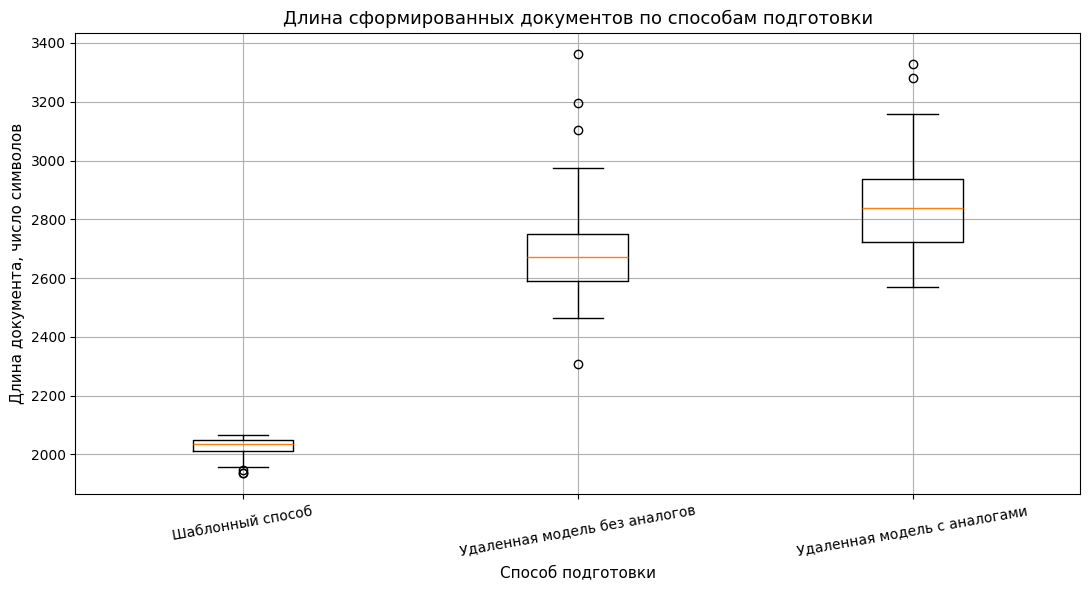

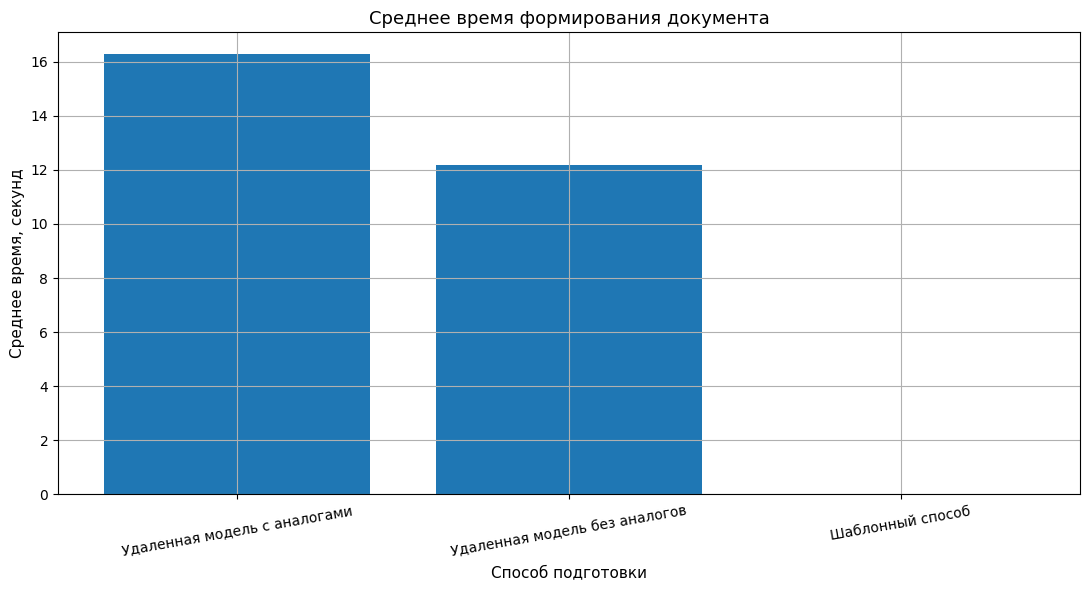

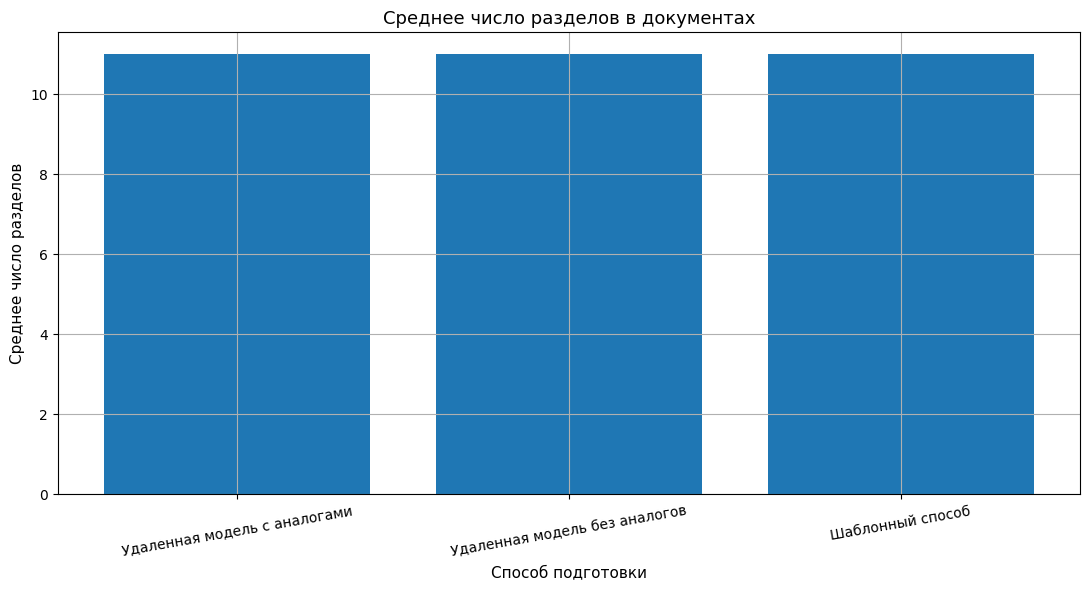

In [52]:
# Строим диагностические рисунки по сформированным документам

# Рисунок 1. Распределение длины документов по способам подготовки
mode_order = ["template", "model_without_references", "model_with_references"]
mode_labels = {
    "template": "Шаблонный способ",
    "model_without_references": "Удаленная модель без аналогов",
    "model_with_references": "Удаленная модель с аналогами"
}

boxplot_data = [
    generated_documents.loc[generated_documents["mode"] == mode_name, "text_length_chars"].dropna()
    for mode_name in mode_order
]

plt.figure(figsize=(11, 6))
plt.boxplot(boxplot_data, tick_labels=[mode_labels[mode_name] for mode_name in mode_order], vert=True)
plt.title("Длина сформированных документов по способам подготовки")
plt.xlabel("Способ подготовки")
plt.ylabel("Длина документа, число символов")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# Рисунок 2. Среднее время формирования документа
time_summary = (
    generated_documents.groupby("mode", as_index=False)
    .agg(mean_elapsed_seconds=("elapsed_seconds", "mean"))
)

time_summary["mode_label"] = time_summary["mode"].map(mode_labels)

plt.figure(figsize=(11, 6))
plt.bar(time_summary["mode_label"], time_summary["mean_elapsed_seconds"])
plt.title("Среднее время формирования документа")
plt.xlabel("Способ подготовки")
plt.ylabel("Среднее время, секунд")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# Рисунок 3. Число разделов в документах по способам подготовки
section_summary = (
    generated_documents.groupby("mode", as_index=False)
    .agg(mean_section_count=("section_count", "mean"))
)

section_summary["mode_label"] = section_summary["mode"].map(mode_labels)

plt.figure(figsize=(11, 6))
plt.bar(section_summary["mode_label"], section_summary["mean_section_count"])
plt.title("Среднее число разделов в документах")
plt.xlabel("Способ подготовки")
plt.ylabel("Среднее число разделов")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

In [53]:
# Показываем примеры документов для содержательной проверки

example_tasks = test_briefs["task_id"].head(2).tolist()

examples_view = generated_documents[
    generated_documents["task_id"].isin(example_tasks)
].copy()

examples_view = examples_view.sort_values(["task_id", "mode"]).reset_index(drop=True)

print("Примеры сформированных документов для первых двух заданий")
display(
    examples_view[
        [
            "task_id",
            "mode",
            "source_game_name",
            "platform_family",
            "anchor_genre",
            "text_length_chars",
            "section_count",
            "generated_text"
        ]
    ]
)

Примеры сформированных документов для первых двух заданий


,task_id,mode,source_game_name,platform_family,anchor_genre,text_length_chars,section_count,generated_text
0,TASK_102623,model_with_references,Escape Game: Aloha,Nintendo,Adventure,3120,11,"### Название проекта\n""Тайны Гавайской Виллы""\n\n### Краткая концепция\nИгроки окажутся в живописной вилле на Гавайях, где им предстоит разгадать тайны, решая головоломки и находя скрытые предметы..."
1,TASK_102623,model_without_references,Escape Game: Aloha,Nintendo,Adventure,2463,11,"### Название проекта\n""Тайна Гавайской Виллы""\n\n### Краткая концепция\nИгрок оказывается в красивой вилле на побережье Гавайев, где ему предстоит разгадать загадки и найти предметы, чтобы выбрать..."
2,TASK_102623,template,Escape Game: Aloha,Nintendo,Adventure,2005,11,"### Название проекта\nПроект Adventure 2623\n\n### Краткая концепция\nПредлагается игра для семейства платформ Nintendo, в которой центральный замысел строится вокруг следующего направления: You a..."
3,TASK_122266,model_with_references,"Dragon Quest 1, 2, 3 Collection",Nintendo,Adventure,2845,11,"### Название проекта\n""Легенды Драконьего Королевства""\n\n### Краткая концепция\nПроект представляет собой сборник первых трех игр серии Dragon Quest, адаптированных для платформы Nintendo Switch...."
4,TASK_122266,model_without_references,"Dragon Quest 1, 2, 3 Collection",Nintendo,Adventure,2660,11,"### Название проекта\n""Драконьи Хроники: Путешествие Сквозь Времена""\n\n### Краткая концепция\nПроект представляет собой сборник первых трех игр серии Dragon Quest, адаптированных для платформы Ni..."
5,TASK_122266,template,"Dragon Quest 1, 2, 3 Collection",Nintendo,Adventure,2022,11,"### Название проекта\nПроект Adventure 2266\n\n### Краткая концепция\nПредлагается игра для семейства платформ Nintendo, в которой центральный замысел строится вокруг следующего направления: A col..."


In [54]:
# Сохраняем итоговые таблицы этапа

generated_documents.to_csv(
    "results/generated_documents_stage_6.csv",
    index=False
)

document_quality_summary.to_csv(
    "results/document_quality_summary_stage_6.csv",
    index=False
)

references_unique.to_csv(
    "results/references_unique_stage_6.csv",
    index=False
)

print("Таблица сформированных документов сохранена в файл results/generated_documents_stage_6.csv")
print("Сводка по качеству структуры документов сохранена в файл results/document_quality_summary_stage_6.csv")
print("Очищенная таблица аналогов сохранена в файл results/references_unique_stage_6.csv")
print(f"Число строк в таблице документов: {generated_documents.shape[0]}")
print(f"Число строк в очищенной таблице аналогов: {references_unique.shape[0]}")

Таблица сформированных документов сохранена в файл results/generated_documents_stage_6.csv
Сводка по качеству структуры документов сохранена в файл results/document_quality_summary_stage_6.csv
Очищенная таблица аналогов сохранена в файл results/references_unique_stage_6.csv
Число строк в таблице документов: 144
Число строк в очищенной таблице аналогов: 183


Все три способа подготовки документа отработали устойчиво. Ошибки отсутствуют, структура во всех случаях соблюдена полностью, а различия между режимами уже видны по длине текста и времени формирования. Особенно важно, что вариант с игровыми аналогами дает более развернутые документы, не нарушая заданную форму.

Далее необходимо показать, что документы различаются не только по объему, но и по содержательному качеству: по жанровой согласованности, предметной насыщенности, явности ограничений по масштабу, фиксации рисков и степени шаблонности.

# 7. Автоматическая экспертная и формальная оценка качества сформированных документов

На данном этапе выполняется корректная оценка кратких проектных документов, полученных тремя способами. Основой сравнения становится автоматизированная экспертная оценка по единой рубрике. Для каждого документа оцениваются соответствие заданию, жанровая согласованность, конкретность механик, реалистичность масштаба, качество выделения рисков и общая связность.

Научная значимость данного этапа состоит в том, что сравнение способов подготовки документа переводится из простого подсчета ключевых слов в более содержательный режим. При этом сохраняются и воспроизводимые количественные признаки: длина документа, полнота структуры, доля явного указания масштаба, доля явного выделения рисков и среднее текстовое сходство внутри каждого способа подготовки.

In [80]:
# Загружаем документы и подготавливаем их к дальнейшей оценке

import re
import os
import json
import time
import numpy as np
import pandas as pd

generated_documents = pd.read_csv("results/generated_documents_stage_6.csv")
test_briefs = pd.read_csv("results/test_briefs_stage_4.csv")

generated_documents["generated_text"] = generated_documents["generated_text"].fillna("").astype(str)

# Служебные поля, которые должны быть у каждой записи
required_metadata_columns = [
    "platform_family",
    "anchor_genre",
    "source_game_name",
    "brief_text"
]

missing_metadata_columns = [
    column_name for column_name in required_metadata_columns
    if column_name not in generated_documents.columns
]

# Добавляем только недостающие поля, чтобы повторный запуск не создавал конфликтов
if len(missing_metadata_columns) > 0:
    metadata_table = test_briefs[["task_id"] + missing_metadata_columns].copy()

    generated_documents = generated_documents.merge(
        metadata_table,
        on="task_id",
        how="left"
    )

DOCUMENT_SECTIONS = [
    "Название проекта",
    "Краткая концепция",
    "Жанр и целевая аудитория",
    "Основной игровой цикл",
    "Ключевые механики",
    "Платформа",
    "Художественный ориентир",
    "Ограничение по масштабу",
    "Игровые аналоги",
    "Основные риски",
    "Первый план работ"
]

MODE_LABELS = {
    "template": "Шаблонный способ",
    "model_without_references": "Удаленная модель без аналогов",
    "model_with_references": "Удаленная модель с аналогами"
}

def safe_text(text):
    """
    Приводим значение к строке без лишних пробелов
    """
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def extract_section_text(document_text, section_name):
    """
    Извлекаем содержимое одного раздела по его заголовку
    """
    document_text = str(document_text)
    pattern = rf"###\s+{re.escape(section_name)}\s*(.*?)(?=###\s+|\Z)"
    match = re.search(pattern, document_text, flags=re.S)

    if match is None:
        return ""

    section_text = match.group(1)
    section_text = re.sub(r"\s+", " ", section_text).strip()
    return section_text

def extract_all_sections(document_text):
    """
    Извлекаем все разделы документа
    """
    section_dict = {}

    for section_name in DOCUMENT_SECTIONS:
        section_dict[section_name] = extract_section_text(document_text, section_name)

    return section_dict

section_rows = []

for _, row in generated_documents.iterrows():
    section_dict = extract_all_sections(row["generated_text"])

    new_row = {
        "task_id": row["task_id"],
        "mode": row["mode"]
    }

    for section_name in DOCUMENT_SECTIONS:
        new_row[f"section_{section_name}"] = section_dict[section_name]

    section_rows.append(new_row)

sections_table = pd.DataFrame(section_rows)

generated_documents = generated_documents.merge(
    sections_table,
    on=["task_id", "mode"],
    how="left"
)

generated_documents["text_length_chars"] = generated_documents["generated_text"].str.len()
generated_documents["section_count"] = generated_documents["generated_text"].apply(
    lambda text: sum([int(f"### {section_name}" in safe_text(text)) for section_name in DOCUMENT_SECTIONS])
)
generated_documents["is_full_structure"] = generated_documents["section_count"] == len(DOCUMENT_SECTIONS)

print("Размер таблицы документов после подготовки:")
print(generated_documents.shape)

print("\nПервые строки таблицы документов:")
display(
    generated_documents[
        [
            "task_id",
            "mode",
            "platform_family",
            "anchor_genre",
            "source_game_name",
            "text_length_chars",
            "section_count",
            "generated_text"
        ]
    ].head(3)
)

Размер таблицы документов после подготовки:
(144, 25)

Первые строки таблицы документов:


,task_id,mode,platform_family,anchor_genre,source_game_name,text_length_chars,section_count,generated_text
0,TASK_122266,template,Nintendo,Adventure,"Dragon Quest 1, 2, 3 Collection",2022,11,"### Название проекта\nПроект Adventure 2266\n\n### Краткая концепция\nПредлагается игра для семейства платформ Nintendo, в которой центральный замысел строится вокруг следующего направления: A col..."
1,TASK_102623,template,Nintendo,Adventure,Escape Game: Aloha,2005,11,"### Название проекта\nПроект Adventure 2623\n\n### Краткая концепция\nПредлагается игра для семейства платформ Nintendo, в которой центральный замысел строится вокруг следующего направления: You a..."
2,TASK_26820,template,PC,Adventure,Blasphemous,2050,11,"### Название проекта\nПроект Adventure 6820\n\n### Краткая концепция\nПредлагается игра для семейства платформ PC, в которой центральный замысел строится вокруг следующего направления: проект is a..."


In [81]:
# Подготавливаем подключение к удаленной модели для экспертной оценки

from getpass import getpass
from openai import OpenAI

def get_proxyapi_key():
    """
    Получаем секретный ключ из уже заданной переменной
    или запрашиваем его вручную
    """
    if "api_key" in globals():
        existing_key = globals().get("api_key")
        if existing_key is not None and str(existing_key).strip() != "":
            return str(existing_key).strip()

    env_key = os.environ.get("PROXYAPI_API_KEY")
    if env_key is not None and str(env_key).strip() != "":
        return str(env_key).strip()

    manual_key = getpass("Введите секретный ключ ProxyAPI: ").strip()
    if manual_key == "":
        raise ValueError("Секретный ключ не введен.")
    return manual_key

if "client" not in globals() or client is None:
    api_key = get_proxyapi_key()
    client = OpenAI(
        api_key=api_key,
        base_url="https://openai.api.proxyapi.ru/v1"
    )

if "MODEL_NAME" not in globals() or str(MODEL_NAME).strip() == "":
    MODEL_NAME = "openai/gpt-4o-mini"

print("Подключение к удаленной модели готово")
print(f"Выбранная модель: {MODEL_NAME}")

Подключение к удаленной модели готово
Выбранная модель: openai/gpt-4o-mini


In [82]:
# Выполняем автоматизированную экспертную оценку документов по единой рубрике

EXPERT_OUTPUT_PATH = "results/expert_evaluation_stage_7.csv"

def build_expert_system_prompt():
    return (
        "Необходимо выполнить экспертную оценку краткого проектного документа игры. "
        "Оценка должна быть строгой, сдержанной и ориентированной на академическую воспроизводимость. "
        "Нельзя оценивать красоту стиля. Нужно оценивать только пригодность документа для проектной работы. "
        "Шкала по каждому критерию: от 1 до 5, где 1 означает очень слабый уровень, а 5 означает очень сильный уровень. "
        "Нужно вернуть только корректный объект в формате JSON без пояснений вне JSON. "
        "Поля JSON: task_fit, genre_fit, mechanics_specificity, scope_realism, risk_quality, coherence, short_comment."
    )

def build_expert_user_prompt(row):
    return (
        "Текст задания:\n"
        f"{safe_text(row['brief_text'])}\n\n"
        "Краткий проектный документ:\n"
        f"{safe_text(row['generated_text'])}\n\n"
        "Необходимо оценить документ по следующим критериям:\n"
        "1. Соответствие заданию.\n"
        "2. Жанровая согласованность.\n"
        "3. Конкретность механик.\n"
        "4. Реалистичность ограничения по масштабу.\n"
        "5. Качество фиксации рисков.\n"
        "6. Связность документа.\n\n"
        "Требования к ответу:\n"
        "Вернуть только JSON.\n"
        "Поля task_fit, genre_fit, mechanics_specificity, scope_realism, risk_quality, coherence должны быть целыми числами от 1 до 5.\n"
        "Поле short_comment должно содержать одно короткое предложение на русском языке."
    )

def extract_json_object(text):
    """
    Извлекаем первый корректный объект JSON из ответа модели
    """
    text = safe_text(text)

    start_index = text.find("{")
    end_index = text.rfind("}")

    if start_index == -1 or end_index == -1 or end_index <= start_index:
        raise ValueError("Объект JSON не найден")

    json_text = text[start_index:end_index + 1]
    return json.loads(json_text)

def validate_expert_result(result_dict):
    """
    Проверяем корректность экспертной оценки
    """
    required_keys = [
        "task_fit",
        "genre_fit",
        "mechanics_specificity",
        "scope_realism",
        "risk_quality",
        "coherence",
        "short_comment"
    ]

    for key_name in required_keys:
        if key_name not in result_dict:
            raise ValueError(f"Отсутствует поле {key_name}")

    score_keys = [
        "task_fit",
        "genre_fit",
        "mechanics_specificity",
        "scope_realism",
        "risk_quality",
        "coherence"
    ]

    for key_name in score_keys:
        value = int(result_dict[key_name])
        if value < 1 or value > 5:
            raise ValueError(f"Поле {key_name} выходит за допустимые границы")

    return True

def call_expert_evaluation(row, retries=3):
    """
    Выполняем запрос к удаленной модели и получаем экспертную оценку
    """
    last_error = ""

    for attempt in range(1, retries + 1):
        try:
            start_time = time.time()

            response = client.chat.completions.create(
                model=MODEL_NAME,
                messages=[
                    {"role": "system", "content": build_expert_system_prompt()},
                    {"role": "user", "content": build_expert_user_prompt(row)}
                ],
                temperature=0.0,
                max_tokens=220
            )

            elapsed_seconds = time.time() - start_time
            answer_text = response.choices[0].message.content

            result_dict = extract_json_object(answer_text)
            validate_expert_result(result_dict)

            result_dict["expert_elapsed_seconds"] = elapsed_seconds
            result_dict["expert_raw_answer"] = answer_text
            result_dict["expert_error_text"] = ""

            return result_dict

        except Exception as error:
            last_error = str(error)
            time.sleep(1.0 * attempt)

    return {
        "task_fit": np.nan,
        "genre_fit": np.nan,
        "mechanics_specificity": np.nan,
        "scope_realism": np.nan,
        "risk_quality": np.nan,
        "coherence": np.nan,
        "short_comment": "",
        "expert_elapsed_seconds": np.nan,
        "expert_raw_answer": "",
        "expert_error_text": last_error
    }

# Если файл уже существует, используем готовый результат
if os.path.exists(EXPERT_OUTPUT_PATH):
    expert_evaluation = pd.read_csv(EXPERT_OUTPUT_PATH)
else:
    expert_evaluation = pd.DataFrame(
        columns=[
            "task_id",
            "mode",
            "task_fit",
            "genre_fit",
            "mechanics_specificity",
            "scope_realism",
            "risk_quality",
            "coherence",
            "short_comment",
            "expert_elapsed_seconds",
            "expert_raw_answer",
            "expert_error_text"
        ]
    )

# Приводим названия столбцов к единому виду, если файл уже был создан ранее
rename_map = {
    "elapsed_seconds": "expert_elapsed_seconds",
    "raw_answer": "expert_raw_answer",
    "error_text": "expert_error_text"
}
expert_evaluation = expert_evaluation.rename(columns=rename_map)

completed_pairs = set(
    zip(expert_evaluation["task_id"].astype(str), expert_evaluation["mode"].astype(str))
)

new_rows = []

for _, row in generated_documents.iterrows():
    pair_key = (str(row["task_id"]), str(row["mode"]))

    if pair_key in completed_pairs:
        continue

    result_dict = call_expert_evaluation(row=row, retries=3)

    new_rows.append(
        {
            "task_id": row["task_id"],
            "mode": row["mode"],
            "task_fit": result_dict["task_fit"],
            "genre_fit": result_dict["genre_fit"],
            "mechanics_specificity": result_dict["mechanics_specificity"],
            "scope_realism": result_dict["scope_realism"],
            "risk_quality": result_dict["risk_quality"],
            "coherence": result_dict["coherence"],
            "short_comment": result_dict["short_comment"],
            "expert_elapsed_seconds": result_dict["expert_elapsed_seconds"],
            "expert_raw_answer": result_dict["expert_raw_answer"],
            "expert_error_text": result_dict["expert_error_text"]
        }
    )

    if len(new_rows) >= 12:
        expert_evaluation = pd.concat(
            [expert_evaluation, pd.DataFrame(new_rows)],
            ignore_index=True
        )
        expert_evaluation.to_csv(EXPERT_OUTPUT_PATH, index=False)
        completed_pairs = set(
            zip(expert_evaluation["task_id"].astype(str), expert_evaluation["mode"].astype(str))
        )
        new_rows = []

if len(new_rows) > 0:
    expert_evaluation = pd.concat(
        [expert_evaluation, pd.DataFrame(new_rows)],
        ignore_index=True
    )

expert_evaluation.to_csv(EXPERT_OUTPUT_PATH, index=False)

print("Экспертная оценка документов завершена")
print(f"Размер таблицы экспертных оценок: {expert_evaluation.shape}")

expert_mode_summary = (
    expert_evaluation.groupby("mode", as_index=False)
    .agg(
        documents_count=("task_id", "count"),
        mean_expert_elapsed_seconds=("expert_elapsed_seconds", "mean"),
        error_count=("expert_error_text", lambda series: (series.fillna('').astype(str).str.strip() != '').sum())
    )
)

print("\nСводка по экспертной оценке:")
display(expert_mode_summary)

Экспертная оценка документов завершена
Размер таблицы экспертных оценок: (144, 12)

Сводка по экспертной оценке:


,mode,documents_count,mean_expert_elapsed_seconds,error_count
0,model_with_references,48,2.189740,0
1,model_without_references,48,2.240389,0
2,template,48,2.478881,0


In [85]:
# Рассчитываем формальные показатели и объединяем их с экспертной оценкой

def count_stem_hits(text, stem_list):
    """
    Подсчитываем число вхождений словесных основ в тексте
    """
    text = safe_text(text).lower()
    total_hits = 0
    unique_hits = 0

    for stem in stem_list:
        hit_count = len(re.findall(re.escape(stem), text))
        total_hits += hit_count

        if hit_count > 0:
            unique_hits += 1

    return total_hits, unique_hits

scope_stems = [
    "компакт", "средн", "круп", "масштаб", "огранич", "прототип",
    "небольш", "умерен", "объем", "учебн"
]

risk_stems = [
    "риск", "угроз", "сложност", "перегруз", "избыточ", "размыван",
    "несоответств", "дефицит", "ошиб", "проблем", "срыв", "затян"
]

platform_names = ["PC", "PlayStation", "Nintendo", "Xbox"]

formal_rows = []

for _, row in generated_documents.iterrows():
    platform_section = safe_text(row.get("section_Платформа", "")).lower()
    scope_section = safe_text(row.get("section_Ограничение по масштабу", ""))
    risk_section = safe_text(row.get("section_Основные риски", ""))

    target_platform = safe_text(row["platform_family"]).lower()

    platform_alignment_flag = int(target_platform in platform_section)

    foreign_platform_mentions = 0
    for platform_name in platform_names:
        platform_text = platform_name.lower()
        if platform_text != target_platform and platform_text in platform_section:
            foreign_platform_mentions += 1

    scope_total_hits, scope_unique_hits = count_stem_hits(scope_section, scope_stems)
    risk_total_hits, risk_unique_hits = count_stem_hits(risk_section, risk_stems)

    scope_clarity_flag = int(scope_unique_hits >= 2)
    risk_clarity_flag = int(risk_unique_hits >= 2)

    formal_rows.append(
        {
            "task_id": row["task_id"],
            "mode": row["mode"],
            "platform_alignment_flag": platform_alignment_flag,
            "foreign_platform_mentions": foreign_platform_mentions,
            "scope_clarity_flag": scope_clarity_flag,
            "risk_clarity_flag": risk_clarity_flag
        }
    )

formal_metrics = pd.DataFrame(formal_rows)

expert_evaluation = pd.read_csv("results/expert_evaluation_stage_7.csv")
expert_evaluation = expert_evaluation.rename(
    columns={
        "elapsed_seconds": "expert_elapsed_seconds",
        "raw_answer": "expert_raw_answer",
        "error_text": "expert_error_text"
    }
)

# Берем за основу уже подготовленную таблицу документов,
# где поля длины текста и полноты структуры уже существуют
document_metrics = generated_documents.copy()

document_metrics = document_metrics.merge(
    formal_metrics,
    on=["task_id", "mode"],
    how="left"
)

document_metrics = document_metrics.merge(
    expert_evaluation[
        [
            "task_id",
            "mode",
            "task_fit",
            "genre_fit",
            "mechanics_specificity",
            "scope_realism",
            "risk_quality",
            "coherence",
            "short_comment",
            "expert_elapsed_seconds",
            "expert_error_text"
        ]
    ],
    on=["task_id", "mode"],
    how="left"
)

score_columns = [
    "task_fit",
    "genre_fit",
    "mechanics_specificity",
    "scope_realism",
    "risk_quality",
    "coherence"
]

document_metrics["expert_total_score"] = (
    document_metrics[score_columns].mean(axis=1) * 20.0
).round(2)

document_metrics["has_expert_error"] = (
    document_metrics["expert_error_text"].fillna("").astype(str).str.strip() != ""
)

print("Размер итоговой таблицы показателей:")
print(document_metrics.shape)

print("\nПервые строки итоговой таблицы показателей:")
display(
    document_metrics[
        [
            "task_id",
            "mode",
            "platform_family",
            "anchor_genre",
            "source_game_name",
            "text_length_chars",
            "section_count",
            "is_full_structure",
            "expert_total_score",
            "task_fit",
            "genre_fit",
            "mechanics_specificity",
            "scope_realism",
            "risk_quality",
            "coherence",
            "platform_alignment_flag",
            "scope_clarity_flag",
            "risk_clarity_flag"
        ]
    ].head(10)
)

Размер итоговой таблицы показателей:
(144, 40)

Первые строки итоговой таблицы показателей:


,task_id,mode,platform_family,anchor_genre,source_game_name,text_length_chars,section_count,is_full_structure,expert_total_score,task_fit,genre_fit,mechanics_specificity,scope_realism,risk_quality,coherence,platform_alignment_flag,scope_clarity_flag,risk_clarity_flag
0,TASK_122266,template,Nintendo,Adventure,"Dragon Quest 1, 2, 3 Collection",2022,11,True,80.00,4,4,3,4,4,5,1,1,1
1,TASK_102623,template,Nintendo,Adventure,Escape Game: Aloha,2005,11,True,83.33,5,4,4,3,4,5,1,1,1
2,TASK_26820,template,PC,Adventure,Blasphemous,2050,11,True,80.00,4,4,3,4,4,5,1,1,1
3,TASK_248325,template,PC,Adventure,Just Keep Running,2028,11,True,80.00,4,4,3,4,4,5,1,1,1
4,TASK_136195,template,PlayStation,Adventure,Kandagawa Jet Girls: Racing Hearts Edition,2053,11,True,80.00,4,4,3,4,4,5,1,1,1
5,TASK_218222,template,PlayStation,Adventure,My Universe: My Baby Dragon,2058,11,True,73.33,4,4,3,3,4,4,1,1,1
6,TASK_172625,template,Xbox,Adventure,LEGO Dimensions: Excalibur Batman Fun Pack,2033,11,True,80.00,4,4,4,3,4,5,1,1,1
7,TASK_28692,template,Xbox,Adventure,Mulaka,2048,11,True,73.33,4,4,3,4,4,3,1,1,1
8,TASK_152428,template,Nintendo,Puzzle,Sweet Sugar Candy,2055,11,True,83.33,5,4,4,3,4,5,1,1,1
9,TASK_3667,template,Nintendo,Puzzle,Shrek,2058,11,True,80.00,4,5,4,4,3,4,1,1,1


In [86]:
# Формируем сводные таблицы по способам подготовки и рассчитываем степень шаблонности

mode_quality_summary = (
    document_metrics.groupby("mode", as_index=False)
    .agg(
        documents_count=("task_id", "count"),
        mean_expert_total_score=("expert_total_score", "mean"),
        mean_task_fit=("task_fit", "mean"),
        mean_genre_fit=("genre_fit", "mean"),
        mean_mechanics_specificity=("mechanics_specificity", "mean"),
        mean_scope_realism=("scope_realism", "mean"),
        mean_risk_quality=("risk_quality", "mean"),
        mean_coherence=("coherence", "mean"),
        platform_alignment_share=("platform_alignment_flag", "mean"),
        scope_clarity_share=("scope_clarity_flag", "mean"),
        risk_clarity_share=("risk_clarity_flag", "mean"),
        mean_text_length_chars=("text_length_chars", "mean"),
        full_structure_share=("is_full_structure", "mean")
    )
)

for column_name in [
    "platform_alignment_share",
    "scope_clarity_share",
    "risk_clarity_share",
    "full_structure_share"
]:
    mode_quality_summary[column_name] = (mode_quality_summary[column_name] * 100).round(2)

mode_quality_summary["mode_label"] = mode_quality_summary["mode"].map(MODE_LABELS)

genre_mode_quality_summary = (
    document_metrics.groupby(["anchor_genre", "mode"], as_index=False)
    .agg(
        documents_count=("task_id", "count"),
        mean_expert_total_score=("expert_total_score", "mean"),
        mean_genre_fit=("genre_fit", "mean"),
        mean_mechanics_specificity=("mechanics_specificity", "mean"),
        mean_coherence=("coherence", "mean")
    )
)

def build_pairwise_similarity(values):
    """
    Строим попарное сходство между текстами одного способа подготовки
    """
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity

    clean_values = [safe_text(value) for value in values]

    if len(clean_values) < 2:
        return np.nan, np.nan

    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=1,
        max_df=0.95,
        max_features=12000
    )

    matrix = vectorizer.fit_transform(clean_values)
    sim_matrix = cosine_similarity(matrix)

    upper_values = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]

    if len(upper_values) == 0:
        return np.nan, np.nan

    return float(np.mean(upper_values)), float(np.median(upper_values))

template_similarity_rows = []

for mode_name, part in document_metrics.groupby("mode"):
    mean_similarity, median_similarity = build_pairwise_similarity(part["generated_text"].tolist())

    template_similarity_rows.append(
        {
            "mode": mode_name,
            "mode_label": MODE_LABELS.get(mode_name, mode_name),
            "mean_pairwise_similarity": round(mean_similarity, 4) if pd.notna(mean_similarity) else np.nan,
            "median_pairwise_similarity": round(median_similarity, 4) if pd.notna(median_similarity) else np.nan
        }
    )

template_similarity_summary = pd.DataFrame(template_similarity_rows)

print("Сводка по способам подготовки:")
display(mode_quality_summary)

print("\nСводка по жанрам и способам подготовки:")
display(genre_mode_quality_summary.head(18))

print("\nСводка по внутригрупповому текстовому сходству:")
display(template_similarity_summary)

Сводка по способам подготовки:


,mode,documents_count,mean_expert_total_score,mean_task_fit,mean_genre_fit,mean_mechanics_specificity,mean_scope_realism,mean_risk_quality,mean_coherence,platform_alignment_share,scope_clarity_share,risk_clarity_share,mean_text_length_chars,full_structure_share,mode_label
0,model_with_references,48,85.347500,4.979167,4.437500,4.000000,4.166667,3.125000,4.895833,100.0,89.58,89.58,2848.916667,100.0,Удаленная модель с аналогами
1,model_without_references,48,85.208750,4.958333,4.395833,4.000000,4.354167,3.104167,4.750000,100.0,95.83,89.58,2695.583333,100.0,Удаленная модель без аналогов
2,template,48,79.374583,4.041667,4.187500,3.333333,3.937500,3.812500,4.500000,100.0,100.00,100.00,2025.354167,100.0,Шаблонный способ



Сводка по жанрам и способам подготовки:


,anchor_genre,mode,documents_count,mean_expert_total_score,mean_genre_fit,mean_mechanics_specificity,mean_coherence
0,Adventure,model_with_references,8,86.25000,4.500,4.000,5.000
1,Adventure,model_without_references,8,85.83375,4.500,4.000,4.875
2,Adventure,template,8,78.74875,4.000,3.250,4.625
3,Puzzle,model_with_references,8,86.25000,4.500,4.000,5.000
4,Puzzle,model_without_references,8,85.41750,4.500,4.000,4.750
5,Puzzle,template,8,82.91500,4.375,3.750,4.625
6,Role-playing (RPG),model_with_references,8,85.00000,4.500,4.000,4.875
7,Role-playing (RPG),model_without_references,8,85.41750,4.375,4.000,5.000
8,Role-playing (RPG),template,8,77.08375,4.750,3.125,3.750
9,Shooter,model_with_references,8,86.25250,4.750,4.000,5.000



Сводка по внутригрупповому текстовому сходству:


,mode,mode_label,mean_pairwise_similarity,median_pairwise_similarity
0,model_with_references,Удаленная модель с аналогами,0.0667,0.0639
1,model_without_references,Удаленная модель без аналогов,0.0663,0.0629
2,template,Шаблонный способ,0.0725,0.0218


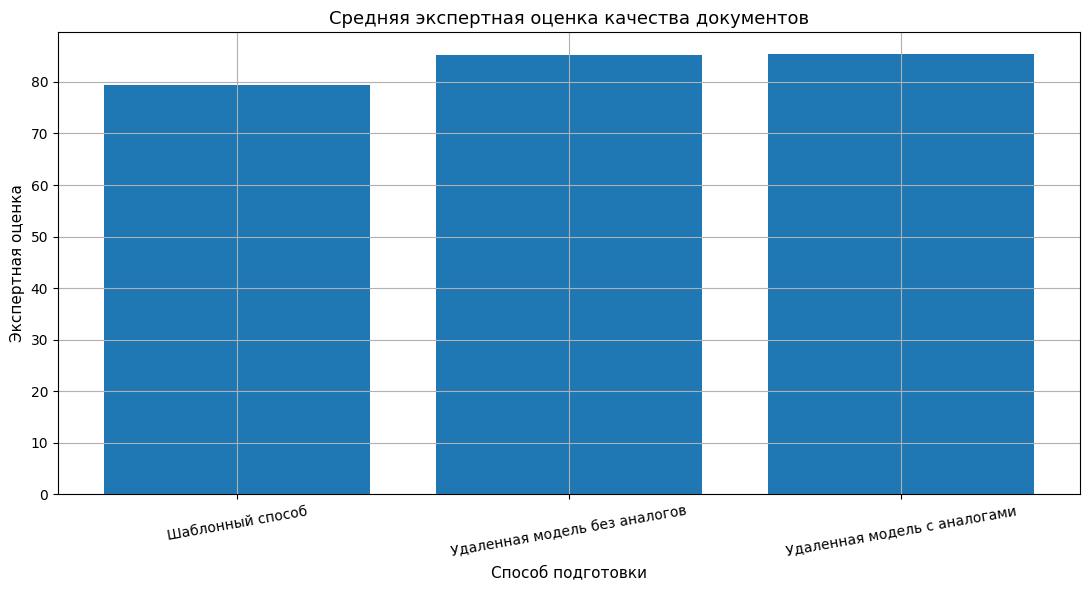

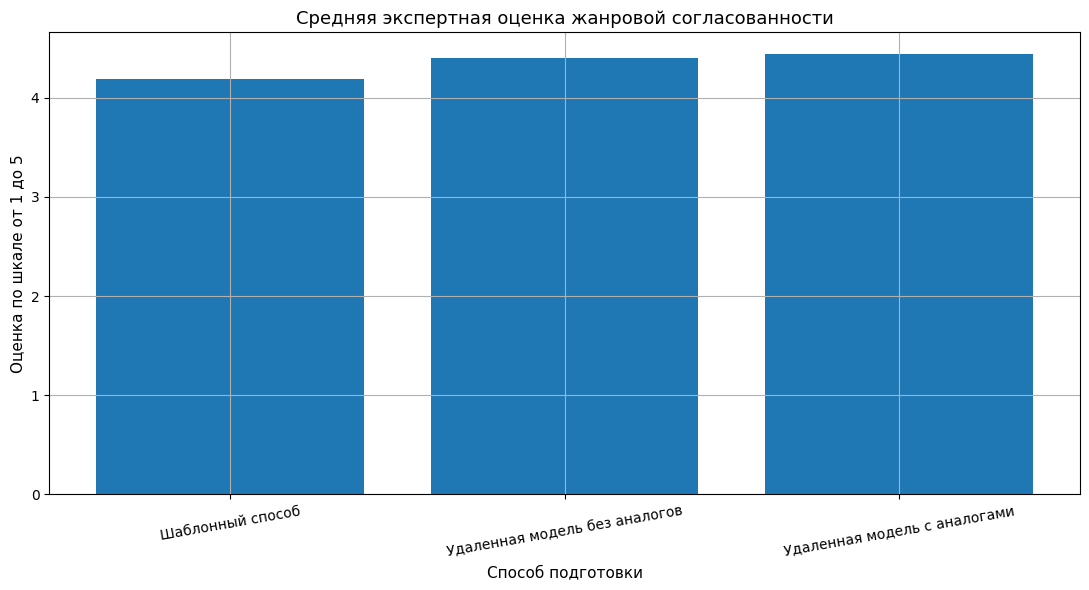

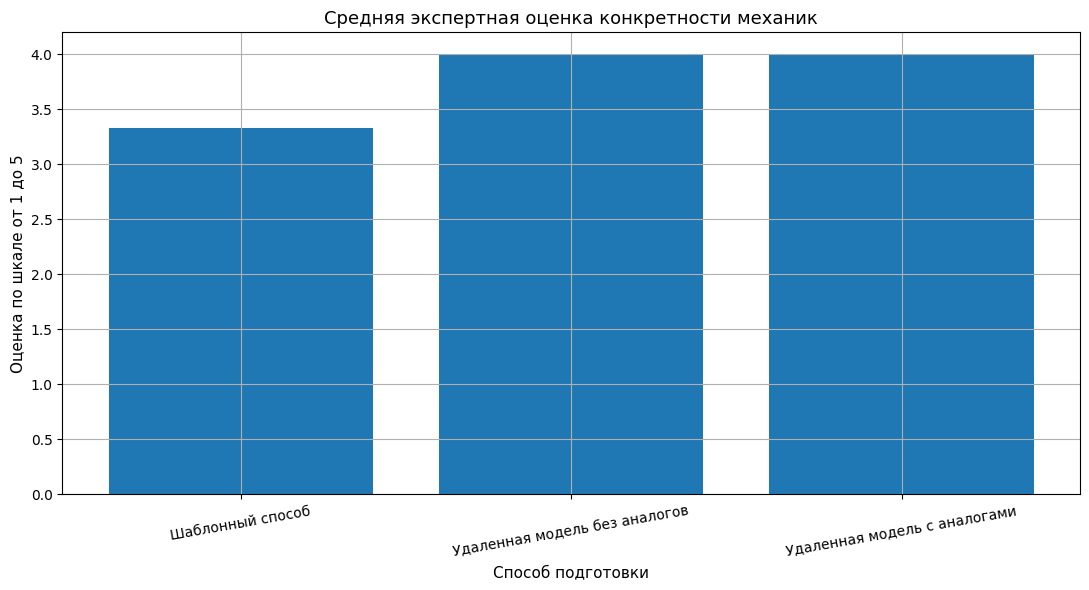

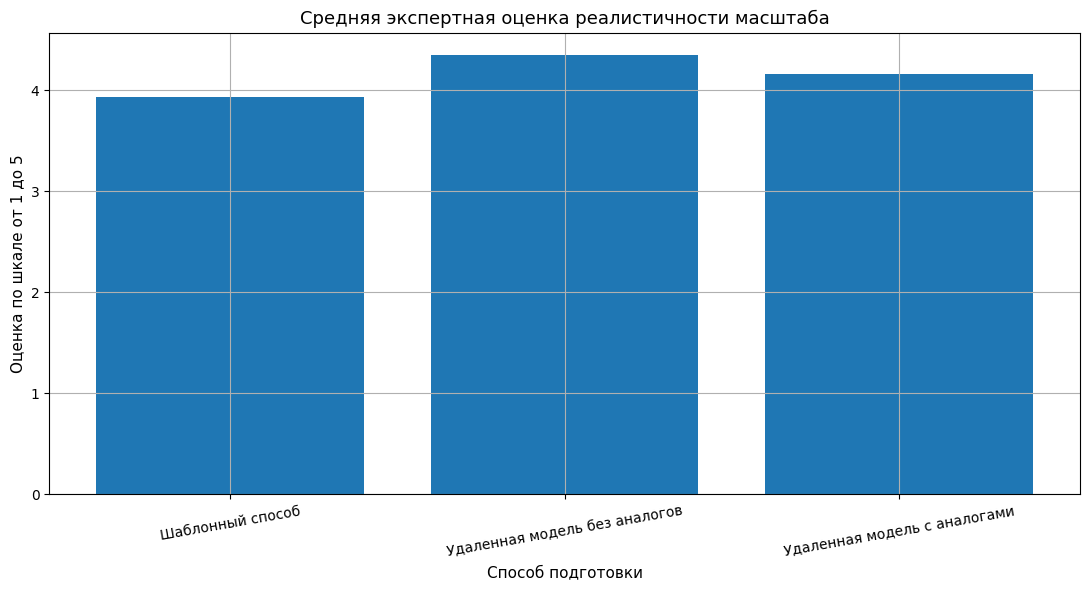

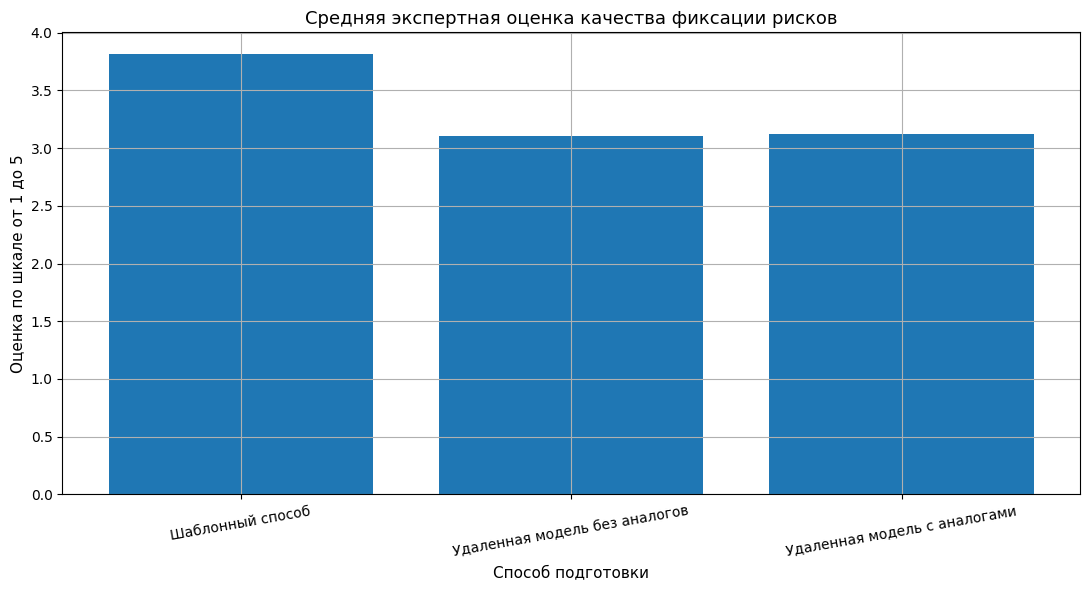

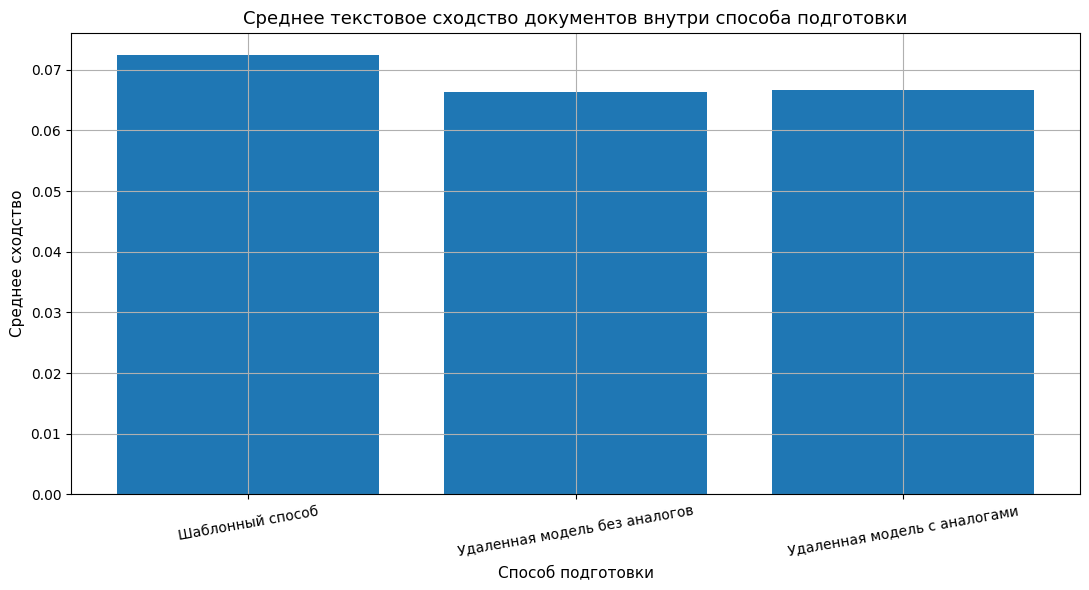

In [87]:
# Строим итоговые рисунки по качеству документов

import matplotlib.pyplot as plt

mode_order = ["template", "model_without_references", "model_with_references"]

plot_mode_summary = (
    mode_quality_summary.set_index("mode")
    .loc[mode_order]
    .reset_index()
)

# Рисунок 1. Средняя экспертная оценка
plt.figure(figsize=(11, 6))
plt.bar(plot_mode_summary["mode_label"], plot_mode_summary["mean_expert_total_score"])
plt.title("Средняя экспертная оценка качества документов")
plt.xlabel("Способ подготовки")
plt.ylabel("Экспертная оценка")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# Рисунок 2. Средняя оценка жанровой согласованности
plt.figure(figsize=(11, 6))
plt.bar(plot_mode_summary["mode_label"], plot_mode_summary["mean_genre_fit"])
plt.title("Средняя экспертная оценка жанровой согласованности")
plt.xlabel("Способ подготовки")
plt.ylabel("Оценка по шкале от 1 до 5")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# Рисунок 3. Средняя оценка конкретности механик
plt.figure(figsize=(11, 6))
plt.bar(plot_mode_summary["mode_label"], plot_mode_summary["mean_mechanics_specificity"])
plt.title("Средняя экспертная оценка конкретности механик")
plt.xlabel("Способ подготовки")
plt.ylabel("Оценка по шкале от 1 до 5")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# Рисунок 4. Средняя оценка реалистичности масштаба
plt.figure(figsize=(11, 6))
plt.bar(plot_mode_summary["mode_label"], plot_mode_summary["mean_scope_realism"])
plt.title("Средняя экспертная оценка реалистичности масштаба")
plt.xlabel("Способ подготовки")
plt.ylabel("Оценка по шкале от 1 до 5")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# Рисунок 5. Средняя оценка качества фиксации рисков
plt.figure(figsize=(11, 6))
plt.bar(plot_mode_summary["mode_label"], plot_mode_summary["mean_risk_quality"])
plt.title("Средняя экспертная оценка качества фиксации рисков")
plt.xlabel("Способ подготовки")
plt.ylabel("Оценка по шкале от 1 до 5")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# Рисунок 6. Среднее текстовое сходство документов внутри способа подготовки
similarity_plot = (
    template_similarity_summary.set_index("mode")
    .loc[mode_order]
    .reset_index()
)

plt.figure(figsize=(11, 6))
plt.bar(similarity_plot["mode_label"], similarity_plot["mean_pairwise_similarity"])
plt.title("Среднее текстовое сходство документов внутри способа подготовки")
plt.xlabel("Способ подготовки")
plt.ylabel("Среднее сходство")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

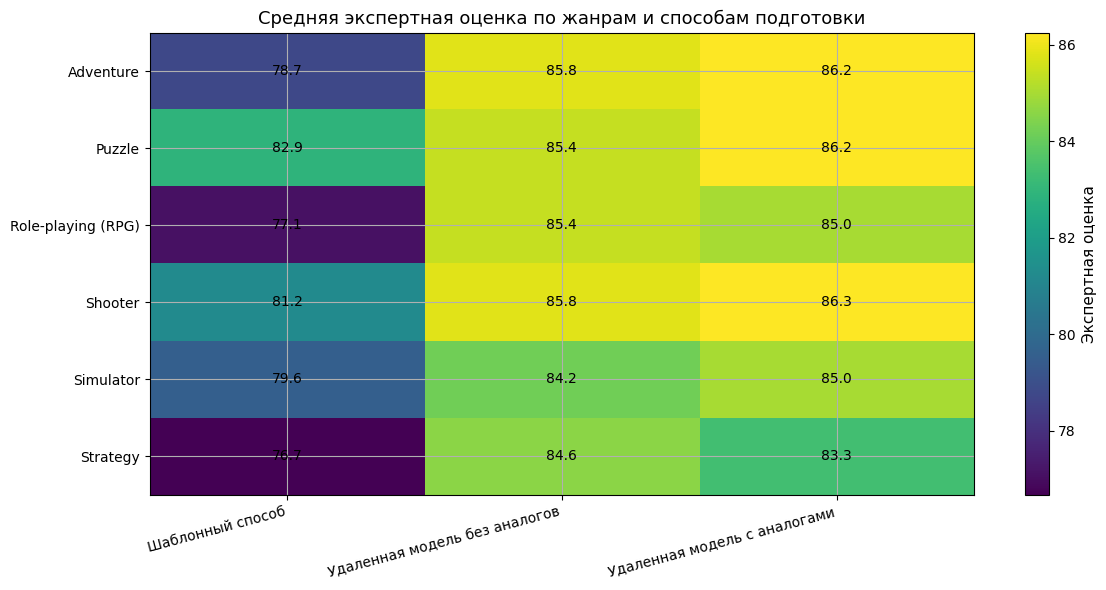

In [88]:
# Строим тепловую карту средней экспертной оценки по жанрам и способам подготовки

heatmap_table = (
    genre_mode_quality_summary.pivot(
        index="anchor_genre",
        columns="mode",
        values="mean_expert_total_score"
    )
    .reindex(columns=mode_order)
)

heatmap_table.columns = [MODE_LABELS[mode_name] for mode_name in heatmap_table.columns]

plt.figure(figsize=(12, 6))
image = plt.imshow(heatmap_table.values, aspect="auto")
plt.colorbar(image, label="Экспертная оценка")
plt.xticks(
    ticks=np.arange(len(heatmap_table.columns)),
    labels=heatmap_table.columns.tolist(),
    rotation=15,
    ha="right"
)
plt.yticks(
    ticks=np.arange(len(heatmap_table.index)),
    labels=heatmap_table.index.tolist()
)
plt.title("Средняя экспертная оценка по жанрам и способам подготовки")

for i in range(heatmap_table.shape[0]):
    for j in range(heatmap_table.shape[1]):
        value = heatmap_table.iloc[i, j]
        if pd.notna(value):
            plt.text(j, i, f"{value:.1f}", ha="center", va="center")

plt.tight_layout()
plt.show()

In [89]:
# Показываем документы с наибольшей и наименьшей экспертной оценкой

best_examples = (
    document_metrics.sort_values("expert_total_score", ascending=False)
    .head(6)
    .copy()
)

worst_examples = (
    document_metrics.sort_values("expert_total_score", ascending=True)
    .head(6)
    .copy()
)

print("Документы с наибольшей экспертной оценкой:")
display(
    best_examples[
        [
            "task_id",
            "mode",
            "source_game_name",
            "anchor_genre",
            "platform_family",
            "expert_total_score",
            "task_fit",
            "genre_fit",
            "mechanics_specificity",
            "scope_realism",
            "risk_quality",
            "coherence",
            "generated_text"
        ]
    ]
)

print("\nДокументы с наименьшей экспертной оценкой:")
display(
    worst_examples[
        [
            "task_id",
            "mode",
            "source_game_name",
            "anchor_genre",
            "platform_family",
            "expert_total_score",
            "task_fit",
            "genre_fit",
            "mechanics_specificity",
            "scope_realism",
            "risk_quality",
            "coherence",
            "generated_text"
        ]
    ]
)

Документы с наибольшей экспертной оценкой:


,task_id,mode,source_game_name,anchor_genre,platform_family,expert_total_score,task_fit,genre_fit,mechanics_specificity,scope_realism,risk_quality,coherence,generated_text
108,TASK_58531,model_with_references,Value 1500: O-chan no Oekaki Logic 3,Puzzle,PlayStation,93.33,5,5,4,5,4,5,"### Название проекта\nЛогическая палитра\n\n### Краткая концепция\n""Логическая палитра"" — это увлекательная логическая игра, в которой игроки решают головоломки, используя цветовые комбинации для ..."
96,TASK_122266,model_with_references,"Dragon Quest 1, 2, 3 Collection",Adventure,Nintendo,93.33,5,5,4,5,4,5,"### Название проекта\n""Легенды Драконьего Королевства""\n\n### Краткая концепция\nПроект представляет собой сборник первых трех игр серии Dragon Quest, адаптированных для платформы Nintendo Switch...."
15,TASK_145741,template,Mastho is Together,Puzzle,Xbox,90.00,5,4,4,5,4,5,"### Название проекта\nПроект Puzzle 5741\n\n### Краткая концепция\nПредлагается игра для семейства платформ Xbox, в которой центральный замысел строится вокруг следующего направления: In this prec..."
11,TASK_62332,template,Dinothawr,Puzzle,PC,90.00,5,4,4,5,4,5,"### Название проекта\nПроект Puzzle 2332\n\n### Краткая концепция\nПредлагается игра для семейства платформ PC, в которой центральный замысел строится вокруг следующего направления: In this blockp..."
55,TASK_28692,model_without_references,Mulaka,Adventure,Xbox,90.00,5,4,4,5,4,5,"### Название проекта \n""Пути Тараумара""\n\n### Краткая концепция \n""Пути Тараумара"" — это 3D приключенческая игра, погружающая игроков в захватывающие пейзажи северного Мексики. Основой сюжета с..."
45,TASK_45376,template,Super Robot Wars F Final,Strategy,PlayStation,90.00,5,4,4,5,4,5,"### Название проекта\nПроект Strategy 5376\n\n### Краткая концепция\nПредлагается игра для семейства платформ PlayStation, в которой центральный замысел строится вокруг следующего направления: The..."



Документы с наименьшей экспертной оценкой:


,task_id,mode,source_game_name,anchor_genre,platform_family,expert_total_score,task_fit,genre_fit,mechanics_specificity,scope_realism,risk_quality,coherence,generated_text
43,TASK_19280,template,GeneRally,Strategy,PC,56.67,2,2,3,4,3,3,"### Название проекта\nПроект Strategy 9280\n\n### Краткая концепция\nПредлагается игра для семейства платформ PC, в которой центральный замысел строится вокруг следующего направления: проект is a ..."
44,TASK_4187,template,Super Bubble Pop,Strategy,PlayStation,70.00,3,4,3,4,4,3,"### Название проекта\nПроект Strategy 4187\n\n### Краткая концепция\nПредлагается игра для семейства платформ PlayStation, в которой центральный замысел строится вокруг следующего направления: про..."
7,TASK_28692,template,Mulaka,Adventure,Xbox,73.33,4,4,3,4,4,3,"### Название проекта\nПроект Adventure 8692\n\n### Краткая концепция\nПредлагается игра для семейства платформ Xbox, в которой центральный замысел строится вокруг следующего направления: Dive into..."
5,TASK_218222,template,My Universe: My Baby Dragon,Adventure,PlayStation,73.33,4,4,3,3,4,4,"### Название проекта\nПроект Adventure 8222\n\n### Краткая концепция\nПредлагается игра для семейства платформ PlayStation, в которой центральный замысел строится вокруг следующего направления: Ra..."
20,TASK_183639,template,Fortnite: Chapter 3,Role-playing (RPG),PlayStation,73.33,4,4,3,4,3,4,"### Название проекта\nПроект Role-playing (RPG) 3639\n\n### Краткая концепция\nПредлагается игра для семейства платформ PlayStation, в которой центральный замысел строится вокруг следующего направ..."
16,TASK_187480,template,Dungeons of Shalnor,Role-playing (RPG),Nintendo,73.33,4,4,3,3,4,4,"### Название проекта\nПроект Role-playing (RPG) 7480\n\n### Краткая концепция\nПредлагается игра для семейства платформ Nintendo, в которой центральный замысел строится вокруг следующего направлен..."


In [91]:
# Сохраняем итоговые таблицы этапа

document_metrics.to_csv(
    "results/document_metrics_stage_7.csv",
    index=False
)

mode_quality_summary.to_csv(
    "results/mode_quality_summary_stage_7.csv",
    index=False
)

genre_mode_quality_summary.to_csv(
    "results/genre_mode_quality_summary_stage_7.csv",
    index=False
)

template_similarity_summary.to_csv(
    "results/template_similarity_summary_stage_7.csv",
    index=False
)

print("Таблица показателей качества сохранена в файл results/document_metrics_stage_7.csv")
print("Сводка по способам подготовки сохранена в файл results/mode_quality_summary_stage_7.csv")
print("Сводка по жанрам сохранена в файл results/genre_mode_quality_summary_stage_7.csv")
print("Сводка по внутригрупповому сходству сохранена в файл results/template_similarity_summary_stage_7.csv")
print(f"Число строк в таблице показателей качества: {document_metrics.shape[0]}")

Таблица показателей качества сохранена в файл results/document_metrics_stage_7.csv
Сводка по способам подготовки сохранена в файл results/mode_quality_summary_stage_7.csv
Сводка по жанрам сохранена в файл results/genre_mode_quality_summary_stage_7.csv
Сводка по внутригрупповому сходству сохранена в файл results/template_similarity_summary_stage_7.csv
Число строк в таблице показателей качества: 144


Оба варианта с удаленной языковой моделью заметно превосходят шаблонный способ по общей оценке, по жанровой согласованности и по конкретности механик. При этом вариант с игровыми аналогами показывает наилучший средний итоговый результат, хотя его преимущество над вариантом без аналогов пока выглядит небольшим и требует строгой статистической проверки.

Теперь недостаточно просто сказать, что один способ выглядит лучше другого. Необходимо показать, являются ли различия устойчивыми на уровне всей связанной выборки заданий, а также выяснить, в каких именно критериях преимущество действительно подтверждается. Поэтому следующий этап посвящен статистическому сопоставлению трех способов подготовки документов.

# 8. Статистическое сопоставление способов подготовки документов

На данном этапе выполняется строгая статистическая проверка различий между тремя способами подготовки краткого проектного документа игры. Поскольку для каждого тестового задания были получены три связанные версии документа, сравнение проводится между связанными результатами по одним и тем же игровым замыслам.

Научная значимость данного этапа состоит в том, что вывод о преимуществе того или иного способа подготовки документа переводится из описательного уровня в уровень статистически проверяемого результата. Для общей оценки и для отдельных критериев применяется критерий Фридмана (непараметрический критерий для нескольких связанных выборок), а для попарного сопоставления используются критерий Уилкоксона (непараметрический критерий для двух связанных выборок), поправка Холма на множественные сравнения и показатели практического превосходства по числу выигранных заданий.

In [92]:
# Загружаем итоговую таблицу показателей качества и подготавливаем связанные выборки

import sys
import subprocess
import importlib.util

# При необходимости устанавливаем библиотеку для статистических критериев
if importlib.util.find_spec("scipy") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scipy"])

import numpy as np
import pandas as pd

document_metrics = pd.read_csv("results/document_metrics_stage_7.csv")

mode_order = ["template", "model_without_references", "model_with_references"]

mode_labels = {
    "template": "Шаблонный способ",
    "model_without_references": "Удаленная модель без аналогов",
    "model_with_references": "Удаленная модель с аналогами"
}

# Числовые поля, которые будут использоваться в статистическом анализе
numeric_columns = [
    "expert_total_score",
    "task_fit",
    "genre_fit",
    "mechanics_specificity",
    "scope_realism",
    "risk_quality",
    "coherence",
    "text_length_chars",
    "platform_alignment_flag",
    "scope_clarity_flag",
    "risk_clarity_flag"
]

for column_name in numeric_columns:
    if column_name in document_metrics.columns:
        document_metrics[column_name] = pd.to_numeric(document_metrics[column_name], errors="coerce")

# Оставляем только строки с тремя способами подготовки для каждого задания
mode_count_by_task = (
    document_metrics.groupby("task_id", as_index=False)
    .agg(mode_count=("mode", "nunique"))
)

full_task_ids = mode_count_by_task.loc[mode_count_by_task["mode_count"] == 3, "task_id"].tolist()

document_metrics = document_metrics[document_metrics["task_id"].isin(full_task_ids)].copy()

print("Размер таблицы показателей после отбора полных связанных наблюдений:")
print(document_metrics.shape)

print("\nЧисло уникальных заданий с тремя способами подготовки:")
print(document_metrics["task_id"].nunique())

print("\nЧисло документов по способам подготовки:")
display(
    document_metrics.groupby("mode", as_index=False)
    .agg(documents_count=("task_id", "count"))
)

# Формируем широкую таблицу для общей экспертной оценки
wide_total = (
    document_metrics.pivot(index="task_id", columns="mode", values="expert_total_score")
    .reindex(columns=mode_order)
    .dropna()
)

print("\nРазмер широкой таблицы для общей экспертной оценки:")
print(wide_total.shape)

print("\nПервые строки широкой таблицы:")
display(wide_total.head(10))

Размер таблицы показателей после отбора полных связанных наблюдений:
(144, 40)

Число уникальных заданий с тремя способами подготовки:
48

Число документов по способам подготовки:


,mode,documents_count
0,model_with_references,48
1,model_without_references,48
2,template,48



Размер широкой таблицы для общей экспертной оценки:
(48, 3)

Первые строки широкой таблицы:


mode,template,model_without_references,model_with_references
task_id,,,
TASK_102623,83.33,86.67,86.67
TASK_107196,80.00,83.33,83.33
TASK_10966,76.67,83.33,83.33
TASK_112082,76.67,80.00,83.33
TASK_122266,80.00,86.67,93.33
TASK_136195,80.00,83.33,83.33
TASK_138332,80.00,86.67,86.67
TASK_144870,83.33,86.67,86.67
TASK_145741,90.00,86.67,83.33


In [93]:
# Выполняем статистическую проверку различий по общей экспертной оценке

from scipy.stats import friedmanchisquare, wilcoxon

def holm_correction(p_values):
    """
    Выполняем поправку Холма для набора значений значимости
    """
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    sorted_p = p_values[order]
    adjusted_sorted = np.empty_like(sorted_p)

    m = len(sorted_p)

    for i in range(m):
        adjusted_sorted[i] = (m - i) * sorted_p[i]

    # Обеспечиваем неубывающий характер скорректированных значений
    adjusted_sorted = np.maximum.accumulate(adjusted_sorted)
    adjusted_sorted = np.clip(adjusted_sorted, 0, 1)

    adjusted = np.empty_like(adjusted_sorted)
    adjusted[order] = adjusted_sorted

    return adjusted

def paired_superiority_stats(left_values, right_values):
    """
    Подсчитываем, сколько раз левая выборка лучше, хуже или равна правой
    """
    diff = np.asarray(left_values) - np.asarray(right_values)

    wins = int((diff > 0).sum())
    losses = int((diff < 0).sum())
    ties = int((diff == 0).sum())

    total = len(diff)

    if total == 0:
        win_share = np.nan
    else:
        win_share = wins / total * 100

    median_diff = float(np.median(diff))
    mean_diff = float(np.mean(diff))

    return wins, losses, ties, win_share, mean_diff, median_diff

# Общая проверка различий по трем связанным выборкам
friedman_stat, friedman_p = friedmanchisquare(
    wide_total["template"],
    wide_total["model_without_references"],
    wide_total["model_with_references"]
)

overall_total_summary = pd.DataFrame(
    {
        "Число связанных наблюдений": [wide_total.shape[0]],
        "Статистика критерия Фридмана": [round(float(friedman_stat), 4)],
        "Значение значимости": [round(float(friedman_p), 6)]
    }
)

print("Итог общей проверки различий по экспертной оценке:")
display(overall_total_summary)

# Попарные сравнения по критерию Уилкоксона
pair_definitions = [
    ("template", "model_without_references"),
    ("template", "model_with_references"),
    ("model_without_references", "model_with_references")
]

pairwise_rows = []

raw_p_values = []

for left_mode, right_mode in pair_definitions:
    left_values = wide_total[left_mode].values
    right_values = wide_total[right_mode].values

    try:
        wilcoxon_stat, wilcoxon_p = wilcoxon(left_values, right_values, zero_method="wilcox")
    except Exception:
        wilcoxon_stat, wilcoxon_p = np.nan, np.nan

    wins, losses, ties, win_share, mean_diff, median_diff = paired_superiority_stats(
        left_values=right_values,
        right_values=left_values
    )

    raw_p_values.append(wilcoxon_p)

    pairwise_rows.append(
        {
            "Сравнение": f"{mode_labels[right_mode]} лучше, чем {mode_labels[left_mode]}",
            "Левый способ": mode_labels[left_mode],
            "Правый способ": mode_labels[right_mode],
            "Статистика критерия Уилкоксона": wilcoxon_stat,
            "Исходное значение значимости": wilcoxon_p,
            "Число заданий, где правый способ лучше": wins,
            "Число заданий, где правый способ хуже": losses,
            "Число равных случаев": ties,
            "Доля выигранных заданий, процентов": round(win_share, 2),
            "Среднее превосходство по баллу": round(mean_diff, 3),
            "Медианное превосходство по баллу": round(median_diff, 3)
        }
    )

pairwise_total_summary = pd.DataFrame(pairwise_rows)

# Добавляем поправку Холма
valid_p_values = [value for value in raw_p_values if pd.notna(value)]

if len(valid_p_values) > 0:
    adjusted_values = holm_correction(valid_p_values)

    adjusted_iter = iter(adjusted_values)
    adjusted_column = []

    for value in raw_p_values:
        if pd.notna(value):
            adjusted_column.append(round(float(next(adjusted_iter)), 6))
        else:
            adjusted_column.append(np.nan)

    pairwise_total_summary["Скорректированное значение значимости"] = adjusted_column
else:
    pairwise_total_summary["Скорректированное значение значимости"] = np.nan

print("\nПопарные сравнения по общей экспертной оценке:")
display(pairwise_total_summary)

Итог общей проверки различий по экспертной оценке:


,Число связанных наблюдений,Статистика критерия Фридмана,Значение значимости
0,48,64.293,0.0



Попарные сравнения по общей экспертной оценке:


,Сравнение,Левый способ,Правый способ,Статистика критерия Уилкоксона,Исходное значение значимости,"Число заданий, где правый способ лучше","Число заданий, где правый способ хуже",Число равных случаев,"Доля выигранных заданий, процентов",Среднее превосходство по баллу,Медианное превосходство по баллу,Скорректированное значение значимости
0,"Удаленная модель без аналогов лучше, чем Шаблонный способ",Шаблонный способ,Удаленная модель без аналогов,46.0,3.429166e-08,44,3,1,91.67,5.834,5.000,0.000000
1,"Удаленная модель с аналогами лучше, чем Шаблонный способ",Шаблонный способ,Удаленная модель с аналогами,40.5,2.559287e-08,44,3,1,91.67,5.973,6.665,0.000000
2,"Удаленная модель с аналогами лучше, чем Удаленная модель без аналогов",Удаленная модель без аналогов,Удаленная модель с аналогами,57.0,5.607871e-01,9,7,32,18.75,0.139,0.000,0.560787


In [94]:
# Выполняем статистическую проверку по отдельным критериям экспертной оценки

criteria_columns = [
    "task_fit",
    "genre_fit",
    "mechanics_specificity",
    "scope_realism",
    "risk_quality",
    "coherence"
]

criteria_name_map = {
    "task_fit": "Соответствие заданию",
    "genre_fit": "Жанровая согласованность",
    "mechanics_specificity": "Конкретность механик",
    "scope_realism": "Реалистичность масштаба",
    "risk_quality": "Качество фиксации рисков",
    "coherence": "Связность документа"
}

friedman_rows = []
pairwise_rows = []

for criterion_name in criteria_columns:
    wide_table = (
        document_metrics.pivot(index="task_id", columns="mode", values=criterion_name)
        .reindex(columns=mode_order)
        .dropna()
    )

    friedman_stat, friedman_p = friedmanchisquare(
        wide_table["template"],
        wide_table["model_without_references"],
        wide_table["model_with_references"]
    )

    friedman_rows.append(
        {
            "Критерий": criteria_name_map[criterion_name],
            "Число связанных наблюдений": wide_table.shape[0],
            "Статистика критерия Фридмана": round(float(friedman_stat), 4),
            "Значение значимости": round(float(friedman_p), 6)
        }
    )

    raw_p_values = []
    current_rows = []

    for left_mode, right_mode in pair_definitions:
        left_values = wide_table[left_mode].values
        right_values = wide_table[right_mode].values

        try:
            wilcoxon_stat, wilcoxon_p = wilcoxon(left_values, right_values, zero_method="wilcox")
        except Exception:
            wilcoxon_stat, wilcoxon_p = np.nan, np.nan

        wins, losses, ties, win_share, mean_diff, median_diff = paired_superiority_stats(
            left_values=right_values,
            right_values=left_values
        )

        raw_p_values.append(wilcoxon_p)

        current_rows.append(
            {
                "Критерий": criteria_name_map[criterion_name],
                "Сравнение": f"{mode_labels[right_mode]} лучше, чем {mode_labels[left_mode]}",
                "Правый способ": mode_labels[right_mode],
                "Левый способ": mode_labels[left_mode],
                "Статистика критерия Уилкоксона": wilcoxon_stat,
                "Исходное значение значимости": wilcoxon_p,
                "Доля выигранных заданий, процентов": round(win_share, 2),
                "Среднее превосходство": round(mean_diff, 3),
                "Медианное превосходство": round(median_diff, 3)
            }
        )

    valid_p_values = [value for value in raw_p_values if pd.notna(value)]

    if len(valid_p_values) > 0:
        adjusted_values = holm_correction(valid_p_values)
        adjusted_iter = iter(adjusted_values)

        for row_dict, raw_value in zip(current_rows, raw_p_values):
            if pd.notna(raw_value):
                row_dict["Скорректированное значение значимости"] = round(float(next(adjusted_iter)), 6)
            else:
                row_dict["Скорректированное значение значимости"] = np.nan

    pairwise_rows.extend(current_rows)

friedman_criteria_summary = pd.DataFrame(friedman_rows)
pairwise_criteria_summary = pd.DataFrame(pairwise_rows)

print("Проверка различий по отдельным критериям:")
display(friedman_criteria_summary)

print("\nПопарные сравнения по отдельным критериям:")
display(pairwise_criteria_summary.head(18))

Проверка различий по отдельным критериям:


,Критерий,Число связанных наблюдений,Статистика критерия Фридмана,Значение значимости
0,Соответствие заданию,48,82.7634,0.000000
1,Жанровая согласованность,48,9.3973,0.009108
2,Конкретность механик,48,64.0000,0.000000
3,Реалистичность масштаба,48,18.5319,0.000095
4,Качество фиксации рисков,48,57.5897,0.000000
5,Связность документа,48,9.9059,0.007063



Попарные сравнения по отдельным критериям:


,Критерий,Сравнение,Правый способ,Левый способ,Статистика критерия Уилкоксона,Исходное значение значимости,"Доля выигранных заданий, процентов",Среднее превосходство,Медианное превосходство,Скорректированное значение значимости
0,Соответствие заданию,"Удаленная модель без аналогов лучше, чем Шаблонный способ",Удаленная модель без аналогов,Шаблонный способ,0.0,1.454609e-10,87.50,0.917,1.0,0.000000
1,Соответствие заданию,"Удаленная модель с аналогами лучше, чем Шаблонный способ",Удаленная модель с аналогами,Шаблонный способ,0.0,1.337652e-10,89.58,0.938,1.0,0.000000
2,Соответствие заданию,"Удаленная модель с аналогами лучше, чем Удаленная модель без аналогов",Удаленная модель с аналогами,Удаленная модель без аналогов,2.0,5.637029e-01,4.17,0.021,0.0,0.563703
3,Жанровая согласованность,"Удаленная модель без аналогов лучше, чем Шаблонный способ",Удаленная модель без аналогов,Шаблонный способ,63.0,4.122683e-02,31.25,0.208,0.0,0.082454
4,Жанровая согласованность,"Удаленная модель с аналогами лучше, чем Шаблонный способ",Удаленная модель с аналогами,Шаблонный способ,42.0,7.290358e-03,33.33,0.250,0.0,0.021871
5,Жанровая согласованность,"Удаленная модель с аналогами лучше, чем Удаленная модель без аналогов",Удаленная модель с аналогами,Удаленная модель без аналогов,13.5,4.795001e-01,10.42,0.042,0.0,0.479500
6,Конкретность механик,"Удаленная модель без аналогов лучше, чем Шаблонный способ",Удаленная модель без аналогов,Шаблонный способ,0.0,1.541726e-08,66.67,0.667,1.0,0.000000
7,Конкретность механик,"Удаленная модель с аналогами лучше, чем Шаблонный способ",Удаленная модель с аналогами,Шаблонный способ,0.0,1.541726e-08,66.67,0.667,1.0,0.000000
8,Конкретность механик,"Удаленная модель с аналогами лучше, чем Удаленная модель без аналогов",Удаленная модель с аналогами,Удаленная модель без аналогов,0.0,NaN,0.00,0.000,0.0,NaN
9,Реалистичность масштаба,"Удаленная модель без аналогов лучше, чем Шаблонный способ",Удаленная модель без аналогов,Шаблонный способ,58.0,1.570523e-04,50.00,0.417,0.5,0.000471


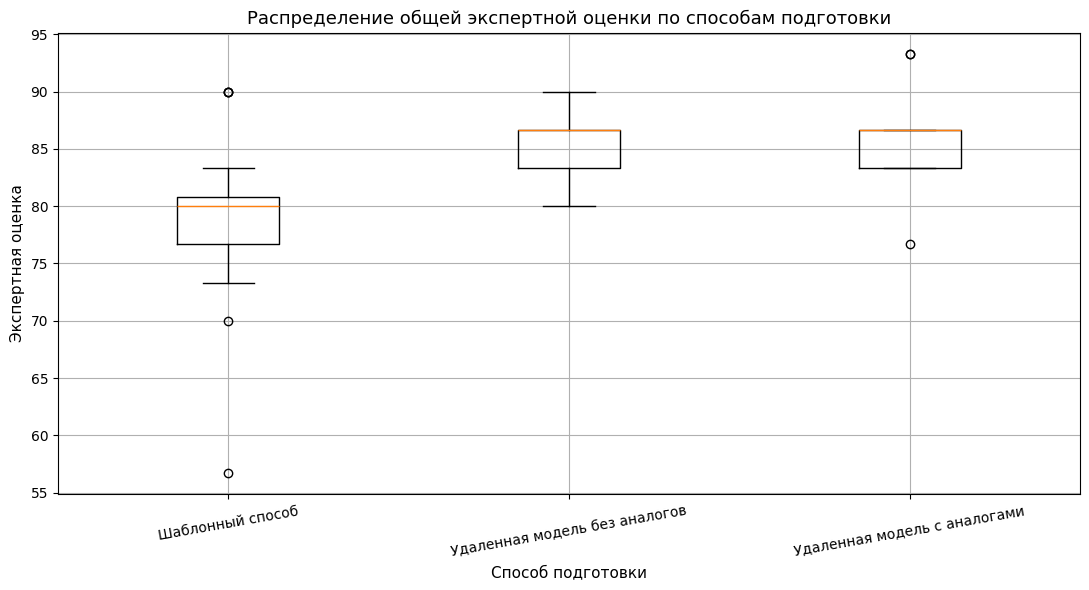

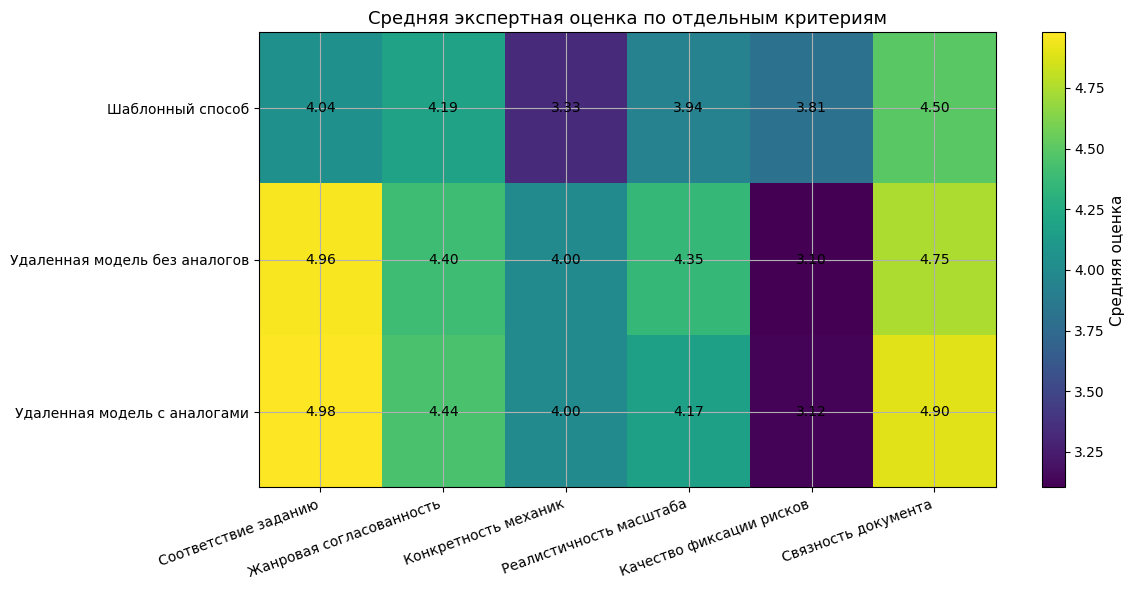

In [95]:
# Строим основные рисунки по итогам статистического сопоставления

import matplotlib.pyplot as plt

plot_mode_summary = (
    document_metrics.groupby("mode", as_index=False)
    .agg(mean_expert_total_score=("expert_total_score", "mean"))
)

plot_mode_summary["mode"] = pd.Categorical(plot_mode_summary["mode"], categories=mode_order, ordered=True)
plot_mode_summary = plot_mode_summary.sort_values("mode").reset_index(drop=True)
plot_mode_summary["mode_label"] = plot_mode_summary["mode"].map(mode_labels)

# Рисунок 1. Распределение общей экспертной оценки по способам подготовки
boxplot_data = [
    document_metrics.loc[document_metrics["mode"] == mode_name, "expert_total_score"].dropna()
    for mode_name in mode_order
]

plt.figure(figsize=(11, 6))
plt.boxplot(boxplot_data, tick_labels=[mode_labels[mode_name] for mode_name in mode_order], vert=True)
plt.title("Распределение общей экспертной оценки по способам подготовки")
plt.xlabel("Способ подготовки")
plt.ylabel("Экспертная оценка")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# Рисунок 2. Средняя экспертная оценка по отдельным критериям
criterion_mean_table = (
    document_metrics.groupby("mode", as_index=True)[criteria_columns]
    .mean()
    .reindex(mode_order)
)

criterion_mean_table = criterion_mean_table.rename(index=mode_labels)
criterion_mean_table = criterion_mean_table.rename(columns=criteria_name_map)

plt.figure(figsize=(12, 6))
image = plt.imshow(criterion_mean_table.values, aspect="auto")
plt.colorbar(image, label="Средняя оценка")
plt.xticks(
    ticks=np.arange(len(criterion_mean_table.columns)),
    labels=criterion_mean_table.columns.tolist(),
    rotation=20,
    ha="right"
)
plt.yticks(
    ticks=np.arange(len(criterion_mean_table.index)),
    labels=criterion_mean_table.index.tolist()
)
plt.title("Средняя экспертная оценка по отдельным критериям")

for i in range(criterion_mean_table.shape[0]):
    for j in range(criterion_mean_table.shape[1]):
        value = criterion_mean_table.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

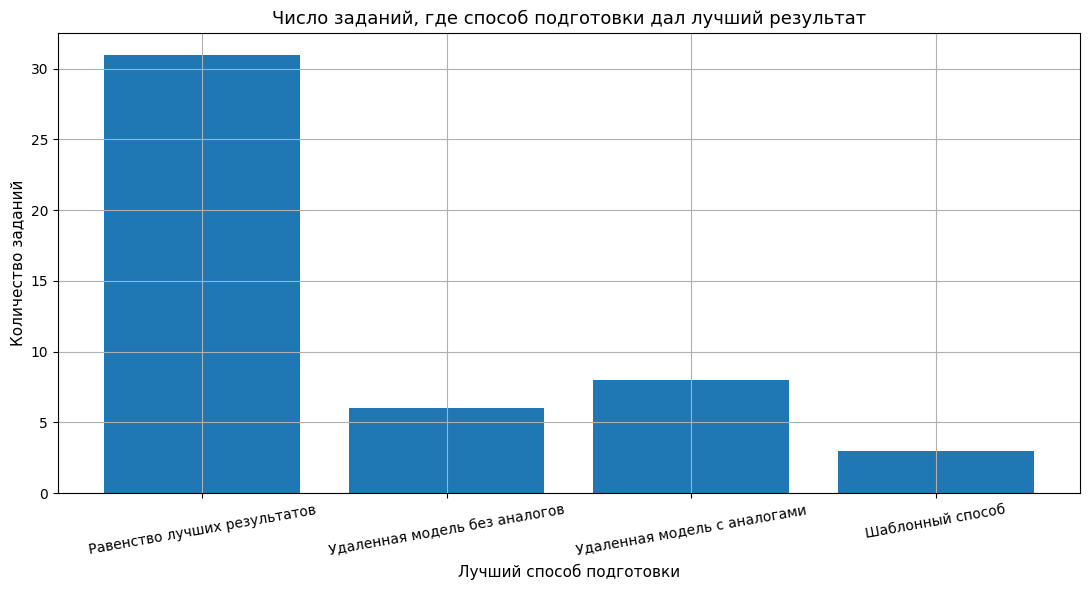

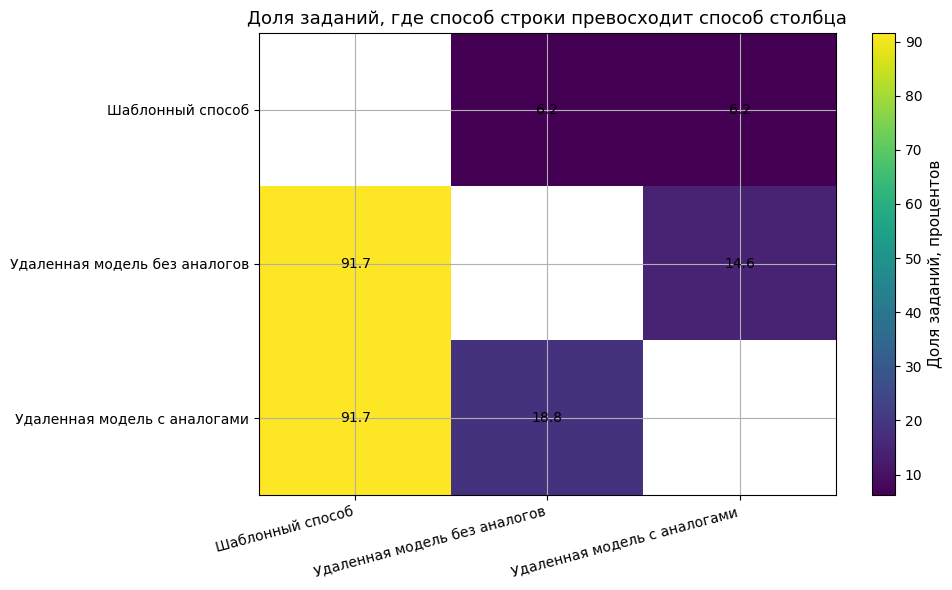

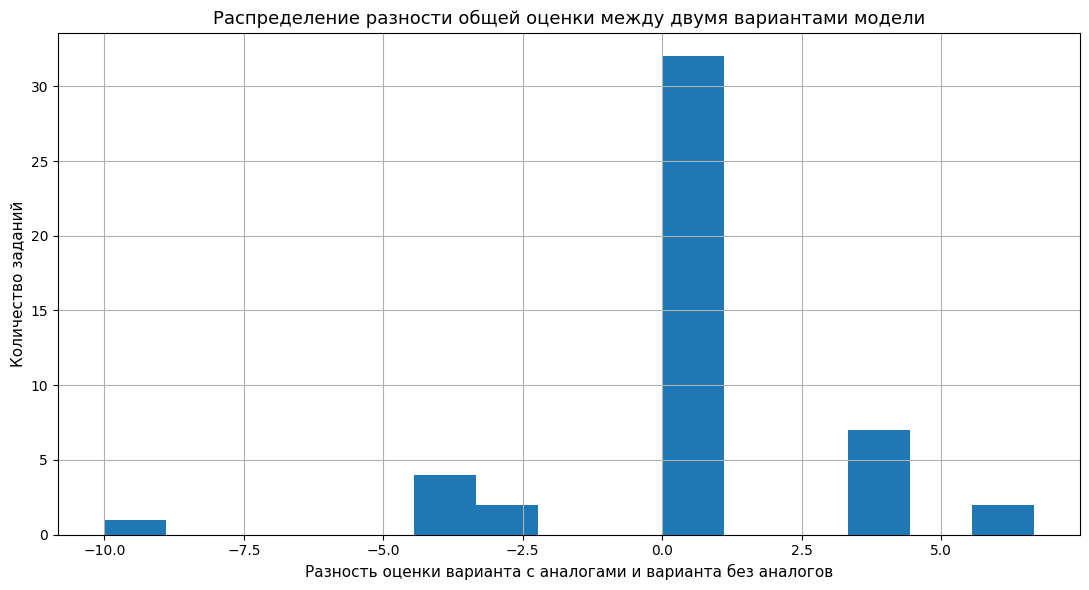

In [96]:
# Строим дополнительные рисунки по превосходству способов подготовки

# Определяем лучший способ для каждого задания по общей экспертной оценке
wide_total_named = wide_total.copy()
wide_total_named.columns = [mode_labels[column_name] for column_name in wide_total_named.columns]

best_mode_rows = []

for task_id, row in wide_total_named.iterrows():
    best_value = row.max()
    best_modes = row.index[row == best_value].tolist()

    if len(best_modes) == 1:
        best_mode = best_modes[0]
    else:
        best_mode = "Равенство лучших результатов"

    best_mode_rows.append(
        {
            "task_id": task_id,
            "best_mode": best_mode
        }
    )

best_mode_summary = (
    pd.DataFrame(best_mode_rows)
    .groupby("best_mode", as_index=False)
    .agg(tasks_count=("task_id", "count"))
)

# Рисунок 3. Число заданий, где способ подготовки оказался лучшим
plt.figure(figsize=(11, 6))
plt.bar(best_mode_summary["best_mode"], best_mode_summary["tasks_count"])
plt.title("Число заданий, где способ подготовки дал лучший результат")
plt.xlabel("Лучший способ подготовки")
plt.ylabel("Количество заданий")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# Строим матрицу превосходства:
# доля заданий, где способ строки лучше способа столбца
superiority_matrix = np.zeros((len(mode_order), len(mode_order)))

for i, left_mode in enumerate(mode_order):
    for j, right_mode in enumerate(mode_order):
        if i == j:
            superiority_matrix[i, j] = np.nan
            continue

        left_values = wide_total[left_mode].values
        right_values = wide_total[right_mode].values

        superiority_matrix[i, j] = (left_values > right_values).mean() * 100

# Рисунок 4. Доля заданий, где способ строки превосходит способ столбца
plt.figure(figsize=(10, 6))
image = plt.imshow(superiority_matrix, aspect="auto")
plt.colorbar(image, label="Доля заданий, процентов")
plt.xticks(
    ticks=np.arange(len(mode_order)),
    labels=[mode_labels[mode_name] for mode_name in mode_order],
    rotation=15,
    ha="right"
)
plt.yticks(
    ticks=np.arange(len(mode_order)),
    labels=[mode_labels[mode_name] for mode_name in mode_order]
)
plt.title("Доля заданий, где способ строки превосходит способ столбца")

for i in range(superiority_matrix.shape[0]):
    for j in range(superiority_matrix.shape[1]):
        value = superiority_matrix[i, j]
        if not np.isnan(value):
            plt.text(j, i, f"{value:.1f}", ha="center", va="center")

plt.tight_layout()
plt.show()

# Рисунок 5. Распределение разности общей оценки
# между вариантом с аналогами и вариантом без аналогов
difference_refs_vs_no_refs = (
    wide_total["model_with_references"] - wide_total["model_without_references"]
)

plt.figure(figsize=(11, 6))
plt.hist(difference_refs_vs_no_refs, bins=15)
plt.title("Распределение разности общей оценки между двумя вариантами модели")
plt.xlabel("Разность оценки варианта с аналогами и варианта без аналогов")
plt.ylabel("Количество заданий")
plt.tight_layout()
plt.show()

In [97]:
# Сохраняем итоговые таблицы этапа

overall_total_summary.to_csv(
    "results/overall_total_summary_stage_8.csv",
    index=False
)

pairwise_total_summary.to_csv(
    "results/pairwise_total_summary_stage_8.csv",
    index=False
)

friedman_criteria_summary.to_csv(
    "results/friedman_criteria_summary_stage_8.csv",
    index=False
)

pairwise_criteria_summary.to_csv(
    "results/pairwise_criteria_summary_stage_8.csv",
    index=False
)

best_mode_summary.to_csv(
    "results/best_mode_summary_stage_8.csv",
    index=False
)

print("Итог общей проверки сохранен в файл results/overall_total_summary_stage_8.csv")
print("Попарные сравнения по общей оценке сохранены в файл results/pairwise_total_summary_stage_8.csv")
print("Проверка по отдельным критериям сохранена в файл results/friedman_criteria_summary_stage_8.csv")
print("Попарные сравнения по отдельным критериям сохранены в файл results/pairwise_criteria_summary_stage_8.csv")
print("Сводка по лучшим результатам сохранена в файл results/best_mode_summary_stage_8.csv")
print(f"Число строк в таблице попарных сравнений по критериям: {pairwise_criteria_summary.shape[0]}")

Итог общей проверки сохранен в файл results/overall_total_summary_stage_8.csv
Попарные сравнения по общей оценке сохранены в файл results/pairwise_total_summary_stage_8.csv
Проверка по отдельным критериям сохранена в файл results/friedman_criteria_summary_stage_8.csv
Попарные сравнения по отдельным критериям сохранены в файл results/pairwise_criteria_summary_stage_8.csv
Сводка по лучшим результатам сохранена в файл results/best_mode_summary_stage_8.csv
Число строк в таблице попарных сравнений по критериям: 18


Общая экспертная оценка различается статистически значимо, причем оба варианта удаленной модели уверенно превосходят шаблонный способ. Преимущество подтверждено не отдельными удачными примерами, а на всей связанной выборке из сорока восьми заданий.

Не менее важна и более тонкая картина по отдельным критериям. Преимущество вариантов с удаленной моделью особенно хорошо подтверждается по соответствию заданию, конкретности механик и, частично, по реалистичности масштаба. Вариант с игровыми аналогами показывает лучший средний итоговый результат, но его превосходство над вариантом без аналогов в целом пока невелико и не подтверждается как устойчивое по общей оценке. Теперь можно показать, что добавление игровых аналогов полезно не всегда одинаково, а зависит от типа задания и жанрового контекста.

# 9. Итоговая интерпретация результатов и подготовка материалов для выпускной работы

На данном этапе результаты эксперимента сводятся в компактную и наглядную форму, пригодную для включения в работу. Основная задача состоит в том, чтобы сформировать итоговую картину исследования: где именно удаленная модель дала устойчивый выигрыш по сравнению с шаблонным способом, в каких случаях игровые аналоги улучшали результат, а в каких случаях заметного выигрыша не наблюдалось.

Научная значимость данного этапа состоит в том, что он завершает исследование интерпретацией статистически проверенных результатов. Здесь формируются итоговые таблицы и рисунки, которые напрямую отвечают на гипотезу работы и позволяют затем написать аналитический подраздел с опорой на количественные данные.

In [98]:
# Загружаем итоговые результаты предыдущих этапов
# и подготавливаем данные для заключительной интерпретации

import numpy as np
import pandas as pd

document_metrics = pd.read_csv("results/document_metrics_stage_7.csv")
pairwise_total_summary = pd.read_csv("results/pairwise_total_summary_stage_8.csv")
pairwise_criteria_summary = pd.read_csv("results/pairwise_criteria_summary_stage_8.csv")
overall_total_summary = pd.read_csv("results/overall_total_summary_stage_8.csv")
friedman_criteria_summary = pd.read_csv("results/friedman_criteria_summary_stage_8.csv")

mode_order = ["template", "model_without_references", "model_with_references"]

mode_labels = {
    "template": "Шаблонный способ",
    "model_without_references": "Удаленная модель без аналогов",
    "model_with_references": "Удаленная модель с аналогами"
}

# Широкая таблица по общей экспертной оценке
wide_total = (
    document_metrics.pivot(index="task_id", columns="mode", values="expert_total_score")
    .reindex(columns=mode_order)
    .dropna()
)

# Добавляем основные признаки задания
task_metadata = (
    document_metrics[
        [
            "task_id",
            "anchor_genre",
            "platform_family",
            "source_game_name"
        ]
    ]
    .drop_duplicates(subset=["task_id"])
    .copy()
)

print("Размер итоговой широкой таблицы по общей экспертной оценке:")
print(wide_total.shape)

print("\nПервые строки таблицы общей оценки:")
display(wide_total.head(10))

print("\nОсновной итог статистической проверки:")
display(overall_total_summary)

print("\nПервые строки таблицы заданий:")
display(task_metadata.head(10))

Размер итоговой широкой таблицы по общей экспертной оценке:
(48, 3)

Первые строки таблицы общей оценки:


mode,template,model_without_references,model_with_references
task_id,,,
TASK_102623,83.33,86.67,86.67
TASK_107196,80.00,83.33,83.33
TASK_10966,76.67,83.33,83.33
TASK_112082,76.67,80.00,83.33
TASK_122266,80.00,86.67,93.33
TASK_136195,80.00,83.33,83.33
TASK_138332,80.00,86.67,86.67
TASK_144870,83.33,86.67,86.67
TASK_145741,90.00,86.67,83.33



Основной итог статистической проверки:


,Число связанных наблюдений,Статистика критерия Фридмана,Значение значимости
0,48,64.293,0.0



Первые строки таблицы заданий:


,task_id,anchor_genre,platform_family,source_game_name
0,TASK_122266,Adventure,Nintendo,"Dragon Quest 1, 2, 3 Collection"
1,TASK_102623,Adventure,Nintendo,Escape Game: Aloha
2,TASK_26820,Adventure,PC,Blasphemous
3,TASK_248325,Adventure,PC,Just Keep Running
4,TASK_136195,Adventure,PlayStation,Kandagawa Jet Girls: Racing Hearts Edition
5,TASK_218222,Adventure,PlayStation,My Universe: My Baby Dragon
6,TASK_172625,Adventure,Xbox,LEGO Dimensions: Excalibur Batman Fun Pack
7,TASK_28692,Adventure,Xbox,Mulaka
8,TASK_152428,Puzzle,Nintendo,Sweet Sugar Candy
9,TASK_3667,Puzzle,Nintendo,Shrek


In [99]:
# Рассчитываем разности между способами подготовки
# и строим таблицы для итоговой интерпретации

comparison_table = wide_total.reset_index().merge(
    task_metadata,
    on="task_id",
    how="left"
)

comparison_table["delta_model_vs_template"] = (
    comparison_table["model_without_references"] - comparison_table["template"]
)

comparison_table["delta_model_refs_vs_template"] = (
    comparison_table["model_with_references"] - comparison_table["template"]
)

comparison_table["delta_refs_vs_no_refs"] = (
    comparison_table["model_with_references"] - comparison_table["model_without_references"]
)

# Функция смысловой классификации влияния игровых аналогов
def classify_reference_effect(delta_value):
    if delta_value >= 3.0:
        return "Игровые аналоги заметно улучшили результат"
    if delta_value >= 1.0:
        return "Игровые аналоги умеренно улучшили результат"
    if delta_value <= -3.0:
        return "Игровые аналоги заметно ухудшили результат"
    if delta_value <= -1.0:
        return "Игровые аналоги умеренно ухудшили результат"
    return "Игровые аналоги не дали выраженного изменения"

comparison_table["reference_effect_group"] = comparison_table["delta_refs_vs_no_refs"].apply(
    classify_reference_effect
)

# Сводка по влиянию игровых аналогов
reference_effect_summary = (
    comparison_table.groupby("reference_effect_group", as_index=False)
    .agg(tasks_count=("task_id", "count"))
    .sort_values("tasks_count", ascending=False)
    .reset_index(drop=True)
)

# Сводка по жанрам
genre_delta_summary = (
    comparison_table.groupby("anchor_genre", as_index=False)
    .agg(
        mean_delta_model_vs_template=("delta_model_vs_template", "mean"),
        mean_delta_model_refs_vs_template=("delta_model_refs_vs_template", "mean"),
        mean_delta_refs_vs_no_refs=("delta_refs_vs_no_refs", "mean"),
        median_delta_refs_vs_no_refs=("delta_refs_vs_no_refs", "median")
    )
    .sort_values("mean_delta_refs_vs_no_refs", ascending=False)
    .reset_index(drop=True)
)

# Сводка по семействам платформ
platform_delta_summary = (
    comparison_table.groupby("platform_family", as_index=False)
    .agg(
        mean_delta_model_vs_template=("delta_model_vs_template", "mean"),
        mean_delta_model_refs_vs_template=("delta_model_refs_vs_template", "mean"),
        mean_delta_refs_vs_no_refs=("delta_refs_vs_no_refs", "mean"),
        median_delta_refs_vs_no_refs=("delta_refs_vs_no_refs", "median")
    )
    .sort_values("mean_delta_refs_vs_no_refs", ascending=False)
    .reset_index(drop=True)
)

print("Сводка по влиянию игровых аналогов:")
display(reference_effect_summary)

print("\nСводка по жанрам:")
display(genre_delta_summary)

print("\nСводка по семействам платформ:")
display(platform_delta_summary)

Сводка по влиянию игровых аналогов:


,reference_effect_group,tasks_count
0,Игровые аналоги не дали выраженного изменения,32
1,Игровые аналоги заметно улучшили результат,9
2,Игровые аналоги заметно ухудшили результат,7



Сводка по жанрам:


,anchor_genre,mean_delta_model_vs_template,mean_delta_model_refs_vs_template,mean_delta_refs_vs_no_refs,median_delta_refs_vs_no_refs
0,Simulator,4.58250,5.41625,0.83375,0.0
1,Puzzle,2.50250,3.33500,0.83250,0.0
2,Shooter,4.58625,5.00375,0.41750,0.0
3,Adventure,7.08500,7.50125,0.41625,0.0
4,Role-playing (RPG),8.33375,7.91625,-0.41750,0.0
5,Strategy,7.91500,6.66500,-1.25000,0.0



Сводка по семействам платформ:


,platform_family,mean_delta_model_vs_template,mean_delta_model_refs_vs_template,mean_delta_refs_vs_no_refs,median_delta_refs_vs_no_refs
0,Nintendo,4.166667,5.277500,1.110833,0.0
1,PlayStation,5.001667,5.835000,0.833333,0.0
2,Xbox,6.667500,6.112500,-0.555000,0.0
3,PC,7.500833,6.666667,-0.834167,0.0


In [100]:
# Выделяем наиболее показательные задания:
# где игровые аналоги помогли сильнее всего,
# где почти не изменили результат,
# и где ухудшили итог

best_reference_gain = (
    comparison_table.sort_values("delta_refs_vs_no_refs", ascending=False)
    .head(8)
    .copy()
)

worst_reference_gain = (
    comparison_table.sort_values("delta_refs_vs_no_refs", ascending=True)
    .head(8)
    .copy()
)

neutral_reference_gain = (
    comparison_table.assign(abs_delta_refs_vs_no_refs=lambda table: table["delta_refs_vs_no_refs"].abs())
    .sort_values("abs_delta_refs_vs_no_refs", ascending=True)
    .head(8)
    .copy()
)

print("Задания, где игровые аналоги дали наибольший выигрыш:")
display(
    best_reference_gain[
        [
            "task_id",
            "source_game_name",
            "anchor_genre",
            "platform_family",
            "template",
            "model_without_references",
            "model_with_references",
            "delta_refs_vs_no_refs",
            "reference_effect_group"
        ]
    ]
)

print("\nЗадания, где игровые аналоги почти не изменили результат:")
display(
    neutral_reference_gain[
        [
            "task_id",
            "source_game_name",
            "anchor_genre",
            "platform_family",
            "template",
            "model_without_references",
            "model_with_references",
            "delta_refs_vs_no_refs",
            "reference_effect_group"
        ]
    ]
)

print("\nЗадания, где игровые аналоги дали наибольшее ухудшение:")
display(
    worst_reference_gain[
        [
            "task_id",
            "source_game_name",
            "anchor_genre",
            "platform_family",
            "template",
            "model_without_references",
            "model_with_references",
            "delta_refs_vs_no_refs",
            "reference_effect_group"
        ]
    ]
)

Задания, где игровые аналоги дали наибольший выигрыш:


,task_id,source_game_name,anchor_genre,platform_family,template,model_without_references,model_with_references,delta_refs_vs_no_refs,reference_effect_group
4,TASK_122266,"Dragon Quest 1, 2, 3 Collection",Adventure,Nintendo,80.00,86.67,93.33,6.66,Игровые аналоги заметно улучшили результат
41,TASK_58531,Value 1500: O-chan no Oekaki Logic 3,Puzzle,PlayStation,83.33,86.67,93.33,6.66,Игровые аналоги заметно улучшили результат
36,TASK_3759,Feeding Frenzy,Puzzle,Xbox,80.00,83.33,86.67,3.34,Игровые аналоги заметно улучшили результат
37,TASK_3961,Judge Dredd: Dredd Vs. Death,Shooter,Nintendo,80.00,83.33,86.67,3.34,Игровые аналоги заметно улучшили результат
25,TASK_215428,Under Maintenance,Simulator,PC,80.00,83.33,86.67,3.34,Игровые аналоги заметно улучшили результат
39,TASK_45376,Super Robot Wars F Final,Strategy,PlayStation,90.00,83.33,86.67,3.34,Игровые аналоги заметно улучшили результат
29,TASK_248325,Just Keep Running,Adventure,PC,80.00,83.33,86.67,3.34,Игровые аналоги заметно улучшили результат
3,TASK_112082,Destiny Connect: Tick-Tock Travelers,Role-playing (RPG),Nintendo,76.67,80.00,83.33,3.33,Игровые аналоги заметно улучшили результат



Задания, где игровые аналоги почти не изменили результат:


,task_id,source_game_name,anchor_genre,platform_family,template,model_without_references,model_with_references,delta_refs_vs_no_refs,reference_effect_group
0,TASK_102623,Escape Game: Aloha,Adventure,Nintendo,83.33,86.67,86.67,0.0,Игровые аналоги не дали выраженного изменения
1,TASK_107196,Gear.Club Unlimited 2,Simulator,Nintendo,80.00,83.33,83.33,0.0,Игровые аналоги не дали выраженного изменения
2,TASK_10966,Fathom,Strategy,Xbox,76.67,83.33,83.33,0.0,Игровые аналоги не дали выраженного изменения
5,TASK_136195,Kandagawa Jet Girls: Racing Hearts Edition,Adventure,PlayStation,80.00,83.33,83.33,0.0,Игровые аналоги не дали выраженного изменения
7,TASK_144870,Puzzling Places,Puzzle,PlayStation,83.33,86.67,86.67,0.0,Игровые аналоги не дали выраженного изменения
6,TASK_138332,Moose Life,Shooter,PlayStation,80.00,86.67,86.67,0.0,Игровые аналоги не дали выраженного изменения
10,TASK_14887,Championship Manager 2007,Simulator,Xbox,83.33,86.67,86.67,0.0,Игровые аналоги не дали выраженного изменения
9,TASK_147738,Gryphon Knight Epic: Definitive Edition,Shooter,PC,80.00,86.67,86.67,0.0,Игровые аналоги не дали выраженного изменения



Задания, где игровые аналоги дали наибольшее ухудшение:


,task_id,source_game_name,anchor_genre,platform_family,template,model_without_references,model_with_references,delta_refs_vs_no_refs,reference_effect_group
21,TASK_19280,GeneRally,Strategy,PC,56.67,86.67,76.67,-10.00,Игровые аналоги заметно ухудшили результат
8,TASK_145741,Mastho is Together,Puzzle,Xbox,90.00,86.67,83.33,-3.34,Игровые аналоги заметно ухудшили результат
31,TASK_26820,Blasphemous,Adventure,PC,80.00,86.67,83.33,-3.34,Игровые аналоги заметно ухудшили результат
28,TASK_245827,Minor Scale,Strategy,PC,80.00,86.67,83.33,-3.34,Игровые аналоги заметно ухудшили результат
46,TASK_81643,Loa: Me and Angel,Role-playing (RPG),PC,76.67,86.67,83.33,-3.34,Игровые аналоги заметно ухудшили результат
24,TASK_21429,Vikings: Wolves of Midgard,Role-playing (RPG),Xbox,76.67,90.00,86.67,-3.33,Игровые аналоги заметно ухудшили результат
33,TASK_28692,Mulaka,Adventure,Xbox,73.33,90.00,86.67,-3.33,Игровые аналоги заметно ухудшили результат
0,TASK_102623,Escape Game: Aloha,Adventure,Nintendo,83.33,86.67,86.67,0.00,Игровые аналоги не дали выраженного изменения


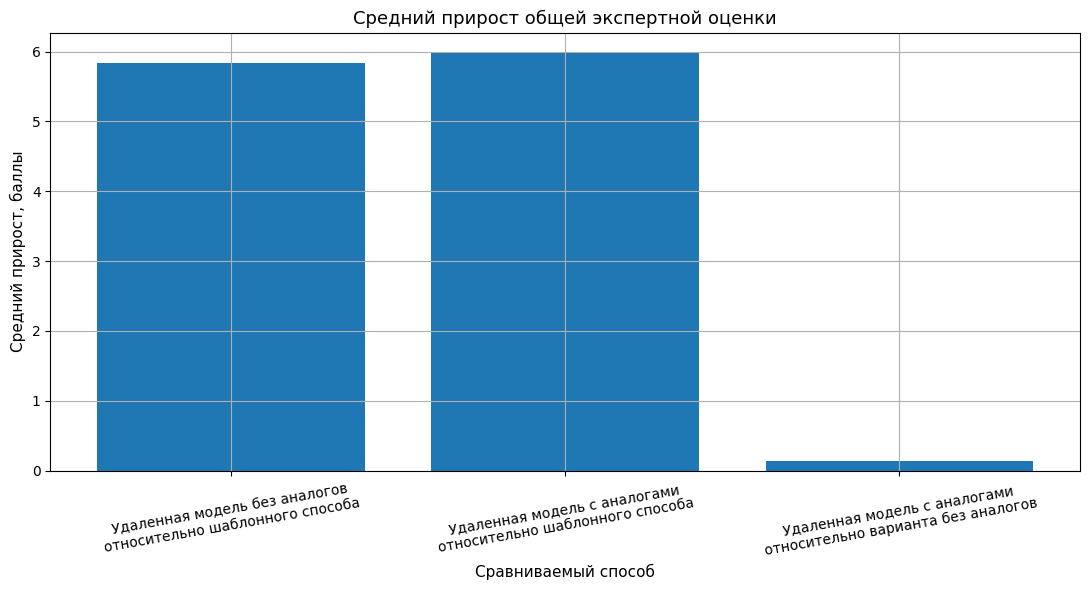

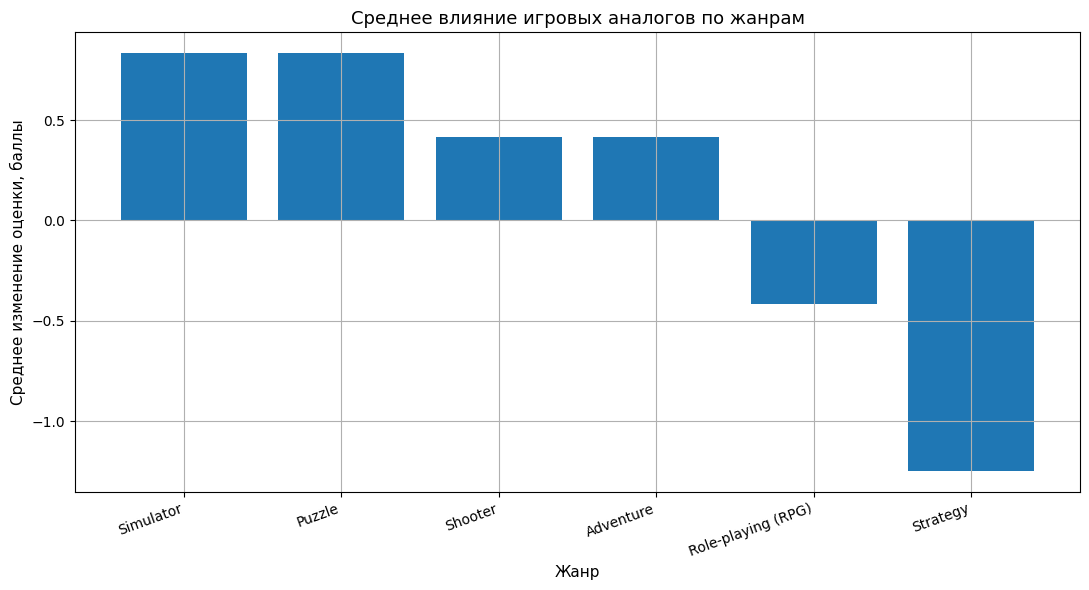

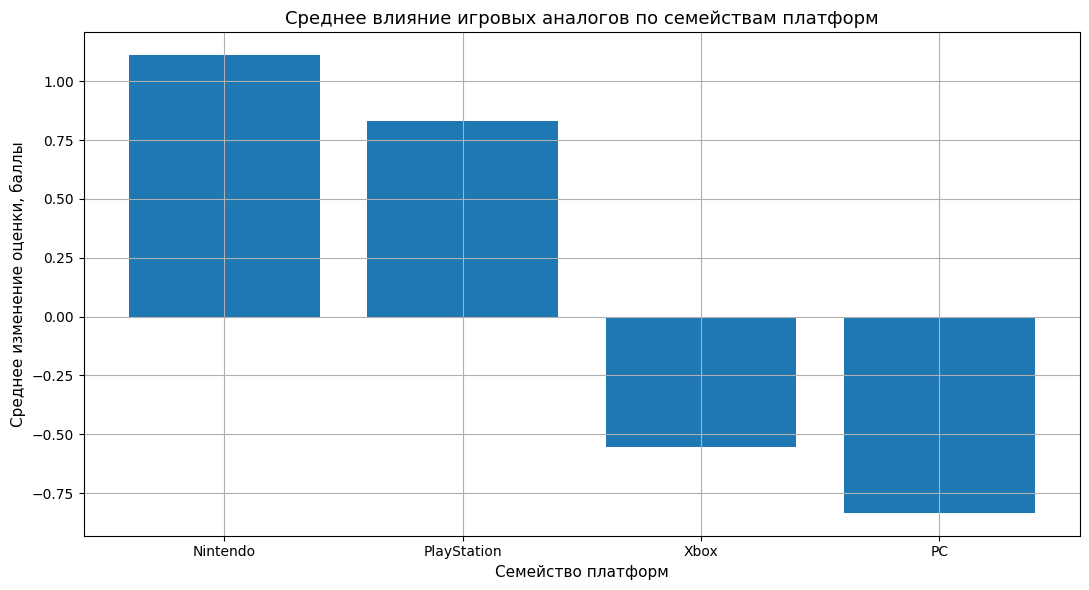

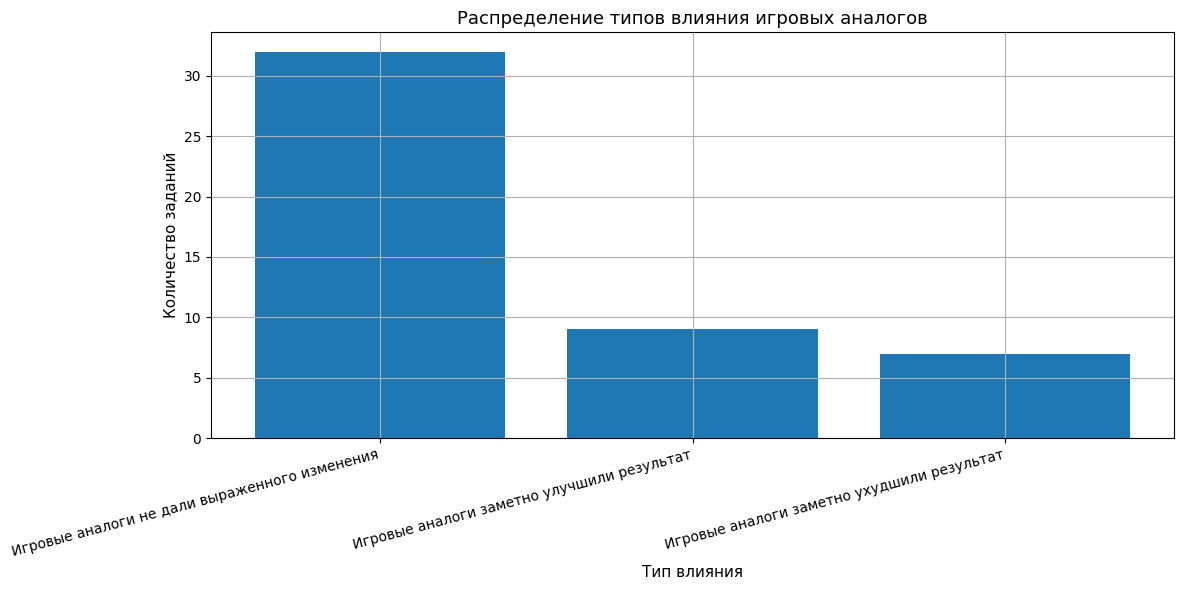

In [101]:
# Строим итоговые рисунки, пригодные для вставки в выпускную работу

import matplotlib.pyplot as plt

# Рисунок 1. Средний выигрыш двух вариантов удаленной модели
mean_gain_summary = pd.DataFrame(
    {
        "Способ подготовки": [
            "Удаленная модель без аналогов\nотносительно шаблонного способа",
            "Удаленная модель с аналогами\nотносительно шаблонного способа",
            "Удаленная модель с аналогами\nотносительно варианта без аналогов"
        ],
        "Средний прирост": [
            comparison_table["delta_model_vs_template"].mean(),
            comparison_table["delta_model_refs_vs_template"].mean(),
            comparison_table["delta_refs_vs_no_refs"].mean()
        ]
    }
)

plt.figure(figsize=(11, 6))
plt.bar(mean_gain_summary["Способ подготовки"], mean_gain_summary["Средний прирост"])
plt.title("Средний прирост общей экспертной оценки")
plt.xlabel("Сравниваемый способ")
plt.ylabel("Средний прирост, баллы")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# Рисунок 2. Среднее влияние игровых аналогов по жанрам
genre_plot = genre_delta_summary.sort_values("mean_delta_refs_vs_no_refs", ascending=False)

plt.figure(figsize=(11, 6))
plt.bar(genre_plot["anchor_genre"], genre_plot["mean_delta_refs_vs_no_refs"])
plt.title("Среднее влияние игровых аналогов по жанрам")
plt.xlabel("Жанр")
plt.ylabel("Среднее изменение оценки, баллы")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Рисунок 3. Среднее влияние игровых аналогов по семействам платформ
platform_plot = platform_delta_summary.sort_values("mean_delta_refs_vs_no_refs", ascending=False)

plt.figure(figsize=(11, 6))
plt.bar(platform_plot["platform_family"], platform_plot["mean_delta_refs_vs_no_refs"])
plt.title("Среднее влияние игровых аналогов по семействам платформ")
plt.xlabel("Семейство платформ")
plt.ylabel("Среднее изменение оценки, баллы")
plt.tight_layout()
plt.show()

# Рисунок 4. Распределение типов влияния игровых аналогов
plt.figure(figsize=(12, 6))
plt.bar(reference_effect_summary["reference_effect_group"], reference_effect_summary["tasks_count"])
plt.title("Распределение типов влияния игровых аналогов")
plt.xlabel("Тип влияния")
plt.ylabel("Количество заданий")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

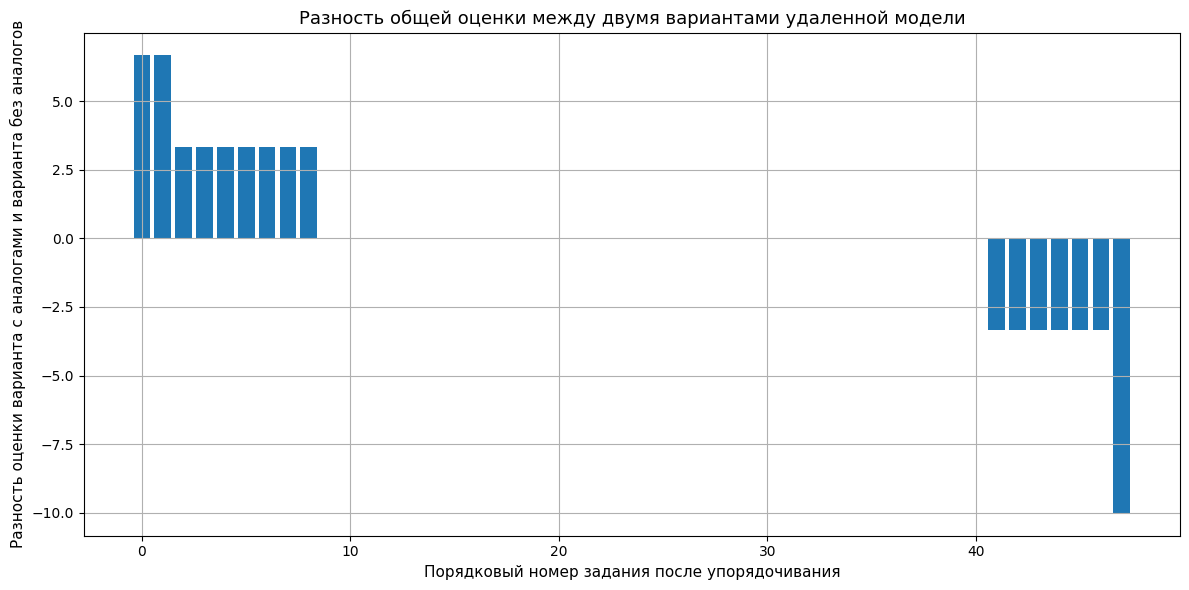

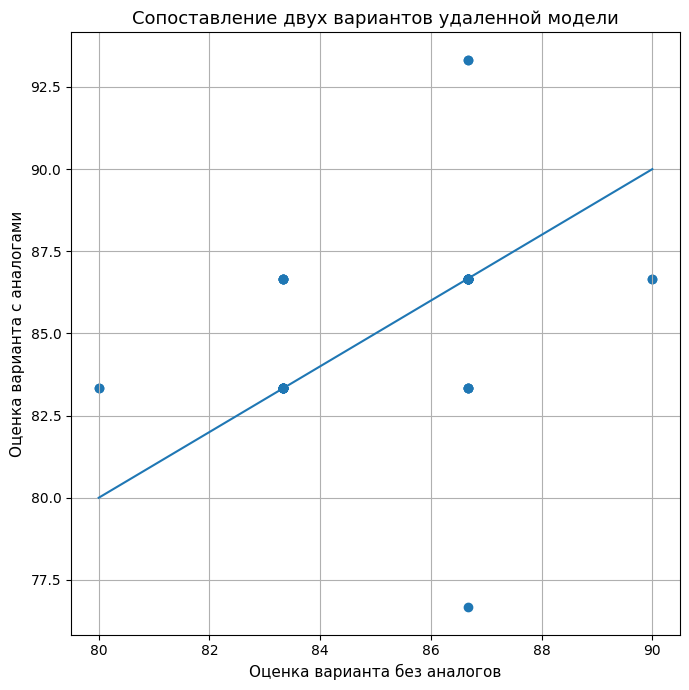

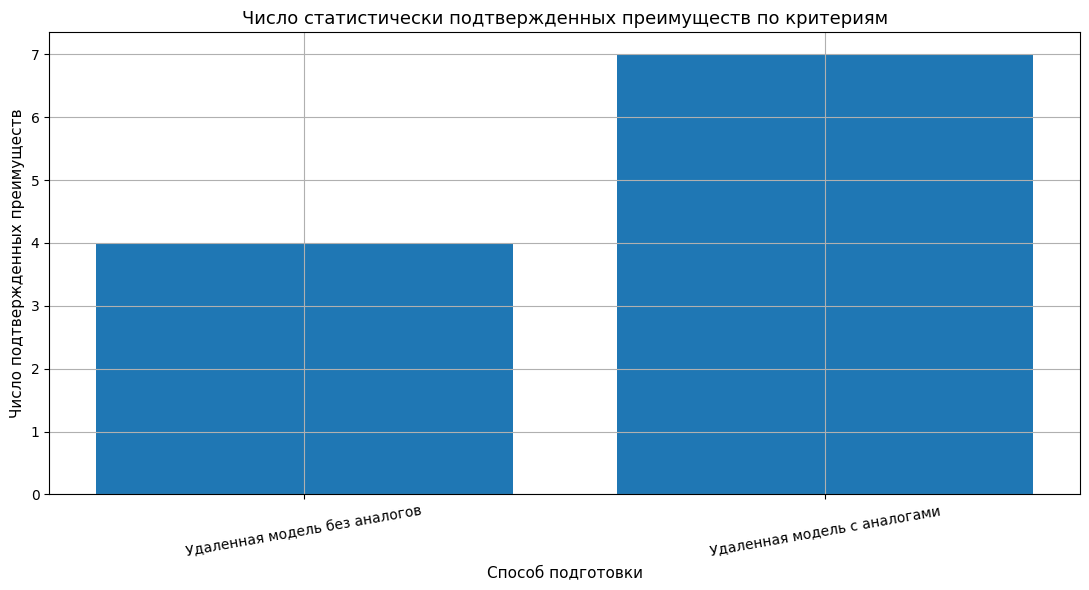

In [102]:
# Строим дополнительные итоговые рисунки по связанной выборке

# Рисунок 5. Упорядоченная разность между двумя вариантами удаленной модели
sorted_delta = comparison_table.sort_values("delta_refs_vs_no_refs", ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.bar(np.arange(len(sorted_delta)), sorted_delta["delta_refs_vs_no_refs"])
plt.title("Разность общей оценки между двумя вариантами удаленной модели")
plt.xlabel("Порядковый номер задания после упорядочивания")
plt.ylabel("Разность оценки варианта с аналогами и варианта без аналогов")
plt.tight_layout()
plt.show()

# Рисунок 6. Диаграмма рассеяния двух вариантов удаленной модели
plt.figure(figsize=(7, 7))
plt.scatter(
    comparison_table["model_without_references"],
    comparison_table["model_with_references"]
)
plt.plot(
    [comparison_table["model_without_references"].min(), comparison_table["model_without_references"].max()],
    [comparison_table["model_without_references"].min(), comparison_table["model_without_references"].max()]
)
plt.title("Сопоставление двух вариантов удаленной модели")
plt.xlabel("Оценка варианта без аналогов")
plt.ylabel("Оценка варианта с аналогами")
plt.tight_layout()
plt.show()

# Рисунок 7. Частота статистически подтвержденных преимуществ по критериям
criteria_advantage_summary = pairwise_criteria_summary.copy()

criteria_advantage_summary["Подтвержденное преимущество"] = (
    criteria_advantage_summary["Скорректированное значение значимости"] < 0.05
).astype(int)

criteria_confirmed_counts = (
    criteria_advantage_summary.groupby("Правый способ", as_index=False)
    .agg(confirmed_advantages=("Подтвержденное преимущество", "sum"))
)

plt.figure(figsize=(11, 6))
plt.bar(criteria_confirmed_counts["Правый способ"], criteria_confirmed_counts["confirmed_advantages"])
plt.title("Число статистически подтвержденных преимуществ по критериям")
plt.xlabel("Способ подготовки")
plt.ylabel("Число подтвержденных преимуществ")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

In [103]:
# Формируем компактную итоговую таблицу выводов для выпускной работы
# и сохраняем все итоговые материалы этапа

final_conclusion_table = pd.DataFrame(
    {
        "Позиция": [
            "Общий результат критерия для трех способов",
            "Удаленная модель без аналогов против шаблонного способа",
            "Удаленная модель с аналогами против шаблонного способа",
            "Удаленная модель с аналогами против варианта без аналогов",
            "Основной итог по гипотезе"
        ],
        "Вывод": [
            (
                "Различия по общей экспертной оценке статистически значимы, "
                "что подтверждает неодинаковое качество трех способов подготовки документа."
            ),
            (
                "Вариант удаленной модели без аналогов статистически значимо превосходит "
                "шаблонный способ по общей экспертной оценке."
            ),
            (
                "Вариант удаленной модели с аналогами статистически значимо превосходит "
                "шаблонный способ по общей экспертной оценке."
            ),
            (
                "Преимущество варианта с аналогами над вариантом без аналогов "
                "по общей экспертной оценке не подтверждено как устойчивое."
            ),
            (
                "Гипотеза о полезности удаленной модели подтверждается уверенно, "
                "а гипотеза о безусловном общем преимуществе игровых аналогов подтверждается частично."
            )
        ]
    }
)

comparison_table.to_csv(
    "results/comparison_table_stage_9.csv",
    index=False
)

reference_effect_summary.to_csv(
    "results/reference_effect_summary_stage_9.csv",
    index=False
)

genre_delta_summary.to_csv(
    "results/genre_delta_summary_stage_9.csv",
    index=False
)

platform_delta_summary.to_csv(
    "results/platform_delta_summary_stage_9.csv",
    index=False
)

best_reference_gain.to_csv(
    "results/best_reference_gain_stage_9.csv",
    index=False
)

worst_reference_gain.to_csv(
    "results/worst_reference_gain_stage_9.csv",
    index=False
)

neutral_reference_gain.to_csv(
    "results/neutral_reference_gain_stage_9.csv",
    index=False
)

final_conclusion_table.to_csv(
    "results/final_conclusion_table_stage_9.csv",
    index=False
)

print("Итоговая таблица сравнений сохранена в файл results/comparison_table_stage_9.csv")
print("Сводка по влиянию игровых аналогов сохранена в файл results/reference_effect_summary_stage_9.csv")
print("Сводка по жанрам сохранена в файл results/genre_delta_summary_stage_9.csv")
print("Сводка по семействам платформ сохранена в файл results/platform_delta_summary_stage_9.csv")
print("Таблица сильнейших улучшений сохранена в файл results/best_reference_gain_stage_9.csv")
print("Таблица наибольших ухудшений сохранена в файл results/worst_reference_gain_stage_9.csv")
print("Таблица нейтральных случаев сохранена в файл results/neutral_reference_gain_stage_9.csv")
print("Итоговая таблица выводов сохранена в файл results/final_conclusion_table_stage_9.csv")

print("\nИтоговая таблица выводов:")
display(final_conclusion_table)

Итоговая таблица сравнений сохранена в файл results/comparison_table_stage_9.csv
Сводка по влиянию игровых аналогов сохранена в файл results/reference_effect_summary_stage_9.csv
Сводка по жанрам сохранена в файл results/genre_delta_summary_stage_9.csv
Сводка по семействам платформ сохранена в файл results/platform_delta_summary_stage_9.csv
Таблица сильнейших улучшений сохранена в файл results/best_reference_gain_stage_9.csv
Таблица наибольших ухудшений сохранена в файл results/worst_reference_gain_stage_9.csv
Таблица нейтральных случаев сохранена в файл results/neutral_reference_gain_stage_9.csv
Итоговая таблица выводов сохранена в файл results/final_conclusion_table_stage_9.csv

Итоговая таблица выводов:


,Позиция,Вывод
0,Общий результат критерия для трех способов,"Различия по общей экспертной оценке статистически значимы, что подтверждает неодинаковое качество трех способов подготовки документа."
1,Удаленная модель без аналогов против шаблонного способа,Вариант удаленной модели без аналогов статистически значимо превосходит шаблонный способ по общей экспертной оценке.
2,Удаленная модель с аналогами против шаблонного способа,Вариант удаленной модели с аналогами статистически значимо превосходит шаблонный способ по общей экспертной оценке.
3,Удаленная модель с аналогами против варианта без аналогов,Преимущество варианта с аналогами над вариантом без аналогов по общей экспертной оценке не подтверждено как устойчивое.
4,Основной итог по гипотезе,"Гипотеза о полезности удаленной модели подтверждается уверенно, а гипотеза о безусловном общем преимуществе игровых аналогов подтверждается частично."


Подтверждено, что оба варианта удаленной модели устойчиво превосходят шаблонный способ, причем разница подтверждена статистически на связанной выборке. Это уже позволяет формулировать основной вывод работы без оговорок: автоматическая подготовка краткого проектного документа с помощью большой языковой модели действительно дает более качественный результат, чем жесткий шаблон.

Не менее важен и второй вывод. Игровые аналоги не дают универсального выигрыша для всех заданий сразу, но в ряде случаев заметно улучшают результат, особенно для отдельных жанров и платформенных семейств. Одновременно видно, что для большей части заданий изменение либо умеренное, либо почти отсутствует, а в отдельных случаях игровые аналоги даже ухудшают итог. Это делает вывод исследования сильнее: вместо слишком общей декларации получается более точное утверждение о частично подтвержденной полезности игровых аналогов.

Небольшая техническая оговорка здесь тоже есть. В таблицу с наибольшими ухудшениями попал один нейтральный случай с нулевой разностью, поскольку выраженно отрицательных примеров оказалось меньше восьми. На общий смысл результатов это не влияет.

# 10. Формирование готовых итоговых материалов для выпускной работы

На заключительном этапе результаты эксперимента переводятся в компактную форму, пригодную для прямого включения в выпускную работу. Основная задача состоит в том, чтобы на основе уже полученных статистических и экспертных данных автоматически сформировать сводные таблицы, краткие содержательные выводы и заготовки подписей к рисункам.

Научная значимость данного этапа состоит в том, что он связывает вычислительный эксперимент с итоговой интерпретацией результатов. Здесь фиксируются окончательные числовые ориентиры, формулируются выводы по гипотезе и подготавливаются материалы, которые затем можно использовать в подразделе с результатами эксперимента, в выводах по главе и в общем заключении работы.

In [104]:
# Загружаем все ключевые таблицы итоговых результатов

import re
import numpy as np
import pandas as pd

mode_quality_summary = pd.read_csv("results/mode_quality_summary_stage_7.csv")
overall_total_summary = pd.read_csv("results/overall_total_summary_stage_8.csv")
pairwise_total_summary = pd.read_csv("results/pairwise_total_summary_stage_8.csv")
friedman_criteria_summary = pd.read_csv("results/friedman_criteria_summary_stage_8.csv")
pairwise_criteria_summary = pd.read_csv("results/pairwise_criteria_summary_stage_8.csv")
comparison_table = pd.read_csv("results/comparison_table_stage_9.csv")
reference_effect_summary = pd.read_csv("results/reference_effect_summary_stage_9.csv")
genre_delta_summary = pd.read_csv("results/genre_delta_summary_stage_9.csv")
platform_delta_summary = pd.read_csv("results/platform_delta_summary_stage_9.csv")
final_conclusion_table = pd.read_csv("results/final_conclusion_table_stage_9.csv")

mode_labels = {
    "template": "Шаблонный способ",
    "model_without_references": "Удаленная модель без аналогов",
    "model_with_references": "Удаленная модель с аналогами"
}

print("Размер основных итоговых таблиц")
print("-" * 70)
print(f"Таблица по способам подготовки: {mode_quality_summary.shape}")
print(f"Итог общей статистической проверки: {overall_total_summary.shape}")
print(f"Попарные сравнения по общей оценке: {pairwise_total_summary.shape}")
print(f"Проверка по отдельным критериям: {friedman_criteria_summary.shape}")
print(f"Попарные сравнения по критериям: {pairwise_criteria_summary.shape}")
print(f"Итоговая таблица сравнений по заданиям: {comparison_table.shape}")
print(f"Сводка по влиянию игровых аналогов: {reference_effect_summary.shape}")
print(f"Сводка по жанрам: {genre_delta_summary.shape}")
print(f"Сводка по платформам: {platform_delta_summary.shape}")

print("\nОсновные выводы предыдущего этапа:")
display(final_conclusion_table)

Размер основных итоговых таблиц
----------------------------------------------------------------------
Таблица по способам подготовки: (3, 15)
Итог общей статистической проверки: (1, 3)
Попарные сравнения по общей оценке: (3, 12)
Проверка по отдельным критериям: (6, 4)
Попарные сравнения по критериям: (18, 10)
Итоговая таблица сравнений по заданиям: (48, 11)
Сводка по влиянию игровых аналогов: (3, 2)
Сводка по жанрам: (6, 5)
Сводка по платформам: (4, 5)

Основные выводы предыдущего этапа:


,Позиция,Вывод
0,Общий результат критерия для трех способов,"Различия по общей экспертной оценке статистически значимы, что подтверждает неодинаковое качество трех способов подготовки документа."
1,Удаленная модель без аналогов против шаблонного способа,Вариант удаленной модели без аналогов статистически значимо превосходит шаблонный способ по общей экспертной оценке.
2,Удаленная модель с аналогами против шаблонного способа,Вариант удаленной модели с аналогами статистически значимо превосходит шаблонный способ по общей экспертной оценке.
3,Удаленная модель с аналогами против варианта без аналогов,Преимущество варианта с аналогами над вариантом без аналогов по общей экспертной оценке не подтверждено как устойчивое.
4,Основной итог по гипотезе,"Гипотеза о полезности удаленной модели подтверждается уверенно, а гипотеза о безусловном общем преимуществе игровых аналогов подтверждается частично."


In [105]:
# Формируем компактные итоговые таблицы для выпускной работы

# Таблица 1. Основные показатели качества по способам подготовки
final_mode_table = mode_quality_summary[
    [
        "mode_label",
        "mean_expert_total_score",
        "mean_task_fit",
        "mean_genre_fit",
        "mean_mechanics_specificity",
        "mean_scope_realism",
        "mean_risk_quality",
        "mean_coherence",
        "mean_text_length_chars"
    ]
].copy()

final_mode_table = final_mode_table.rename(
    columns={
        "mode_label": "Способ подготовки",
        "mean_expert_total_score": "Средняя итоговая экспертная оценка",
        "mean_task_fit": "Соответствие заданию",
        "mean_genre_fit": "Жанровая согласованность",
        "mean_mechanics_specificity": "Конкретность механик",
        "mean_scope_realism": "Реалистичность масштаба",
        "mean_risk_quality": "Качество фиксации рисков",
        "mean_coherence": "Связность документа",
        "mean_text_length_chars": "Средняя длина документа, символов"
    }
)

numeric_columns_mode = [
    column_name for column_name in final_mode_table.columns
    if column_name != "Способ подготовки"
]
final_mode_table[numeric_columns_mode] = final_mode_table[numeric_columns_mode].round(2)

# Таблица 2. Итог статистической проверки
final_stats_table = pairwise_total_summary[
    [
        "Сравнение",
        "Число заданий, где правый способ лучше",
        "Число заданий, где правый способ хуже",
        "Число равных случаев",
        "Доля выигранных заданий, процентов",
        "Среднее превосходство по баллу",
        "Скорректированное значение значимости"
    ]
].copy()

# Таблица 3. Критерии, где различия подтверждены статистически
significant_criteria_table = friedman_criteria_summary.copy()
significant_criteria_table["Различия подтверждены"] = (
    significant_criteria_table["Значение значимости"] < 0.05
).map({True: "Да", False: "Нет"})

# Таблица 4. Итог по влиянию игровых аналогов
reference_effect_table = reference_effect_summary.copy()
reference_effect_table["Доля заданий, процентов"] = (
    reference_effect_table["tasks_count"] / reference_effect_table["tasks_count"].sum() * 100
).round(2)

reference_effect_table = reference_effect_table.rename(
    columns={
        "reference_effect_group": "Тип влияния игровых аналогов",
        "tasks_count": "Число заданий"
    }
)

print("Таблица основных показателей по способам подготовки:")
display(final_mode_table)

print("\nТаблица попарных статистических сравнений:")
display(final_stats_table)

print("\nТаблица по отдельным критериям:")
display(significant_criteria_table)

print("\nТаблица по влиянию игровых аналогов:")
display(reference_effect_table)

Таблица основных показателей по способам подготовки:


,Способ подготовки,Средняя итоговая экспертная оценка,Соответствие заданию,Жанровая согласованность,Конкретность механик,Реалистичность масштаба,Качество фиксации рисков,Связность документа,"Средняя длина документа, символов"
0,Удаленная модель с аналогами,85.35,4.98,4.44,4.00,4.17,3.12,4.90,2848.92
1,Удаленная модель без аналогов,85.21,4.96,4.40,4.00,4.35,3.10,4.75,2695.58
2,Шаблонный способ,79.37,4.04,4.19,3.33,3.94,3.81,4.50,2025.35



Таблица попарных статистических сравнений:


,Сравнение,"Число заданий, где правый способ лучше","Число заданий, где правый способ хуже",Число равных случаев,"Доля выигранных заданий, процентов",Среднее превосходство по баллу,Скорректированное значение значимости
0,"Удаленная модель без аналогов лучше, чем Шаблонный способ",44,3,1,91.67,5.834,0.000000
1,"Удаленная модель с аналогами лучше, чем Шаблонный способ",44,3,1,91.67,5.973,0.000000
2,"Удаленная модель с аналогами лучше, чем Удаленная модель без аналогов",9,7,32,18.75,0.139,0.560787



Таблица по отдельным критериям:


,Критерий,Число связанных наблюдений,Статистика критерия Фридмана,Значение значимости,Различия подтверждены
0,Соответствие заданию,48,82.7634,0.000000,Да
1,Жанровая согласованность,48,9.3973,0.009108,Да
2,Конкретность механик,48,64.0000,0.000000,Да
3,Реалистичность масштаба,48,18.5319,0.000095,Да
4,Качество фиксации рисков,48,57.5897,0.000000,Да
5,Связность документа,48,9.9059,0.007063,Да



Таблица по влиянию игровых аналогов:


,Тип влияния игровых аналогов,Число заданий,"Доля заданий, процентов"
0,Игровые аналоги не дали выраженного изменения,32,66.67
1,Игровые аналоги заметно улучшили результат,9,18.75
2,Игровые аналоги заметно ухудшили результат,7,14.58


In [106]:
# Формируем готовые краткие выводы для включения в текст работы

def get_pair_row(table, right_label, left_label):
    row = table[
        (table["Правый способ"] == right_label) &
        (table["Левый способ"] == left_label)
    ].copy()

    if len(row) == 0:
        return None

    return row.iloc[0]

template_label = "Шаблонный способ"
no_refs_label = "Удаленная модель без аналогов"
with_refs_label = "Удаленная модель с аналогами"

row_no_refs_vs_template = get_pair_row(pairwise_total_summary, no_refs_label, template_label)
row_with_refs_vs_template = get_pair_row(pairwise_total_summary, with_refs_label, template_label)
row_with_refs_vs_no_refs = get_pair_row(pairwise_total_summary, with_refs_label, no_refs_label)

overall_friedman_p = float(overall_total_summary.loc[0, "Значение значимости"])
overall_friedman_stat = float(overall_total_summary.loc[0, "Статистика критерия Фридмана"])

best_genre_row = genre_delta_summary.sort_values("mean_delta_refs_vs_no_refs", ascending=False).iloc[0]
worst_genre_row = genre_delta_summary.sort_values("mean_delta_refs_vs_no_refs", ascending=True).iloc[0]

best_platform_row = platform_delta_summary.sort_values("mean_delta_refs_vs_no_refs", ascending=False).iloc[0]
worst_platform_row = platform_delta_summary.sort_values("mean_delta_refs_vs_no_refs", ascending=True).iloc[0]

no_change_row = reference_effect_table.loc[
    reference_effect_table["Тип влияния игровых аналогов"] == "Игровые аналоги не дали выраженного изменения"
].iloc[0]

improve_row = reference_effect_table.loc[
    reference_effect_table["Тип влияния игровых аналогов"] == "Игровые аналоги заметно улучшили результат"
].iloc[0]

worsen_row = reference_effect_table.loc[
    reference_effect_table["Тип влияния игровых аналогов"] == "Игровые аналоги заметно ухудшили результат"
].iloc[0]

ready_conclusions = pd.DataFrame(
    {
        "Номер": [1, 2, 3, 4, 5, 6],
        "Готовый вывод": [
            (
                f"Общая проверка трех связанных способов подготовки документа показала статистически "
                f"значимые различия: значение критерия Фридмана составило {overall_friedman_stat:.3f}, "
                f"а значение значимости оказалось меньше 0,05."
            ),
            (
                f"Вариант удаленной модели без игровых аналогов статистически значимо превзошел "
                f"шаблонный способ: он оказался лучше в {int(row_no_refs_vs_template['Число заданий, где правый способ лучше'])} "
                f"из 48 заданий, а средний выигрыш составил {float(row_no_refs_vs_template['Среднее превосходство по баллу']):.3f} балла."
            ),
            (
                f"Вариант удаленной модели с игровыми аналогами также статистически значимо превзошел "
                f"шаблонный способ: он оказался лучше в {int(row_with_refs_vs_template['Число заданий, где правый способ лучше'])} "
                f"из 48 заданий, а средний выигрыш составил {float(row_with_refs_vs_template['Среднее превосходство по баллу']):.3f} балла."
            ),
            (
                f"Преимущество варианта с игровыми аналогами над вариантом без аналогов "
                f"не подтвердилось как устойчивое: средняя разность составила "
                f"{float(row_with_refs_vs_no_refs['Среднее превосходство по баллу']):.3f} балла, "
                f"а скорректированное значение значимости оказалось выше 0,05."
            ),
            (
                f"Наибольший средний положительный эффект игровые аналоги показали для жанра "
                f"{best_genre_row['anchor_genre']} и для семейства платформ {best_platform_row['platform_family']}, "
                f"тогда как наибольшее среднее ухудшение наблюдалось для жанра "
                f"{worst_genre_row['anchor_genre']} и для семейства платформ {worst_platform_row['platform_family']}."
            ),
            (
                f"Для {int(no_change_row['Число заданий'])} заданий из 48 игровые аналоги не дали выраженного изменения, "
                f"для {int(improve_row['Число заданий'])} заданий они заметно улучшили результат, "
                f"а для {int(worsen_row['Число заданий'])} заданий заметно ухудшили его."
            )
        ]
    }
)

print("Готовые выводы для включения в работу:")
display(ready_conclusions)

Готовые выводы для включения в работу:


,Номер,Готовый вывод
0,1,"Общая проверка трех связанных способов подготовки документа показала статистически значимые различия: значение критерия Фридмана составило 64.293, а значение значимости оказалось меньше 0,05."
1,2,"Вариант удаленной модели без игровых аналогов статистически значимо превзошел шаблонный способ: он оказался лучше в 44 из 48 заданий, а средний выигрыш составил 5.834 балла."
2,3,"Вариант удаленной модели с игровыми аналогами также статистически значимо превзошел шаблонный способ: он оказался лучше в 44 из 48 заданий, а средний выигрыш составил 5.973 балла."
3,4,"Преимущество варианта с игровыми аналогами над вариантом без аналогов не подтвердилось как устойчивое: средняя разность составила 0.139 балла, а скорректированное значение значимости оказалось выш..."
4,5,"Наибольший средний положительный эффект игровые аналоги показали для жанра Simulator и для семейства платформ Nintendo, тогда как наибольшее среднее ухудшение наблюдалось для жанра Strategy и для ..."
5,6,"Для 32 заданий из 48 игровые аналоги не дали выраженного изменения, для 9 заданий они заметно улучшили результат, а для 7 заданий заметно ухудшили его."


In [107]:
# Формируем заготовки подписей к итоговым рисункам

figure_captions = pd.DataFrame(
    {
        "Номер рисунка": [
            "Рисунок А",
            "Рисунок Б",
            "Рисунок В",
            "Рисунок Г",
            "Рисунок Д",
            "Рисунок Е",
            "Рисунок Ж"
        ],
        "Подпись": [
            "Средний прирост общей экспертной оценки для двух вариантов удаленной модели относительно шаблонного способа и относительно друг друга",
            "Среднее влияние игровых аналогов на итоговую экспертную оценку в разрезе жанров",
            "Среднее влияние игровых аналогов на итоговую экспертную оценку в разрезе семейств платформ",
            "Распределение типов влияния игровых аналогов на итоговый результат",
            "Упорядоченная разность общей экспертной оценки между вариантом с аналогами и вариантом без аналогов",
            "Сопоставление итоговых оценок двух вариантов удаленной модели по всем тестовым заданиям",
            "Число статистически подтвержденных преимуществ по отдельным критериям оценки"
        ]
    }
)

print("Заготовки подписей к рисункам:")
display(figure_captions)

Заготовки подписей к рисункам:


,Номер рисунка,Подпись
0,Рисунок А,Средний прирост общей экспертной оценки для двух вариантов удаленной модели относительно шаблонного способа и относительно друг друга
1,Рисунок Б,Среднее влияние игровых аналогов на итоговую экспертную оценку в разрезе жанров
2,Рисунок В,Среднее влияние игровых аналогов на итоговую экспертную оценку в разрезе семейств платформ
3,Рисунок Г,Распределение типов влияния игровых аналогов на итоговый результат
4,Рисунок Д,Упорядоченная разность общей экспертной оценки между вариантом с аналогами и вариантом без аналогов
5,Рисунок Е,Сопоставление итоговых оценок двух вариантов удаленной модели по всем тестовым заданиям
6,Рисунок Ж,Число статистически подтвержденных преимуществ по отдельным критериям оценки


In [108]:
# Сохраняем все итоговые материалы этапа

final_mode_table.to_csv(
    "results/final_mode_table_stage_10.csv",
    index=False
)

final_stats_table.to_csv(
    "results/final_stats_table_stage_10.csv",
    index=False
)

significant_criteria_table.to_csv(
    "results/significant_criteria_table_stage_10.csv",
    index=False
)

reference_effect_table.to_csv(
    "results/reference_effect_table_stage_10.csv",
    index=False
)

ready_conclusions.to_csv(
    "results/ready_conclusions_stage_10.csv",
    index=False
)

figure_captions.to_csv(
    "results/figure_captions_stage_10.csv",
    index=False
)

print("Итоговая таблица показателей сохранена в файл results/final_mode_table_stage_10.csv")
print("Итоговая таблица статистических сравнений сохранена в файл results/final_stats_table_stage_10.csv")
print("Таблица по отдельным критериям сохранена в файл results/significant_criteria_table_stage_10.csv")
print("Таблица по влиянию игровых аналогов сохранена в файл results/reference_effect_table_stage_10.csv")
print("Готовые выводы сохранены в файл results/ready_conclusions_stage_10.csv")
print("Подписи к рисункам сохранены в файл results/figure_captions_stage_10.csv")

Итоговая таблица показателей сохранена в файл results/final_mode_table_stage_10.csv
Итоговая таблица статистических сравнений сохранена в файл results/final_stats_table_stage_10.csv
Таблица по отдельным критериям сохранена в файл results/significant_criteria_table_stage_10.csv
Таблица по влиянию игровых аналогов сохранена в файл results/reference_effect_table_stage_10.csv
Готовые выводы сохранены в файл results/ready_conclusions_stage_10.csv
Подписи к рисункам сохранены в файл results/figure_captions_stage_10.csv


In [109]:
# Скачивание основных и аналитических файлов эксперимента одним архивом на ПК

import os
import zipfile
from google.colab import files

files_to_download = [
    "results/test_briefs_stage_4.csv",
    "results/study_corpus_stage_4.csv.gz",
    "results/references_unique_stage_6.csv",
    "results/generated_documents_stage_6.csv",
    "results/document_metrics_stage_7.csv",
    "results/comparison_table_stage_9.csv",
    "results/final_mode_table_stage_10.csv"
]

archive_name = "game_design_app_files.zip"

existing_files = []
missing_files = []

for file_path in files_to_download:
    if os.path.exists(file_path):
        existing_files.append(file_path)
    else:
        missing_files.append(file_path)

print("Найденные файлы:")
for file_path in existing_files:
    print("  ", file_path)

if missing_files:
    print("\nОтсутствующие файлы:")
    for file_path in missing_files:
        print("  ", file_path)

with zipfile.ZipFile(archive_name, "w", zipfile.ZIP_DEFLATED) as archive:
    for file_path in existing_files:
        archive.write(file_path, arcname=os.path.basename(file_path))

print(f"\nАрхив создан: {archive_name}")

files.download(archive_name)

Найденные файлы:
   results/test_briefs_stage_4.csv
   results/study_corpus_stage_4.csv.gz
   results/references_unique_stage_6.csv
   results/generated_documents_stage_6.csv
   results/document_metrics_stage_7.csv
   results/comparison_table_stage_9.csv
   results/final_mode_table_stage_10.csv

Архив создан: game_design_app_files.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>